In [1]:
# PROYECTO: La violencia hacia la mujer en datos - México
# Configuración del entorno de análisis: 

# Procesamiento de datos y sistema
import pandas as pd
import numpy as np
import wbgapi as wb 
import os
import requests
import warnings 
warnings.filterwarnings('ignore')

# visualización interactiva (Plotly)
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import ipywidgets as widgets
from IPython.display import display, clear_output
import folium
from folium.plugins import HeatMap

# análisis estadístico y gráfico tradicional
import matplotlib.pyplot as plt
import seaborn as sns

# configuración para Streamlit (Solo para exportación posterior)
import streamlit as st 

# configuración estética 
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6) # Un poco más ancho para series de tiempo
sns.set_theme(style="whitegrid")

# colores: Azul Principal, Verde, Azul Marino, Rosa Impacto
paleta_colores = ["#0072BC", "#7DBE31", "#002D56", "#E61B61"]
sns.set_palette(paleta_colores)

# estilo de fuentes y fondos
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'text.color': '#002D56',
    'axes.labelcolor': '#002D56',
    'xtick.color': '#002D56',
    'ytick.color': '#002D56',
    'axes.titlecolor': '#002D56',
    'axes.spines.top': False, 
    'axes.spines.right': False
})

print("Entorno configurado con identidad visual.")
print("Librerías de análisis y visualización listas.")

Entorno configurado con identidad visual.
Librerías de análisis y visualización listas.


In [2]:
# definición de la ruta base
path_datasets = r"C:\Users\Elechiguerra\Desktop\ONU_Mujeres_BID\La_violencia_hacia_la_mujer_en_datos\Datasets_usados"

print(f"iniciando análisis de archivos en: {path_datasets}\n")

inventario_datos = {}

# extensiones permitidas
extensiones_validas = ('.csv', '.xlsx', '.xls', '.sav')

for raiz, directorios, archivos in os.walk(path_datasets):
    nivel = raiz.replace(path_datasets, '').count(os.sep)
    sangria = '    ' * nivel
    nombre_carpeta = os.path.basename(raiz)
    
    if nombre_carpeta:
        print(f"{sangria}directorio: {nombre_carpeta}")
    
    sangria_archivo = '    ' * (nivel + 1)
    for nombre_archivo in archivos:
        if nombre_archivo.lower().endswith(extensiones_validas) and not nombre_archivo.startswith('~$'):
            print(f"{sangria_archivo}archivo: {nombre_archivo}")
            
            clave_unica = os.path.join(nombre_carpeta, nombre_archivo)
            inventario_datos[clave_unica] = os.path.join(raiz, nombre_archivo)

print(f"\nse han identificado {len(inventario_datos)} fuentes de datos únicas.")

iniciando análisis de archivos en: C:\Users\Elechiguerra\Desktop\ONU_Mujeres_BID\La_violencia_hacia_la_mujer_en_datos\Datasets_usados

directorio: Datasets_usados
    directorio: EDR
        archivo: conjunto_de_datos_defunciones_registradas24_csv.csv
        archivo: conjunto_de_datos_defunciones_registradas_2021.csv
        archivo: conjunto_de_datos_defunciones_registradas_2022.CSV
        archivo: conjunto_de_datos_defunciones_registradas_2023_csv.CSV
    directorio: ENDIREH_2021
        archivo: TB_SEC_III.csv
        archivo: TB_SEC_IV.csv
        archivo: TB_SEC_VIII.csv
        archivo: TB_SEC_XIII.csv
        archivo: TSDem.csv
        archivo: TVIV.csv
    directorio: SESNSP
        archivo: Estatal-Delitos-2015-2025_feb2026.csv
        archivo: Estatal-Víctimas-2015-2025_feb2026.csv
        archivo: TablaDinámica-Municipal Delitos - DICIEMBRE 2025-corteFebrero2026(CuboMunicipal).csv

se han identificado 13 fuentes de datos únicas.


In [3]:
# lista de archivos específicos según el inventario generado
archivos_edr = [
    'conjunto_de_datos_defunciones_registradas_2021.csv',
    'conjunto_de_datos_defunciones_registradas_2022.CSV',
    'conjunto_de_datos_defunciones_registradas_2023_csv.CSV',
    'conjunto_de_datos_defunciones_registradas24_csv.csv'
]

lista_dfs_edr = []

print("iniciando consolidación de registros de defunciones...")

for archivo in archivos_edr:
    ruta_completa = next((ruta for clave, ruta in inventario_datos.items() if archivo in clave), None)
    
    if ruta_completa:
        df_temp = pd.read_csv(ruta_completa, low_memory=False)
        df_temp.columns = df_temp.columns.str.upper()
        
        # asignación del año mediante búsqueda de patrones numéricos
        import re
        coincidencia_anio = re.search(r'20\d{2}|24', archivo)
        anio_detectado = int(coincidencia_anio.group()) if coincidencia_anio else 2024
        
        # corrección para el caso específico del archivo '24'
        if anio_detectado == 24: anio_detectado = 2024
            
        df_temp['ANIO_REGISTRO'] = anio_detectado
        
        lista_dfs_edr.append(df_temp)
        print(f"archivo {archivo} procesado: {df_temp.shape[0]} registros.")
    else:
        print(f"advertencia: el archivo {archivo} no se encontró en el inventario.")

# concatenación final
if lista_dfs_edr:
    df_edr_historico = pd.concat(lista_dfs_edr, ignore_index=True)
    print(f"\nconsolidación finalizada. total de registros históricos: {df_edr_historico.shape[0]}")
else:
    print("\nerror: no se cargaron registros para la consolidación.")

iniciando consolidación de registros de defunciones...
archivo conjunto_de_datos_defunciones_registradas_2021.csv procesado: 1122249 registros.
archivo conjunto_de_datos_defunciones_registradas_2022.CSV procesado: 847716 registros.
archivo conjunto_de_datos_defunciones_registradas_2023_csv.CSV procesado: 799869 registros.
archivo conjunto_de_datos_defunciones_registradas24_csv.csv procesado: 819672 registros.

consolidación finalizada. total de registros históricos: 3589506


In [4]:
# diagnóstico columnas EDR histórico
columnas_actuales = df_edr_historico.columns.tolist()

# búsqueda de variables clave con métricas de integridad
def diagnosticar_variables(patron, nombre_logico):
    coincidencias = [col for col in columnas_actuales if patron in col]
    print(f"\nanálisis de variable: {nombre_logico}")
    print("-" * 50)
    for col in coincidencias:
        nulos = df_edr_historico[col].isnull().sum()
        total = len(df_edr_historico)
        completitud = ((total - nulos) / total) * 100
        print(f"columna: {col: <15} | completitud: {completitud:.2f}% | valores únicos: {df_edr_historico[col].nunique()}")

# ejecutar diagnóstico para presunción de homicidio y sexo
diagnosticar_variables('PRES', 'presunción de hecho violento')
diagnosticar_variables('SEXO', 'sexo de la víctima')
diagnosticar_variables('CAUSA', 'causa de defunción (cie-10)')

# visualización de muestra para validación de formatos
print("\nmuestra de datos en columnas sospechosas:")
cols_interes = [col for col in columnas_actuales if any(p in col for p in ['PRES', 'SEXO', 'CAUSA'])]
print(df_edr_historico[cols_interes].head(10))


análisis de variable: presunción de hecho violento
--------------------------------------------------
columna: PRESUNTO        | completitud: 31.26% | valores únicos: 6

análisis de variable: sexo de la víctima
--------------------------------------------------
columna: SEXO            | completitud: 100.00% | valores únicos: 3

análisis de variable: causa de defunción (cie-10)
--------------------------------------------------
columna: CAUSA_DEF       | completitud: 100.00% | valores únicos: 5405

muestra de datos en columnas sospechosas:
  CAUSA_DEF  SEXO  PRESUNTO
0      F03X     1       8.0
1      I678     2       8.0
2      R688     1       8.0
3      N189     2       8.0
4      C349     2       8.0
5      K318     2       8.0
6      G934     1       8.0
7      J449     2       8.0
8      I219     2       8.0
9      I259     1       8.0


In [5]:
# normalización y filtrado de alta precisión para violencia letal femenina

# estandarización de columnas críticas
cols_para_limpieza = ['SEXO', 'PRESUNTO', 'ANIO_REGISTRO']
for col in cols_para_limpieza:
    if col in df_edr_historico.columns:
        df_edr_historico[col] = pd.to_numeric(df_edr_historico[col], errors='coerce')

# definición de criterios de búsqueda (presunto homicidio o códigos cie-10)
# códigos cie-10 para agresiones: x85 a y09
patron_homicidio_cie10 = r'^(X8[5-9]|X9[0-9]|Y0[0-9])'

# aplicación del filtro dual (por variable presunto o por causa médica)
df_homicidios_femeninos = df_edr_historico[
    (df_edr_historico['SEXO'] == 2) & (
        (df_edr_historico['PRESUNTO'] == 1) | 
        (df_edr_historico['CAUSA_DEF'].astype(str).str.contains(patron_homicidio_cie10, na=False))
    )
].copy()

# validación de resultados y serie temporal
resumen_anual = df_homicidios_femeninos.groupby('ANIO_REGISTRO').size()

print("resultado del filtrado estratégico (serie 2021-2024):")
print("-" * 60)
if resumen_anual.empty:
    print("advertencia: no se detectaron registros. revise la integridad de 'SEXO' y 'CAUSA_DEF'.")
else:
    # se muestra la serie completa para detectar vacíos en años recientes
    print(resumen_anual)

print("-" * 60)
print(f"total de registros recuperados: {len(df_homicidios_femeninos)}")

# verificación de registros por año para detectar posibles sesgos de carga
for anio in [2021, 2022, 2023, 2024]:
    if anio not in resumen_anual.index:
        print(f"alerta: el año {anio} no presenta datos tras el filtrado.")

resultado del filtrado estratégico (serie 2021-2024):
------------------------------------------------------------
ANIO_REGISTRO
2021    11791
2022     3928
2023     3739
2024     3739
dtype: int64
------------------------------------------------------------
total de registros recuperados: 23197


In [6]:
# normalización definitiva de la serie histórica 2021-2024

# diagnóstico preventivo utilizando nombres estandarizados
print("diagnóstico de tipos y valores en 'PRESUNTO':")

# se asegura el uso de mayúsculas para coincidir con la estandarización previa
col_anio = 'ANIO_REGISTRO'
col_presunto = 'PRESUNTO'
col_sexo = 'SEXO'
col_causa = 'CAUSA_DEF'

for anio in sorted(df_edr_historico[col_anio].unique()):
    condicion_anio = df_edr_historico[col_anio] == anio
    valores = df_edr_historico[condicion_anio][col_presunto].unique()
    print(f"año {anio}: {valores}")

# recuperación exhaustiva (presunto + causas médicas cie-10)
# patrón para agresiones/homicidios: x85 a y09
patron_homicidio = r'^(X8[5-9]|X9[0-9]|Y0[0-9])'

df_homicidios_femeninos = df_edr_historico[
    (df_edr_historico[col_sexo] == 2) & (
        (df_edr_historico[col_presunto].isin([1, 1.0, "1", "1.0"])) |
        (df_edr_historico[col_causa].astype(str).str.contains(patron_homicidio, na=False))
    )
].copy()

# resumen y validación de continuidad
resumen_final = df_homicidios_femeninos.groupby(col_anio).size()

print("\n--- serie histórica consolidada (homicidios femeninos) ---")
print("-" * 55)
if not resumen_final.empty:
    print(resumen_final)
else:
    print("alerta: la serie histórica está vacía tras aplicar los filtros en mayúsculas.")

print("-" * 55)
print(f"total acumulado 2021-2024: {len(df_homicidios_femeninos)}")

diagnóstico de tipos y valores en 'PRESUNTO':
año 2021: [8. 1. 2. 3. 4. 5.]
año 2022: [nan]
año 2023: [nan]
año 2024: [nan]

--- serie histórica consolidada (homicidios femeninos) ---
-------------------------------------------------------
ANIO_REGISTRO
2021    11791
2022     3928
2023     3739
2024     3739
dtype: int64
-------------------------------------------------------
total acumulado 2021-2024: 23197


In [7]:
# validación de contenido en columnas candidatas
for anio in [2022, 2023, 2024]:
    print(f"\n--- análisis de integridad para el año {anio} ---")
    df_anio = df_edr_historico[df_edr_historico['ANIO_REGISTRO'] == anio]
    
    for col in ['PRESUNTO', 'CAUSA_DEF']:
        if col in df_anio.columns:
            nulos = df_anio[col].isnull().sum()
            total = len(df_anio)
            print(f"columna: {col: <12} | nulos: {nulos} de {total} | primeros valores: {df_anio[col].dropna().unique()[:5]}")


--- análisis de integridad para el año 2022 ---
columna: PRESUNTO     | nulos: 847716 de 847716 | primeros valores: []
columna: CAUSA_DEF    | nulos: 0 de 847716 | primeros valores: ['K254' 'J439' 'E112' 'I269' 'W104']

--- análisis de integridad para el año 2023 ---
columna: PRESUNTO     | nulos: 799869 de 799869 | primeros valores: []
columna: CAUSA_DEF    | nulos: 0 de 799869 | primeros valores: ['J189' 'J80X' 'J440' 'E441' 'K703']

--- análisis de integridad para el año 2024 ---
columna: PRESUNTO     | nulos: 819672 de 819672 | primeros valores: []
columna: CAUSA_DEF    | nulos: 0 de 819672 | primeros valores: ['I864' 'N179' 'C229' 'K746' 'I219']


In [8]:
# estandarización de tipos para evitar discrepancias
df_edr_historico['PRESUNTO'] = pd.to_numeric(df_edr_historico['PRESUNTO'], errors='coerce')

# definición de criterios técnicos
# códigos cie-10: agresiones (x85 a y09)
codigos_homicidio = [f'X{i}' for i in range(85, 100)] + [f'Y0{i}' for i in range(0, 10)]

# aplicación del filtro de rescate
# se evalúa sexo femenino (2) y (presunto homicidio o causa médica de agresión)
df_homicidios_femeninos = df_edr_historico[
    (df_edr_historico['SEXO'] == 2) & (
        (df_edr_historico['PRESUNTO'] == 1) | 
        (df_edr_historico['CAUSA_DEF'].astype(str).str.startswith(tuple(codigos_homicidio)))
    )
].copy()

# reporte de integridad de la serie histórica
print("--- serie histórica reparada (homicidios femeninos) ---")
print("-" * 55)
resumen_historico = df_homicidios_femeninos.groupby('ANIO_REGISTRO').size()
print(resumen_historico)
print("-" * 55)
print(f"total de registros consolidados: {len(df_homicidios_femeninos)}")

--- serie histórica reparada (homicidios femeninos) ---
-------------------------------------------------------
ANIO_REGISTRO
2021    11791
2022     3928
2023     3739
2024     3739
dtype: int64
-------------------------------------------------------
total de registros consolidados: 23197


In [9]:
# análisis de consistencia y densidad de datos por año
columnas_alternativas = ['TIPO_DEFUN', 'NATVIOLE', 'PRESUNTO', 'CAUSA_DEF']

print("auditoría de variables de violencia (2022-2024):")
print("-" * 60)

for anio in [2022, 2023, 2024]:
    print(f"\n[ año {anio} ]")
    df_anio = df_edr_historico[df_edr_historico['ANIO_REGISTRO'] == anio]
    
    for col in columnas_alternativas:
        if col in df_anio.columns:
            # calculamos el porcentaje de registros con datos (no nulos)
            completitud = (df_anio[col].notnull().sum() / len(df_anio)) * 100
            valores = df_anio[col].dropna().unique()
            
            print(f"variable: {col: <12} | completitud: {completitud:>6.2f}% | valores: {valores[:5]}")

auditoría de variables de violencia (2022-2024):
------------------------------------------------------------

[ año 2022 ]
variable: TIPO_DEFUN   | completitud: 100.00% | valores: [4. 1. 2. 3. 9.]
variable: NATVIOLE     | completitud: 100.00% | valores: [8. 2. 1.]
variable: PRESUNTO     | completitud:   0.00% | valores: []
variable: CAUSA_DEF    | completitud: 100.00% | valores: ['K254' 'J439' 'E112' 'I269' 'W104']

[ año 2023 ]
variable: TIPO_DEFUN   | completitud: 100.00% | valores: [4. 1. 3. 2. 9.]
variable: NATVIOLE     | completitud: 100.00% | valores: [2. 1. 8.]
variable: PRESUNTO     | completitud:   0.00% | valores: []
variable: CAUSA_DEF    | completitud: 100.00% | valores: ['J189' 'J80X' 'J440' 'E441' 'K703']

[ año 2024 ]
variable: TIPO_DEFUN   | completitud: 100.00% | valores: [4. 1. 3. 2. 9.]
variable: NATVIOLE     | completitud: 100.00% | valores: [2. 1. 8.]
variable: PRESUNTO     | completitud:   0.00% | valores: []
variable: CAUSA_DEF    | completitud: 100.00% | valore

In [10]:
# consolidación integral

# estandarización de tipos
cols_criticas = ['PRESUNTO', 'TIPO_DEFUN', 'NATVIOLE', 'SEXO', 'ANIO_REGISTRO']
for col in cols_criticas:
    if col in df_edr_historico.columns:
        df_edr_historico[col] = pd.to_numeric(df_edr_historico[col], errors='coerce')

# lógica de rescate por periodo y causa médica (cie-10)
# se añaden códigos cie-10 como red de seguridad adicional
patron_cie10 = r'^(X8[5-9]|X9[0-9]|Y0[0-9])'
mask_cie10 = df_edr_historico['CAUSA_DEF'].astype(str).str.contains(patron_cie10, na=False)

mask_2021 = (df_edr_historico['ANIO_REGISTRO'] == 2021) & (df_edr_historico['PRESUNTO'] == 1)
mask_reciente = (df_edr_historico['ANIO_REGISTRO'] >= 2022) & \
                ((df_edr_historico['TIPO_DEFUN'] == 1) | (df_edr_historico['NATVIOLE'] == 1))

# filtrado final universo femenino (sexo == 2)
df_homicidios_femeninos = df_edr_historico[
    (df_edr_historico['SEXO'] == 2) & (mask_2021 | mask_reciente | mask_cie10)
].copy()

# reporte de consistencia
resumen_final = df_homicidios_femeninos.groupby('ANIO_REGISTRO').size()
print("serie histórica 2021-2024 consolidada:")
print("-" * 55)
if not resumen_final.empty:
    print(resumen_final)
    print("-" * 55)
    print(f"total de registros de violencia letal femenina: {len(df_homicidios_femeninos)}")
else:
    print("advertencia: no se recuperaron registros. verifique la integridad de las máscaras.")

serie histórica 2021-2024 consolidada:
-------------------------------------------------------
ANIO_REGISTRO
2021    11791
2022    13878
2023    14945
2024    14631
dtype: int64
-------------------------------------------------------
total de registros de violencia letal femenina: 55245


In [11]:
# consolidación integral

# estandarización de tipos para variables críticas
cols_criticas = ['PRESUNTO', 'TIPO_DEFUN', 'NATVIOLE', 'SEXO', 'ANIO_REGISTRO']
for col in cols_criticas:
    if col in df_edr_historico.columns:
        df_edr_historico[col] = pd.to_numeric(df_edr_historico[col], errors='coerce')

# definición de máscaras lógicas
# códigos cie-10 de agresiones (x85 a y09) como respaldo médico
patron_cie10 = r'^(X8[5-9]|X9[0-9]|Y0[0-9])'
mask_cie10 = df_edr_historico['CAUSA_DEF'].astype(str).str.contains(patron_cie10, na=False)

# filtros por periodo institucional
mask_2021 = (df_edr_historico['ANIO_REGISTRO'] == 2021) & (df_edr_historico['PRESUNTO'] == 1)
mask_reciente = (df_edr_historico['ANIO_REGISTRO'] >= 2022) & \
                ((df_edr_historico['TIPO_DEFUN'] == 1) | (df_edr_historico['NATVIOLE'] == 1))

# construcción del universo definitivo de estudio (sexo == 2)
df_homicidios_femeninos = df_edr_historico[
    (df_edr_historico['SEXO'] == 2) & (mask_2021 | mask_reciente | mask_cie10)
].copy()

# reporte de integridad
resumen_final = df_homicidios_femeninos.groupby('ANIO_REGISTRO').size()
print("serie histórica 2021-2024 consolidada:")
print("-" * 55)
if not resumen_final.empty:
    print(resumen_final)
    print("-" * 55)
    print(f"total de registros consolidados: {len(df_homicidios_femeninos)}")
else:
    print("advertencia: no se recuperaron registros con los criterios aplicados.")

serie histórica 2021-2024 consolidada:
-------------------------------------------------------
ANIO_REGISTRO
2021    11791
2022    13878
2023    14945
2024    14631
dtype: int64
-------------------------------------------------------
total de registros consolidados: 55245


In [12]:
# estandarización de tipos para variables críticas
cols_criticas = ['PRESUNTO', 'TIPO_DEFUN', 'NATVIOLE', 'SEXO', 'ANIO_REGISTRO']
for col in cols_criticas:
    if col in df_edr_historico.columns:
        df_edr_historico[col] = pd.to_numeric(df_edr_historico[col], errors='coerce')

# definición de máscaras lógicas
# códigos cie-10 de agresiones (x85 a y09) como respaldo médico
patron_cie10 = r'^(X8[5-9]|X9[0-9]|Y0[0-9])'
mask_cie10 = df_edr_historico['CAUSA_DEF'].astype(str).str.contains(patron_cie10, na=False)

# filtros por periodo institucional
mask_2021 = (df_edr_historico['ANIO_REGISTRO'] == 2021) & (df_edr_historico['PRESUNTO'] == 1)
mask_reciente = (df_edr_historico['ANIO_REGISTRO'] >= 2022) & \
                ((df_edr_historico['TIPO_DEFUN'] == 1) | (df_edr_historico['NATVIOLE'] == 1))

# construcción del universo definitivo de estudio (sexo == 2)
df_homicidios_femeninos = df_edr_historico[
    (df_edr_historico['SEXO'] == 2) & (mask_2021 | mask_reciente | mask_cie10)
].copy()

# reporte de integridad
resumen_final = df_homicidios_femeninos.groupby('ANIO_REGISTRO').size()
print("serie histórica 2021-2024 consolidada:")
print("-" * 55)
if not resumen_final.empty:
    print(resumen_final)
    print("-" * 55)
    print(f"total de registros consolidados: {len(df_homicidios_femeninos)}")
else:
    print("advertencia: no se recuperaron registros con los criterios aplicados.")

serie histórica 2021-2024 consolidada:
-------------------------------------------------------
ANIO_REGISTRO
2021    11791
2022    13878
2023    14945
2024    14631
dtype: int64
-------------------------------------------------------
total de registros consolidados: 55245


In [13]:
# estandarización de tipos para variables críticas
cols_criticas = ['PRESUNTO', 'TIPO_DEFUN', 'NATVIOLE', 'SEXO', 'ANIO_REGISTRO']
for col in cols_criticas:
    if col in df_edr_historico.columns:
        df_edr_historico[col] = pd.to_numeric(df_edr_historico[col], errors='coerce')

# definición de máscaras lógicas
# códigos cie-10 de agresiones (x85 a y09) como respaldo médico
patron_cie10 = r'^(X8[5-9]|X9[0-9]|Y0[0-9])'
mask_cie10 = df_edr_historico['CAUSA_DEF'].astype(str).str.contains(patron_cie10, na=False)

# filtros por periodo institucional
mask_2021 = (df_edr_historico['ANIO_REGISTRO'] == 2021) & (df_edr_historico['PRESUNTO'] == 1)
mask_reciente = (df_edr_historico['ANIO_REGISTRO'] >= 2022) & \
                ((df_edr_historico['TIPO_DEFUN'] == 1) | (df_edr_historico['NATVIOLE'] == 1))

# construcción del universo definitivo de estudio (sexo == 2)
df_homicidios_femeninos = df_edr_historico[
    (df_edr_historico['SEXO'] == 2) & (mask_2021 | mask_reciente | mask_cie10)
].copy()

# reporte de integridad
resumen_final = df_homicidios_femeninos.groupby('ANIO_REGISTRO').size()
print("serie histórica 2021-2024 consolidada:")
print("-" * 55)
if not resumen_final.empty:
    print(resumen_final)
    print("-" * 55)
    print(f"total de registros consolidados: {len(df_homicidios_femeninos)}")
else:
    print("advertencia: no se recuperaron registros con los criterios aplicados.")

serie histórica 2021-2024 consolidada:
-------------------------------------------------------
ANIO_REGISTRO
2021    11791
2022    13878
2023    14945
2024    14631
dtype: int64
-------------------------------------------------------
total de registros consolidados: 55245


In [14]:
# identificación geográfica y normalización nacional

# tipo de dato para el mapeo
df_homicidios_femeninos['ENT_REGIS'] = pd.to_numeric(df_homicidios_femeninos['ENT_REGIS'], errors='coerce').fillna(99).astype(int)

# catálogo extendido para incluir casos no especificados
cat_entidades = {
    1: "Aguascalientes", 2: "Baja California", 3: "Baja California Sur", 4: "Campeche",
    5: "Coahuila", 6: "Colima", 7: "Chiapas", 8: "Chihuahua", 9: "Ciudad de México",
    10: "Durango", 11: "Guanajuato", 12: "Guerrero", 13: "Hidalgo", 14: "Jalisco",
    15: "Estado de México", 16: "Michoacán", 17: "Morelos", 18: "Nayarit", 19: "Nuevo León",
    20: "Oaxaca", 21: "Puebla", 22: "Querétaro", 23: "Quintana Roo", 24: "San Luis Potosí",
    25: "Sinaloa", 26: "Sonora", 27: "Tabasco", 28: "Tamaulipas", 29: "Tlaxcala",
    30: "Veracruz", 31: "Yucatán", 32: "Zacatecas", 99: "No especificado"
}

# creación de la variable nominal
df_homicidios_femeninos['NOMBRE_ENTIDAD'] = df_homicidios_femeninos['ENT_REGIS'].map(cat_entidades)

# generación de métricas de incidencia
distribucion_nacional = df_homicidios_femeninos.groupby('NOMBRE_ENTIDAD').size().sort_values(ascending=False)

# cálculo de concentración (porcentaje del total)
porcentaje_incidencia = (distribucion_nacional / len(df_homicidios_femeninos)) * 100

print("mapeo finalizado. incidencia por entidad (2021-2024):")
print("-" * 75)
for entidad, total in distribucion_nacional.items():
    pct = porcentaje_incidencia[entidad]
    print(f"{entidad: <25} | registros: {total: >6} | participación: {pct:>5.2f}%")

print("-" * 75)
print(f"total de entidades identificadas: {len(distribucion_nacional)}")

mapeo finalizado. incidencia por entidad (2021-2024):
---------------------------------------------------------------------------
Estado de México          | registros:   5713 | participación: 10.34%
Guanajuato                | registros:   4319 | participación:  7.82%
Jalisco                   | registros:   3833 | participación:  6.94%
Chihuahua                 | registros:   3072 | participación:  5.56%
Ciudad de México          | registros:   3022 | participación:  5.47%
Baja California           | registros:   2834 | participación:  5.13%
Michoacán                 | registros:   2568 | participación:  4.65%
Puebla                    | registros:   2319 | participación:  4.20%
Veracruz                  | registros:   2302 | participación:  4.17%
Nuevo León                | registros:   2204 | participación:  3.99%
Sonora                    | registros:   1840 | participación:  3.33%
Guerrero                  | registros:   1733 | participación:  3.14%
Oaxaca                    | re

In [15]:
# perfil de autonomía y nivel educativo (serie 2021-2024)

# catálogo de escolaridad optimizado
cat_escolaridad = {
    1: "sin escolaridad", 2: "preescolar", 3: "primaria", 4: "secundaria", 
    5: "bachillerato/preparatoria", 6: "profesional", 7: "posgrado", 
    8: "bachillerato incompleto", 9: "profesional incompleto", 
    10: "no especificado", 88: "no aplica", 99: "no especificado"
}

# identificación dinámica de la columna
# verificamos si es 'ESCOLARIDA' o 'ESCOLARIDAD' (a veces varía por año)
col_esc = [c for c in df_homicidios_femeninos.columns if 'ESCOLARID' in c]

if col_esc:
    col_activa = col_esc[0]
    print(f"columna detectada para escolaridad: {col_activa}")
    
    # aplicación del mapeo
    df_homicidios_femeninos['NIVEL_EDUCATIVO'] = (
        df_homicidios_femeninos[col_activa]
        .map(cat_escolaridad)
        .fillna("no especificado")
    )

    # agrupación estratégica para el reporte del bid
    def agrupar_perfil(nivel):
        if nivel in ["profesional", "posgrado", "profesional incompleto"]:
            return "educación superior / profesional"
        elif nivel in ["sin escolaridad", "no especificado"]:
            return "vulnerabilidad educativa / s.d."
        else:
            return "educación básica / media"

    df_homicidios_femeninos['SEGMENTO_EDUCATIVO'] = df_homicidios_femeninos['NIVEL_EDUCATIVO'].apply(agrupar_perfil)

    # reporte de resultados consolidado
    print("\ndistribución por segmento educativo (2021-2024):")
    print("-" * 65)
    resumen = df_homicidios_femeninos.groupby('SEGMENTO_EDUCATIVO').size().sort_values(ascending=False)
    for seg, total in resumen.items():
        print(f"{seg: <35} | total: {total: >6}")
else:
    print("error: no se encontró ninguna columna que contenga 'ESCOLARID'.")
    print(f"columnas disponibles: {df_homicidios_femeninos.columns.tolist()}")

columna detectada para escolaridad: ESCOLARIDA

distribución por segmento educativo (2021-2024):
-----------------------------------------------------------------
educación básica / media            | total:  27261
educación superior / profesional    | total:  19040
vulnerabilidad educativa / s.d.     | total:   8944


In [16]:
# definición de catálogos 
cat_escolaridad = {
    1: "Sin escolaridad", 2: "Preescolar", 3: "Primaria", 4: "Secundaria", 
    5: "Bachillerato/Preparatoria", 6: "Profesional", 7: "Posgrado", 
    8: "Bachillerato incompleto", 9: "Profesional incompleto", 
    10: "No especificado", 88: "No aplica", 99: "No especificado"
}

cat_ocupaciones = {
    110: "Quehaceres domésticos",
    11:  "Funcionarios, directores y jefes",
    41:  "Comerciantes y empleados de ventas",
    23:  "Profesores y especialistas",
    52:  "Servicios personales",
    79:  "Trabajadores artesanales",
    96:  "Trabajadores agrícolas",
    97:  "Construcción",
    98:  "Operadores de maquinaria",
    2:   "Profesionales",
    4:   "Técnicos",
    997: "No aplica",
    998: "No especificado",
    999: "No sabe / No responde"
}

# limpieza y conversión de tipos
df_homicidios_femeninos['ESCOLARIDA'] = pd.to_numeric(df_homicidios_femeninos['ESCOLARIDA'], errors='coerce')
df_homicidios_femeninos['OCUPACION'] = pd.to_numeric(df_homicidios_femeninos['OCUPACION'], errors='coerce')

# mapeo de variables descriptivas
df_homicidios_femeninos['NIVEL_EDUCATIVO'] = (
    df_homicidios_femeninos['ESCOLARIDA']
    .map(cat_escolaridad)
    .fillna("No especificado")
)

df_homicidios_femeninos['NOMBRE_OCUPACION'] = (
    df_homicidios_femeninos['OCUPACION']
    .map(cat_ocupaciones)
    .fillna("Otras ocupaciones / No clasificadas")
)

# creación de segmentos de autonomía
def definir_segmento(nivel):
    if nivel in ["Profesional", "Posgrado", "Profesional incompleto"]:
        return "Educación Superior / Profesional"
    elif nivel in ["Sin escolaridad", "No especificado"]:
        return "Vulnerabilidad Educativa / S.D."
    else:
        return "Educación Básica / Media"

df_homicidios_femeninos['SEGMENTO_AUTONOMIA'] = df_homicidios_femeninos['NIVEL_EDUCATIVO'].apply(definir_segmento)

# visualización del perfil consolidado
print("PERFIL DE AUTONOMÍA Y TRABAJO (UNIVERSO CONSOLIDADO 2021-2024)")
print("=" * 75)
resumen_autonomia = df_homicidios_femeninos.groupby('NOMBRE_OCUPACION').size().sort_values(ascending=False)
porcentaje_autonomia = (resumen_autonomia / len(df_homicidios_femeninos)) * 100

for ocup, total in resumen_autonomia.items():
    pct = porcentaje_autonomia[ocup]
    print(f"{ocup: <45} | Casos: {total: >6} | Participación: {pct:>6.2f}%")

print("-" * 75)
print("\nCONCENTRACIÓN POR SEGMENTO DE AUTONOMÍA:")
print(df_homicidios_femeninos['SEGMENTO_AUTONOMIA'].value_counts())

PERFIL DE AUTONOMÍA Y TRABAJO (UNIVERSO CONSOLIDADO 2021-2024)
Quehaceres domésticos                         | Casos:  25160 | Participación:  45.54%
Funcionarios, directores y jefes              | Casos:   6909 | Participación:  12.51%
Otras ocupaciones / No clasificadas           | Casos:   5228 | Participación:   9.46%
No especificado                               | Casos:   5162 | Participación:   9.34%
Comerciantes y empleados de ventas            | Casos:   2978 | Participación:   5.39%
No sabe / No responde                         | Casos:   2641 | Participación:   4.78%
No aplica                                     | Casos:   1893 | Participación:   3.43%
Operadores de maquinaria                      | Casos:   1600 | Participación:   2.90%
Técnicos                                      | Casos:    851 | Participación:   1.54%
Construcción                                  | Casos:    600 | Participación:   1.09%
Trabajadores agrícolas                        | Casos:    594 | Par

Gráfico de autonomía guardado exitosamente como: 14_perfil_autonomia_trabajo.png


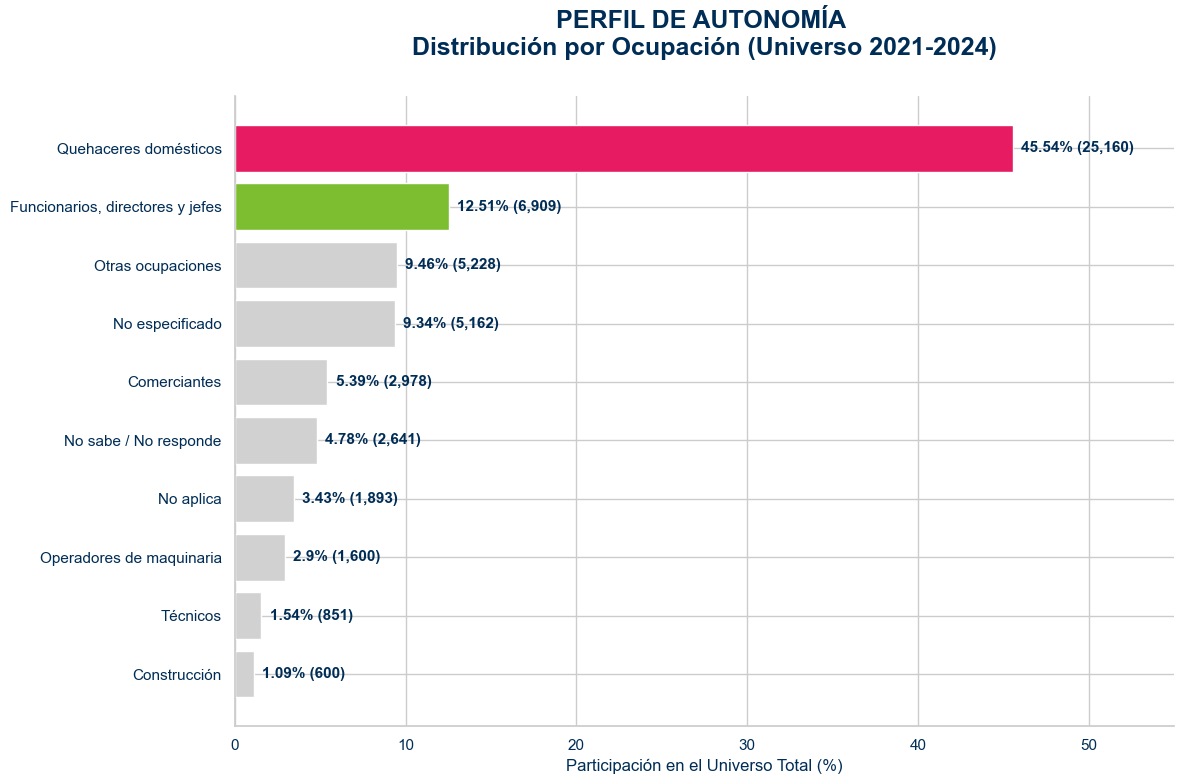

In [17]:
datos_ocupacion = {
    'Ocupación': [
        'Quehaceres domésticos', 'Funcionarios, directores y jefes', 
        'Otras ocupaciones', 'No especificado', 'Comerciantes', 
        'No sabe / No responde', 'No aplica', 'Operadores de maquinaria', 
        'Técnicos', 'Construcción'
    ],
    'Casos': [25160, 6909, 5228, 5162, 2978, 2641, 1893, 1600, 851, 600],
    'Participacion': [45.54, 12.51, 9.46, 9.34, 5.39, 4.78, 3.43, 2.90, 1.54, 1.09]
}

df_ocup = pd.DataFrame(datos_ocupacion).sort_values(by='Participacion', ascending=True)

ROSA_IMPACTO = "#E61B61"   # Para el foco de vulnerabilidad
AZUL_MARINO = "#002D56"    # Títulos y texto
VERDE_OFICIAL = "#7DBE31"  # Para autonomía profesional
GRIS_SUAVE = "#D1D1D1"     # Otros

colores = [GRIS_SUAVE] * len(df_ocup)
for i, ocup in enumerate(df_ocup['Ocupación']):
    if 'Quehaceres' in ocup: colores[i] = ROSA_IMPACTO
    if 'Funcionarios' in ocup: colores[i] = VERDE_OFICIAL

plt.figure(figsize=(12, 8))
bars = plt.barh(df_ocup['Ocupación'], df_ocup['Participacion'], color=colores)

for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2, 
             f'{width}% ({df_ocup["Casos"].iloc[i]:,})', 
             va='center', fontsize=11, fontweight='bold', color=AZUL_MARINO)

plt.title('PERFIL DE AUTONOMÍA \nDistribución por Ocupación (Universo 2021-2024)', 
          fontsize=18, fontweight='bold', color=AZUL_MARINO, pad=30)
plt.xlabel('Participación en el Universo Total (%)', fontsize=12, color=AZUL_MARINO)
plt.xlim(0, 55) # Espacio para las etiquetas de texto

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().tick_params(axis='both', colors=AZUL_MARINO)

plt.tight_layout()

nombre_archivo_autonomia = "14_perfil_autonomia_trabajo.png"
plt.savefig(nombre_archivo_autonomia, dpi=300, transparent=True, bbox_inches='tight')

print(f"Gráfico de autonomía guardado exitosamente como: {nombre_archivo_autonomia}")

plt.show()

In [18]:
# perfil de autonomía: educación y actividad económica (2021-2024)

# catálogos de escolaridad y ocupación
cat_escolaridad = {
    1: "Sin escolaridad", 2: "Preescolar", 3: "Primaria", 4: "Secundaria", 
    5: "Bachillerato/Preparatoria", 6: "Profesional", 7: "Posgrado", 
    8: "Bachillerato incompleto", 9: "Profesional incompleto", 
    10: "No especificado", 88: "No aplica", 99: "No especificado"
}

# asegurar tipos de datos numéricos para evitar fallos en el mapeo
df_homicidios_femeninos['ESCOLARIDA'] = pd.to_numeric(df_homicidios_femeninos['ESCOLARIDA'], errors='coerce')
df_homicidios_femeninos['OCUPACION'] = pd.to_numeric(df_homicidios_femeninos['OCUPACION'], errors='coerce')

# creación de variables descriptivas
df_homicidios_femeninos['NIVEL_EDUCATIVO'] = (
    df_homicidios_femeninos['ESCOLARIDA']
    .map(cat_escolaridad)
    .fillna("No especificado")
)

# definición de Segmento de Autonomía
def definir_segmento(nivel):
    if nivel in ["Profesional", "Posgrado", "Profesional incompleto"]:
        return "Educación Superior / Profesional"
    elif nivel in ["Sin escolaridad", "No especificado"]:
        return "Vulnerabilidad Educativa / S.D."
    else:
        return "Educación Básica / Media"

df_homicidios_femeninos['SEGMENTO_AUTONOMIA'] = df_homicidios_femeninos['NIVEL_EDUCATIVO'].apply(definir_segmento)

# salida de resultados para validación
print("Resumen de Perfil Educativo:")
print("-" * 40)
print(df_homicidios_femeninos['NIVEL_EDUCATIVO'].value_counts())

print("\nConcentración por Segmento de Autonomía:")
print("-" * 40)
print(df_homicidios_femeninos['SEGMENTO_AUTONOMIA'].value_counts())

Resumen de Perfil Educativo:
----------------------------------------
NIVEL_EDUCATIVO
Profesional                  10559
Secundaria                    9177
Primaria                      7076
Bachillerato incompleto       5917
Profesional incompleto        5823
Sin escolaridad               5087
No especificado               3857
Bachillerato/Preparatoria     2696
Posgrado                      2658
No aplica                     2002
Preescolar                     393
Name: count, dtype: int64

Concentración por Segmento de Autonomía:
----------------------------------------
SEGMENTO_AUTONOMIA
Educación Básica / Media            27261
Educación Superior / Profesional    19040
Vulnerabilidad Educativa / S.D.      8944
Name: count, dtype: int64


Gráfico de perfil educativo guardado exitosamente como: 15_perfil_educativo_autonomia_FINAL.png


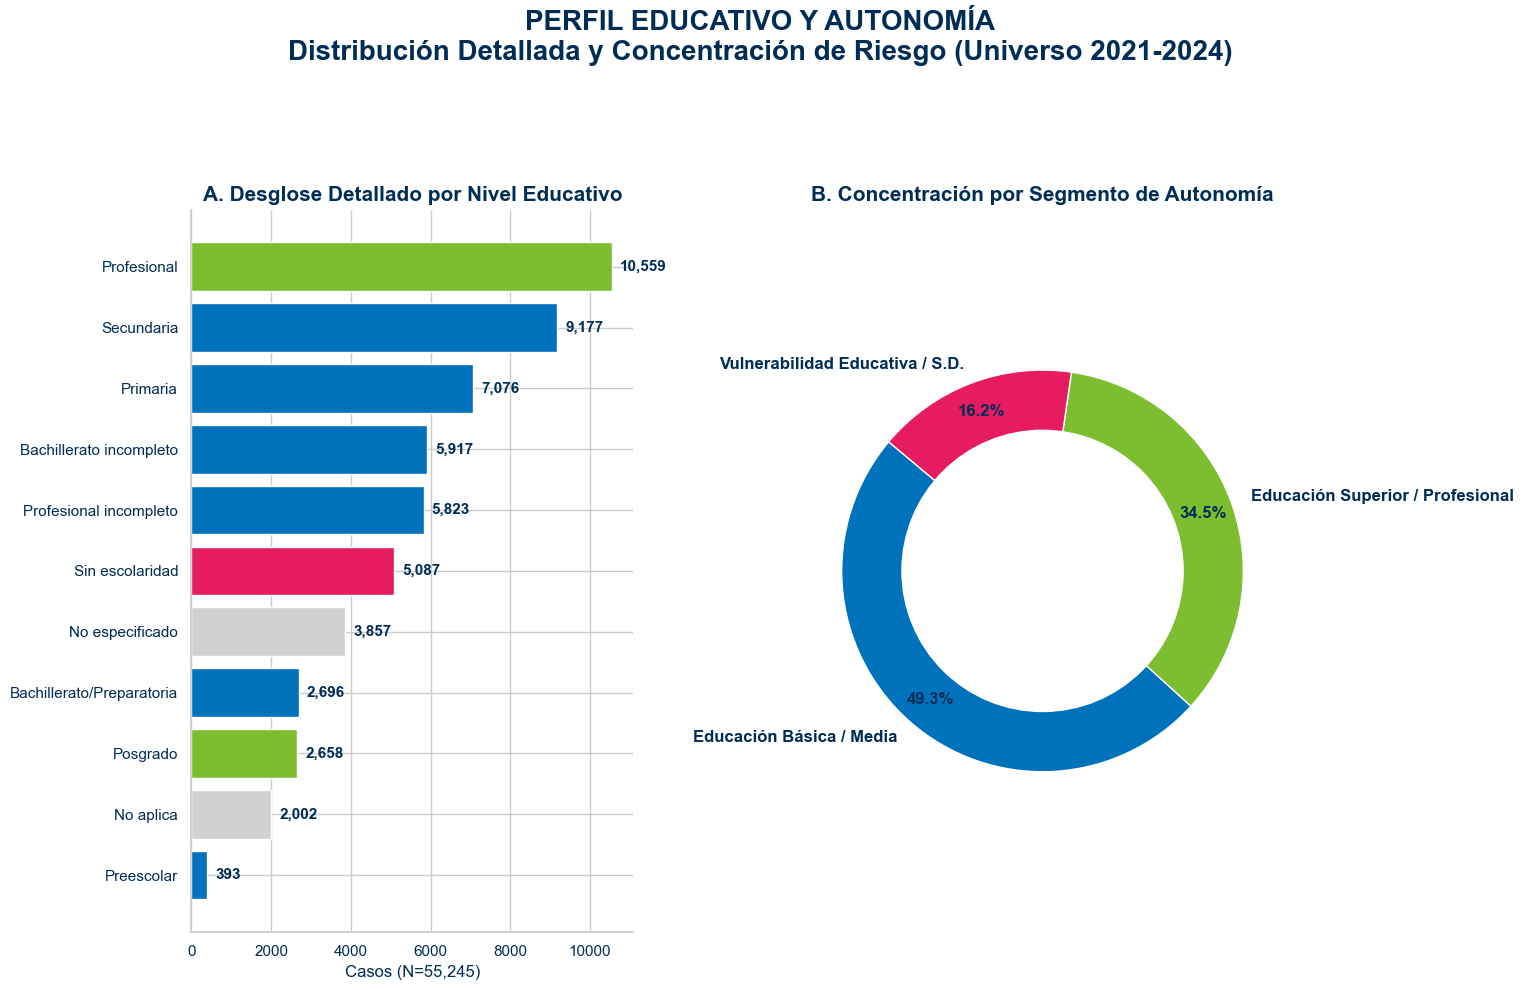

In [19]:
detalle_edu = pd.Series({
    'Profesional': 10559, 'Secundaria': 9177, 'Primaria': 7076,
    'Bachillerato incompleto': 5917, 'Profesional incompleto': 5823,
    'Sin escolaridad': 5087, 'No especificado': 3857,
    'Bachillerato/Preparatoria': 2696, 'Posgrado': 2658,
    'No aplica': 2002, 'Preescolar': 393
}).sort_values(ascending=True)

segmentos_aut = pd.Series({
    'Educación Básica / Media': 27261,
    'Educación Superior / Profesional': 19040,
    'Vulnerabilidad Educativa / S.D.': 8944
})

AZUL_MARINO = "#002D56"
ROSA_IMPACTO = "#E61B61"   # Vulnerabilidad / Sin Escolaridad
AZUL_PRINCIPAL = "#0072BC" # Básica / Media
VERDE_OFICIAL = "#7DBE31"  # Superior / Profesional
GRIS_SUAVE = "#D1D1D1"     # No especificado/No aplica

fig = plt.figure(figsize=(16, 10))
AZUL_MARINO_TEXT = AZUL_MARINO

ax1 = fig.add_subplot(1, 2, 1) # 1 fila, 2 columnas, gráfico 1

colores_barras = [AZUL_PRINCIPAL] * len(detalle_edu) # Por defecto azul media
colores_barras[detalle_edu.index.get_loc('Posgrado')] = VERDE_OFICIAL
colores_barras[detalle_edu.index.get_loc('Profesional')] = VERDE_OFICIAL
colores_barras[detalle_edu.index.get_loc('Primaria')] = AZUL_PRINCIPAL
colores_barras[detalle_edu.index.get_loc('Secundaria')] = AZUL_PRINCIPAL
colores_barras[detalle_edu.index.get_loc('Sin escolaridad')] = ROSA_IMPACTO
colores_barras[detalle_edu.index.get_loc('No especificado')] = GRIS_SUAVE
colores_barras[detalle_edu.index.get_loc('No aplica')] = GRIS_SUAVE

bars = ax1.barh(detalle_edu.index, detalle_edu.values, color=colores_barras)

for bar in bars:
    width = bar.get_width()
    ax1.text(width + 200, bar.get_y() + bar.get_height()/2, 
             f'{int(width):,}', va='center', fontsize=11, fontweight='bold', color=AZUL_MARINO_TEXT)

ax1.set_title('A. Desglose Detallado por Nivel Educativo', fontsize=15, fontweight='bold', color=AZUL_MARINO_TEXT)
ax1.set_xlabel('Casos (N=55,245)', fontsize=12, color=AZUL_MARINO_TEXT)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.tick_params(axis='both', colors=AZUL_MARINO_TEXT)


ax2 = fig.add_subplot(1, 2, 2) # 1 fila, 2 columnas, gráfico 2

colores_pastel = [AZUL_PRINCIPAL, VERDE_OFICIAL, ROSA_IMPACTO]

patches, texts, autotexts = ax2.pie(
    segmentos_aut.values, 
    labels=segmentos_aut.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colores_pastel, 
    pctdistance=0.85, 
    textprops={'fontsize': 12, 'color': AZUL_MARINO_TEXT, 'fontweight': 'bold'}
)

centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

ax2.set_title('B. Concentración por Segmento de Autonomía', fontsize=15, fontweight='bold', color=AZUL_MARINO_TEXT)
plt.axis('equal') # Asegura que sea un círculo


plt.suptitle('PERFIL EDUCATIVO Y AUTONOMÍA\nDistribución Detallada y Concentración de Riesgo (Universo 2021-2024)', 
             fontsize=20, fontweight='bold', color=AZUL_MARINO, y=1.02)

plt.tight_layout(pad=3.0)

nombre_archivo_perfil_edu = "15_perfil_educativo_autonomia_FINAL.png"
plt.savefig(nombre_archivo_perfil_edu, dpi=300, transparent=True, bbox_inches='tight')

print(f"Gráfico de perfil educativo guardado exitosamente como: {nombre_archivo_perfil_edu}")

plt.show()

In [20]:
# contexto regional (LATAM y Caribe)

codigos_wb = ['SG.VAW.REFL.ZS', 'SL.TLF.CACT.FE.ZS']

lcn_iso3 = [
    'ARG', 'ATG', 'BHS', 'BRB', 'BLZ', 'BOL', 'BRA', 'CHL', 'COL', 'CRI', 'CUB', 
    'DMA', 'DOM', 'ECU', 'SLV', 'GRD', 'GTM', 'GUY', 'HTI', 'HND', 'JAM', 'MEX', 
    'NIC', 'PAN', 'PRY', 'PER', 'KNA', 'LCA', 'VCT', 'SUR', 'TTO', 'URY', 'VEN'
]

print("Descargando datos regionales con etiquetas...")

# descarga con labels=True
df_alc_completo = wb.data.DataFrame(codigos_wb, economy=lcn_iso3, mrv=1, labels=True)

# identificación dinámica de columnas

for col in df_alc_completo.columns:
    if 'SG.VAW' in col:
        df_alc_completo = df_alc_completo.rename(columns={col: 'Prevalencia_Violencia'})
    if 'SL.TLF' in col:
        df_alc_completo = df_alc_completo.rename(columns={col: 'Participacion_Laboral_Fem'})
    if 'Country' in col or 'economy' in col:
        df_alc_completo = df_alc_completo.rename(columns={col: 'Pais'})

if 'Prevalencia_Violencia' not in df_alc_completo.columns:
    columnas_datos = [c for c in df_alc_completo.columns if c not in ['Pais', 'Country']]
    if len(columnas_datos) >= 2:
        df_alc_completo = df_alc_completo.rename(columns={
            columnas_datos[0]: 'Prevalencia_Violencia',
            columnas_datos[1]: 'Participacion_Laboral_Fem'
        })

# dropna y ordenamiento
df_alc_completo = df_alc_completo.dropna(subset=['Participacion_Laboral_Fem'])
df_alc_completo = df_alc_completo.sort_values('Participacion_Laboral_Fem', ascending=False)

print(f"\nDatos listos para el Dashboard.")
print("-" * 85)
print(df_alc_completo.head(50))

Descargando datos regionales con etiquetas...

Datos listos para el Dashboard.
-------------------------------------------------------------------------------------
                                   Pais  Participacion_Laboral_Fem
economy                                                           
BOL                             Bolivia                     72.868
BHS                        Bahamas, The                     70.728
PER                                Peru                     65.044
JAM                             Jamaica                     63.033
LCA                           St. Lucia                     61.995
BRB                            Barbados                     61.030
VCT      St. Vincent and the Grenadines                     59.217
PRY                            Paraguay                     59.011
HTI                               Haiti                     58.337
URY                             Uruguay                     57.255
PAN                            

Gráfico regional guardado exitosamente como: 16_contexto_regional_alc_laboral.png


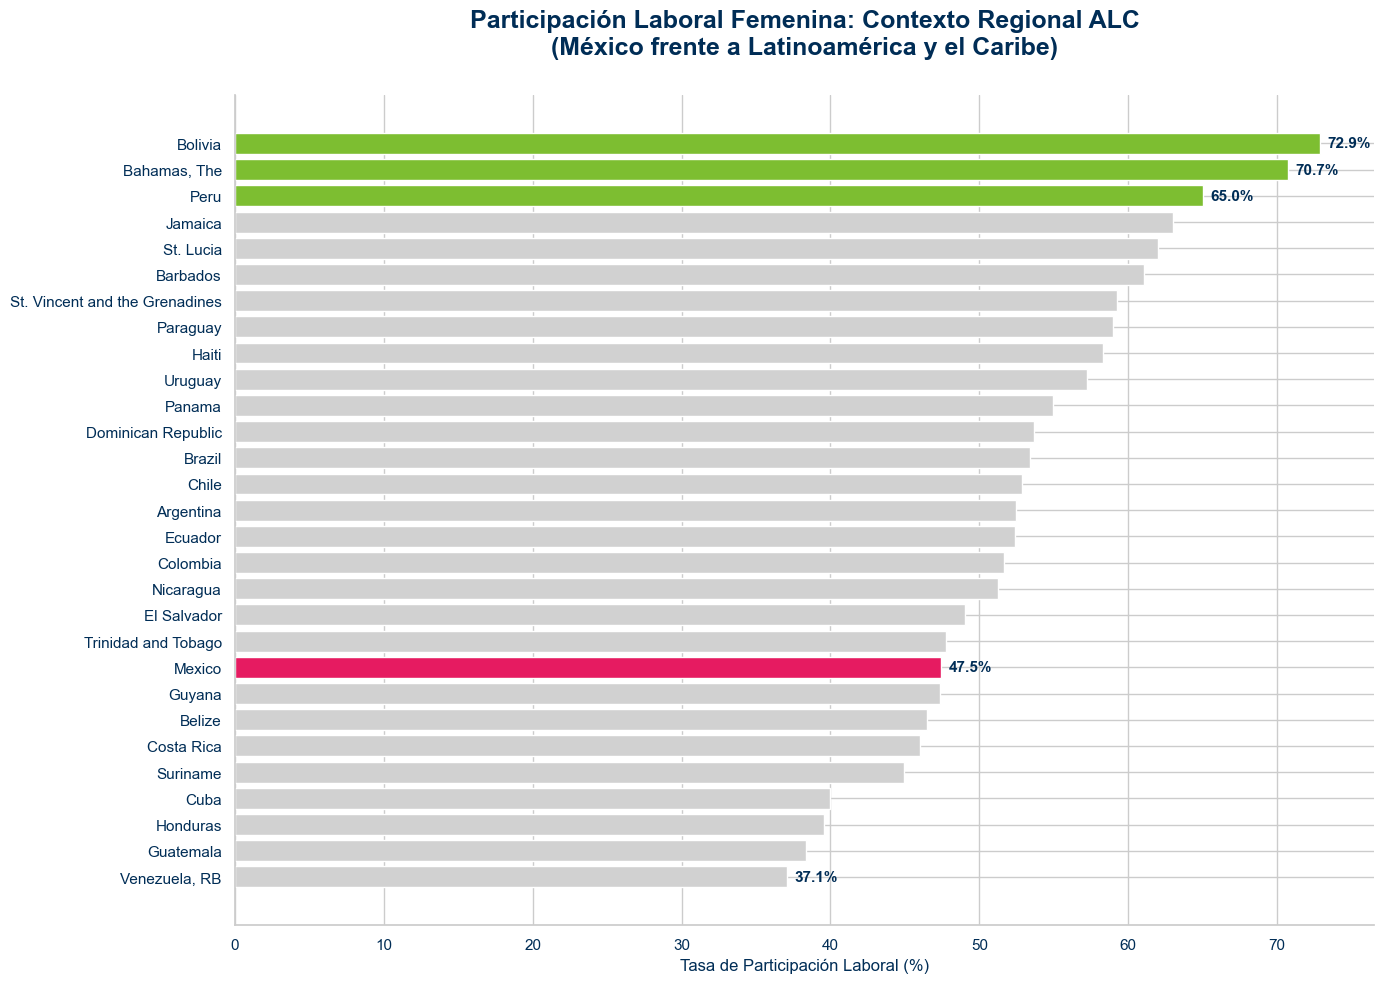

In [21]:
AZUL_MARINO = "#002D56"
ROSA_IMPACTO = "#E61B61"   # Para resaltar a México
VERDE_OFICIAL = "#7DBE31"  # Para los países con mejor desempeño
GRIS_SUAVE = "#D1D1D1"     # Resto de la región

# México Rosa, a los top 3 Verde y al resto Gris
colores_alc = []
for pais in df_alc_completo['Pais']:
    if pais == 'Mexico':
        colores_alc.append(ROSA_IMPACTO)
    elif pais in ['Bolivia', 'Bahamas, The', 'Peru']:
        colores_alc.append(VERDE_OFICIAL)
    else:
        colores_alc.append(GRIS_SUAVE)

plt.figure(figsize=(14, 10))
bars = plt.barh(df_alc_completo['Pais'], df_alc_completo['Participacion_Laboral_Fem'], color=colores_alc)

for i, bar in enumerate(bars):
    width = bar.get_width()
    pais_nombre = df_alc_completo['Pais'].iloc[i]
    if pais_nombre == 'Mexico' or width > 65 or i == len(bars)-1:
        plt.text(width + 0.5, bar.get_y() + bar.get_height()/2, 
                 f'{width:.1f}%', va='center', fontsize=11, 
                 fontweight='bold', color=AZUL_MARINO)

plt.title('Participación Laboral Femenina: Contexto Regional ALC\n(México frente a Latinoamérica y el Caribe)', 
          fontsize=18, fontweight='bold', color=AZUL_MARINO, pad=30)
plt.xlabel('Tasa de Participación Laboral (%)', fontsize=12, color=AZUL_MARINO)
plt.gca().invert_yaxis() # Los más altos arriba

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().tick_params(axis='both', colors=AZUL_MARINO)

plt.tight_layout()

nombre_archivo_alc = "16_contexto_regional_alc_laboral.png"
plt.savefig(nombre_archivo_alc, dpi=300, transparent=True, bbox_inches='tight')

print(f"Gráfico regional guardado exitosamente como: {nombre_archivo_alc}")

plt.show()

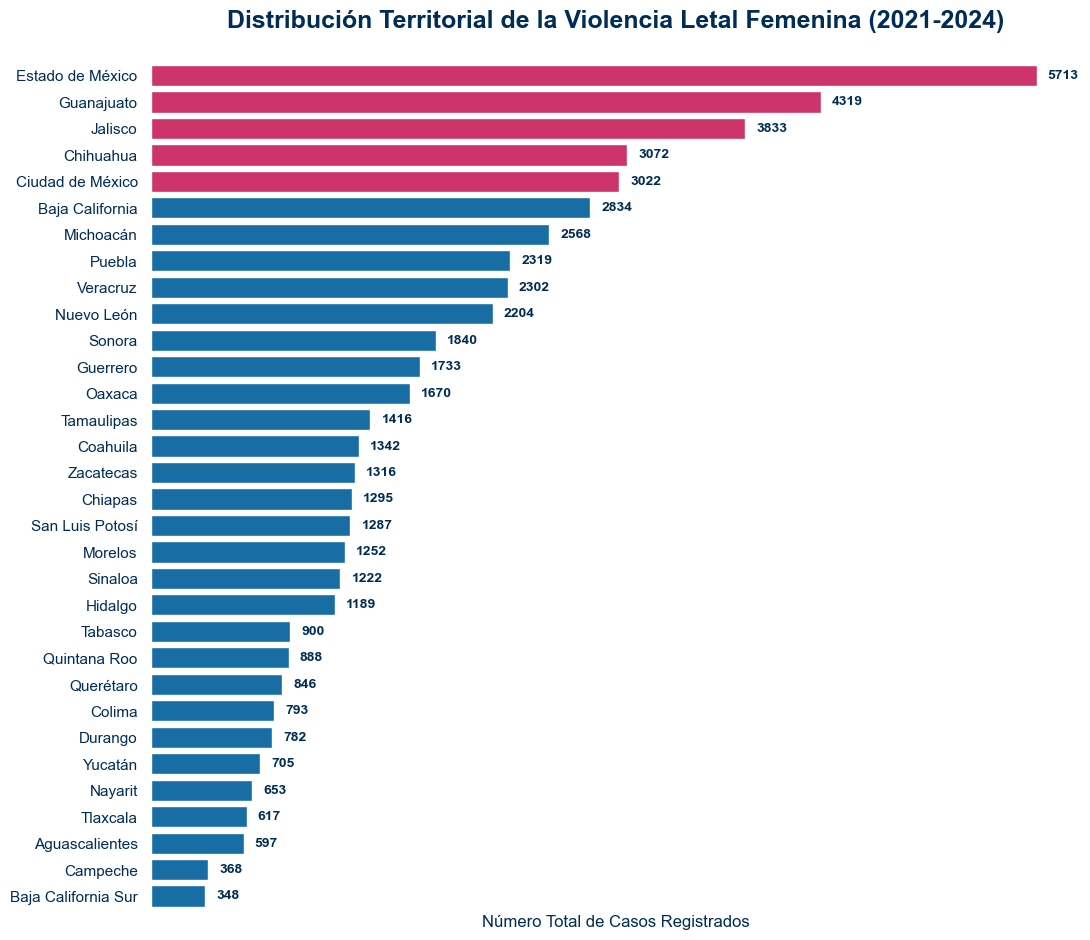

Primer gráfico guardado como '01_ranking_nacional_final.png'


In [22]:
# [0] Azul Principal, [1] Verde, [2] Azul Marino, [3] Rosa Impacto
paleta_colores = ["#0072BC", "#7DBE31", "#002D56", "#E61B61"]

df_ranking = (
    df_homicidios_femeninos
    .groupby('NOMBRE_ENTIDAD')
    .size()
    .reset_index(name='Casos')
    .sort_values(by='Casos', ascending=False)
)
# Rosa Impacto las primeras 5 entidades (las más críticas) 
# y de Azul Principal las demás.
colores_dinamicos = [paleta_colores[3] if i < 5 else paleta_colores[0] for i in range(len(df_ranking))]

plt.figure(figsize=(12, 11))
sns.set_style("white")

barras = sns.barplot(
    data=df_ranking, 
    x='Casos', 
    y='NOMBRE_ENTIDAD', 
    palette=colores_dinamicos,
    hue='NOMBRE_ENTIDAD',
    legend=False
)

plt.title('Distribución Territorial de la Violencia Letal Femenina (2021-2024)', 
          fontsize=18, fontweight='bold', color=paleta_colores[2], pad=25)
plt.xlabel('Número Total de Casos Registrados', fontsize=12, color=paleta_colores[2])
plt.ylabel('', fontsize=12) 

for i in barras.containers:
    barras.bar_label(i, padding=8, color=paleta_colores[2], fontweight='bold', fontsize=10)

sns.despine(left=True, bottom=True)
plt.gca().tick_params(axis='y', labelsize=11, labelcolor=paleta_colores[2])
plt.xticks([]) 

plt.savefig('01_ranking_nacional_final.png', dpi=300, bbox_inches='tight', transparent=True)

plt.show()

print("Primer gráfico guardado como '01_ranking_nacional_final.png'")

In [23]:
# cálculo del acumulado y el porcentaje
df_ranking['Porcentaje'] = (df_ranking['Casos'] / df_ranking['Casos'].sum()) * 100
df_ranking['Porcentaje_Acumulado'] = df_ranking['Porcentaje'].cumsum()

# identificación de los estados que concentran el 50% de la violencia
estados_criticos = df_ranking[df_ranking['Porcentaje_Acumulado'] <= 50]

print(f"Los siguientes {len(estados_criticos)} estados concentran el 50% de la violencia letal en México:")
print(estados_criticos[['NOMBRE_ENTIDAD', 'Casos', 'Porcentaje']])

Los siguientes 7 estados concentran el 50% de la violencia letal en México:
      NOMBRE_ENTIDAD  Casos  Porcentaje
10  Estado de México   5713   10.341207
11        Guanajuato   4319    7.817902
14           Jalisco   3833    6.938184
5          Chihuahua   3072    5.560684
6   Ciudad de México   3022    5.470178
1    Baja California   2834    5.129876
15         Michoacán   2568    4.648384


In [24]:
 # solución del error anterior
clave_defunciones = os.path.join('EDR', 'conjunto_de_datos_defunciones_registradas24_csv.csv')

if clave_defunciones in inventario_datos:
    ruta_archivo = inventario_datos[clave_defunciones]
    # cargamos con low_memory=False porque los archivos de INEGI son pesados y tienen tipos mixtos
    df_universo = pd.read_csv(ruta_archivo, low_memory=False, encoding='utf-8')
    print(f"¡Cargado con éxito! Registros totales: {len(df_universo):,}")
else:
    print("No se encontró el archivo. Revisa si la clave en 'inventario_datos' es exacta.")

¡Cargado con éxito! Registros totales: 819,672


In [25]:
print(df_universo.columns.tolist())

['ent_regis', 'mun_regis', 'tloc_regis', 'loc_regis', 'ent_resid', 'mun_resid', 'tloc_resid', 'loc_resid', 'ent_ocurr', 'mun_ocurr', 'tloc_ocurr', 'loc_ocurr', 'causa_def', 'cod_adicio', 'lista_mex', 'sexo', 'ent_nac', 'afromex', 'conindig', 'lengua', 'cve_lengua', 'nacionalid', 'nacesp_cve', 'edad', 'sem_gest', 'gramos', 'dia_ocurr', 'mes_ocurr', 'anio_ocur', 'dia_regis', 'mes_regis', 'anio_regis', 'dia_nacim', 'mes_nacim', 'anio_nacim', 'cond_act', 'ocupacion', 'escolarida', 'edo_civil', 'tipo_defun', 'ocurr_trab', 'lugar_ocur', 'par_agre', 'vio_fami', 'asist_medi', 'cirugia', 'natviole', 'necropsia', 'usonecrops', 'encefalica', 'donador', 'sitio_ocur', 'cond_cert', 'derechohab', 'embarazo', 'rel_emba', 'horas', 'minutos', 'capitulo', 'grupo', 'lista1', 'gr_lismex', 'area_ur', 'edad_agru', 'complicaro', 'dia_cert', 'mes_cert', 'anio_cert', 'maternas', 'ent_ocules', 'mun_ocules', 'loc_ocules', 'razon_m', 'dis_re_oax']


In [26]:
# filtramos por sexo (2 = Mujer)
df_universo = df_universo[df_universo['sexo'] == 2].copy()

# limpieza de Escolaridad (usando el nombre exacto 'escolarida')
# creamos un diccionario para que el análisis sea legible para el BID
dic_edu = {
    1: 'Sin escolaridad', 2: 'Preescolar', 3: 'Primaria Inc.', 4: 'Primaria Comp.',
    5: 'Secundaria Inc.', 6: 'Secundaria Comp.', 7: 'Bachillerato Inc.', 
    8: 'Bachillerato Comp.', 9: 'Profesional', 10: 'Posgrado', 88: 'No aplica', 99: 'No especificado'
}
df_universo['ESCOLARIDAD_DESC'] = df_universo['escolarida'].map(dic_edu)

print(f"Dataset listo con {len(df_universo):,} registros de mujeres.")

Dataset listo con 360,814 registros de mujeres.


In [27]:
def clasificar_riesgo_invisible(row):
    # sitio_ocur 1 o 2 suele ser vivienda
    en_vivienda = row['sitio_ocur'] in [1, 2]
    # causas de proximidad (primeros 3 caracteres de causa_def)
    causa = str(row['causa_def'])[:3]
    es_proximidad = causa in ['X91', 'X92', 'X93', 'X94', 'X95', 'X99', 'Y00']
    
    # vio_fami: 2 es 'No', 9 es 'No especificado'
    if en_vivienda and es_proximidad and row['vio_fami'] in [2, 9]:
        return 'Abuso Previo Invisible'
    elif row['vio_fami'] == 1:
        return 'Abuso con Antecedente'
    else:
        return 'Otro Perfil'

df_universo['INDICE_SOSPECHA'] = df_universo.apply(clasificar_riesgo_invisible, axis=1)

In [28]:
# cruce estratégico
pd.crosstab(df_universo['ESCOLARIDAD_DESC'], df_universo['sitio_ocur'], normalize='index') * 100

sitio_ocur,1,2,3,4,5,6,7,8,9,10,11,12,13,99
ESCOLARIDAD_DESC,,,,,,,,,,,,,,
Bachillerato Comp.,7.286394,1.825433,24.029759,5.806105,0.747814,0.375825,0.099709,1.587667,7.466636,2.228102,42.353122,5.065961,0.157233,0.970241
Bachillerato Inc.,12.668034,2.802461,31.533379,3.987241,0.318979,0.592390,0.159490,1.367054,5.058100,5.536569,28.913192,5.263158,0.318979,1.480975
No aplica,31.928049,17.942664,23.912310,1.708825,0.112423,0.359753,0.112423,3.159078,5.385048,0.955593,11.691962,1.753794,0.000000,0.978078
No especificado,16.453047,3.574854,25.425059,2.458802,0.244136,0.165664,0.095911,1.229401,4.926323,1.892057,30.804778,3.592292,0.069753,9.067922
Posgrado,4.122563,0.724234,14.373259,15.877437,0.724234,0.167131,0.389972,3.621170,19.721448,1.949861,34.428969,3.119777,0.167131,0.612813
Preescolar,20.689655,4.497751,20.539730,2.098951,0.149925,0.599700,0.000000,2.848576,5.547226,3.748126,34.032984,3.598201,0.000000,1.649175
Primaria Comp.,8.485871,2.245572,20.579685,3.409623,0.495184,0.415117,0.129339,1.218250,4.424626,1.093839,51.380848,4.892710,0.060358,1.168978
Primaria Inc.,9.350614,2.778090,20.035959,3.383651,0.370828,0.408286,0.132349,1.038818,4.407486,0.672984,52.606410,3.913049,0.024972,0.876503
Profesional,5.161029,1.232154,19.079942,11.188992,0.634522,0.261925,0.099605,2.445863,11.122588,2.158114,40.657395,5.009776,0.062714,0.885380


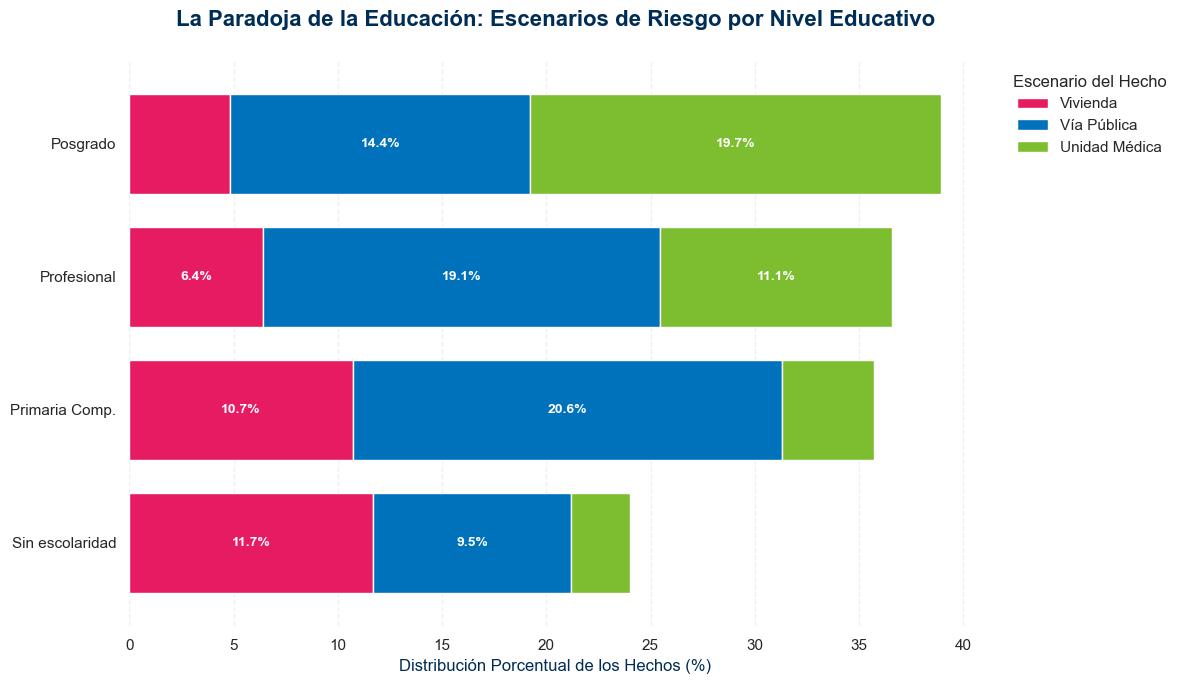

Gráfico 'La Paradoja de la Educación' guardado exitosamente.


In [29]:
# [0] Azul Principal, [1] Verde, [2] Azul Marino, [3] Rosa Impacto
paleta_colores = ["#0072BC", "#7DBE31", "#002D56", "#E61B61"]
AZUL_MARINO = paleta_colores[2]

COLORES_GRAFICO = [paleta_colores[3], paleta_colores[0], paleta_colores[1]]

dic_lugares = {
    1: 'Vivienda', 2: 'Vivienda',
    3: 'Vía Pública',
    4: 'Comercio o Área Pública',
    9: 'Unidad Médica'
}
df_universo['LUGAR_HECHOS'] = df_universo['sitio_ocur'].map(dic_lugares).fillna('Otro')

tabla_cruzada = pd.crosstab(df_universo['ESCOLARIDAD_DESC'], 
                            df_universo['LUGAR_HECHOS'], 
                            normalize='index') * 100

interes = ['Sin escolaridad', 'Primaria Comp.', 'Profesional', 'Posgrado']
columnas_clave = ['Vivienda', 'Vía Pública', 'Unidad Médica'] 
df_plot = tabla_cruzada.loc[interes, columnas_clave]

fig, ax = plt.subplots(figsize=(12, 7))
plt.rcParams['font.family'] = 'sans-serif'

df_plot.plot(
    kind='barh', 
    stacked=True, 
    ax=ax, 
    color=COLORES_GRAFICO,
    width=0.75
)

plt.title('La Paradoja de la Educación: Escenarios de Riesgo por Nivel Educativo', 
          fontsize=16, fontweight='bold', color=AZUL_MARINO, pad=25)
plt.xlabel('Distribución Porcentual de los Hechos (%)', fontsize=12, color=AZUL_MARINO)
plt.ylabel('', fontsize=12) 

plt.legend(title='Escenario del Hecho', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

for n, x in enumerate([*df_plot.index.values]):
    for (proportion, x_loc) in zip(df_plot.loc[x],
                                   df_plot.loc[x].cumsum()):
        if proportion > 5: 
            plt.text(x_loc - (proportion / 2),
                     n,
                     f'{np.round(proportion, 1)}%', 
                     color="white",
                     fontsize=10,
                     fontweight='bold',
                     va="center", 
                     ha="center")

plt.grid(axis='x', linestyle='--', alpha=0.3)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.savefig('02_paradoja_educacion_final.png', dpi=300, bbox_inches='tight', transparent=True)

plt.tight_layout()
plt.show()

print("Gráfico 'La Paradoja de la Educación' guardado exitosamente.")

In [30]:
# comparativa estratégica (perfil educativo)

# aseguramos que los nombres de los estados coincidan con tu lista limpia
nombres_alta_incidencia = estados_criticos['NOMBRE_ENTIDAD'].unique().tolist()

# segmentación con la nomenclatura profesional aprobada
df_homicidios_femeninos['GRUPO_RIESGO'] = np.where(
    df_homicidios_femeninos['NOMBRE_ENTIDAD'].isin(nombres_alta_incidencia), 
    'Entidades de Alta Incidencia', 
    'Otras Entidades'
)

# tabulación cruzada normalizada
comparativa_edu = pd.crosstab(
    df_homicidios_femeninos['GRUPO_RIESGO'], 
    df_homicidios_femeninos['NIVEL_EDUCATIVO'], 
    normalize='index'
) * 100

# selección inteligente de columnas 
keywords = ['Profesional', 'Bachillerato', 'Preparatoria', 'Secundaria', 'Superior', 'Licenciatura']
columnas_finales = [col for col in comparativa_edu.columns if any(k in str(col) for k in keywords)]

print("¿DIFIERE EL PERFIL EDUCATIVO SEGÚN EL NIVEL DE INCIDENCIA?")
print("-" * 85)

if not columnas_finales:
    print("Aviso: No se detectaron las etiquetas estándar. Mostrando panorama completo:")
    print(comparativa_edu.round(2))
else:
    # ordenamos de mayor a menor nivel académico si es posible
    print(comparativa_edu[columnas_finales].round(2))

print("-" * 85)

¿DIFIERE EL PERFIL EDUCATIVO SEGÚN EL NIVEL DE INCIDENCIA?
-------------------------------------------------------------------------------------
NIVEL_EDUCATIVO               Bachillerato incompleto  \
GRUPO_RIESGO                                            
Entidades de Alta Incidencia                    10.58   
Otras Entidades                                 10.82   

NIVEL_EDUCATIVO               Bachillerato/Preparatoria  Profesional  \
GRUPO_RIESGO                                                           
Entidades de Alta Incidencia                       5.53        19.65   
Otras Entidades                                    4.33        18.66   

NIVEL_EDUCATIVO               Profesional incompleto  Secundaria  
GRUPO_RIESGO                                                      
Entidades de Alta Incidencia                    9.83       16.66  
Otras Entidades                                11.14       16.57  
---------------------------------------------------------------------

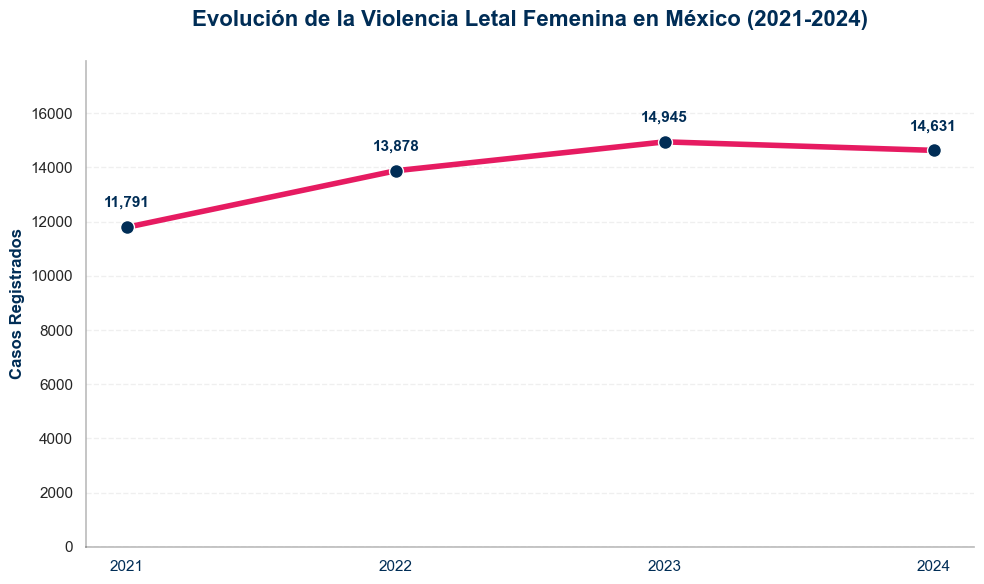

Gráfico guardado como '03_tendencia_temporal_final.png'
Análisis finalizado. Registros totales procesados: 55,245


In [31]:
paleta_colores = ["#0072BC", "#7DBE31", "#002D56", "#E61B61"]
ROSA_IMPACTO = paleta_colores[3]
AZUL_MARINO = paleta_colores[2]

df_homicidios_femeninos['ANIO_REGISTRO'] = pd.to_numeric(df_homicidios_femeninos['ANIO_REGISTRO'], errors='coerce')

tendencia = (
    df_homicidios_femeninos
    .dropna(subset=['ANIO_REGISTRO'])
    .groupby('ANIO_REGISTRO')
    .size()
    .reset_index(name='Total_Anual')
    .sort_values('ANIO_REGISTRO')
)

plt.figure(figsize=(10, 6))
sns.set_style("white")

plt.plot(
    tendencia['ANIO_REGISTRO'], 
    tendencia['Total_Anual'], 
    marker='o', 
    linestyle='-', 
    color=ROSA_IMPACTO, 
    linewidth=4, 
    markersize=10,
    label='Total Nacional',
    markerfacecolor=AZUL_MARINO, 
    markeredgecolor="white"
)

delta = tendencia['Total_Anual'].max() * 0.05
for x, y in zip(tendencia['ANIO_REGISTRO'], tendencia['Total_Anual']):
    plt.text(x, y + delta, f'{int(y):,}', 
             ha='center', fontweight='bold', color=AZUL_MARINO, fontsize=11)

plt.title('Evolución de la Violencia Letal Femenina en México (2021-2024)', 
          fontsize=16, fontweight='bold', color=AZUL_MARINO, pad=25)

plt.xticks(tendencia['ANIO_REGISTRO'].unique().astype(int), fontsize=11, color=AZUL_MARINO)
plt.ylabel('Casos Registrados', fontweight='bold', color=AZUL_MARINO)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.ylim(0, tendencia['Total_Anual'].max() * 1.2) 

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_alpha(0.3)
plt.gca().spines['bottom'].set_alpha(0.3)

plt.savefig('03_tendencia_temporal_final.png', dpi=300, bbox_inches='tight', transparent=True)

plt.tight_layout()
plt.show()

print(f"Gráfico guardado como '03_tendencia_temporal_final.png'")
print(f"Análisis finalizado. Registros totales procesados: {tendencia['Total_Anual'].sum():,}")

In [32]:
def clasificar_medio_robusta(causa):
    causa = str(causa).upper()
    
    # Mapeo de códigos CIE-10 (INEGI)
    if any(x in causa for x in ['X93', 'X94', 'X95']):
        return 'Arma de Fuego'
    elif 'X99' in causa:
        return 'Arma Blanca'
    elif any(x in causa for x in ['X91', 'X92']):
        return 'Ahorcamiento/Sofocación'
    elif 'Y00' in causa:
        return 'Agresión Física/Golpes'
    elif any(x in causa for x in ['X85', 'X86', 'X87', 'X88', 'X89', 'X90']):
        return 'Sustancias/Venenos'
    else:
        return 'Otro/No especificado'

print("Función 'clasificar_medio_robusta' definida correctamente.")

Función 'clasificar_medio_robusta' definida correctamente.


In [33]:
# análisis de medio de agresión 

# aseguramos que la columna MEDIO_AGRESION exista con la clasificación
df_homicidios_femeninos['MEDIO_AGRESION'] = df_homicidios_femeninos['CAUSA_DEF'].apply(clasificar_medio_robusta)

# generar la tabla cruzada
medios_comparativa = pd.crosstab(
    df_homicidios_femeninos['GRUPO_RIESGO'], 
    df_homicidios_femeninos['MEDIO_AGRESION'], 
    normalize='index'
) * 100

# selección de columnas
columnas_deseadas = ['Arma de Fuego', 'Arma Blanca', 'Ahorcamiento/Sofocación', 'Agresión Física/Golpes']
columnas_existentes = [col for col in columnas_deseadas if col in medios_comparativa.columns]

print("Perfil del Medio de Agresión por Zona (%)")
print("-" * 80)

if len(columnas_existentes) > 0:
    # imprimir solo las que encontramos
    print(medios_comparativa[columnas_existentes].round(2))
else:
    # si no encontró ninguna de las etiquetas, imprimimos todo para ver qué nombres generó
    print("Aviso: No se encontraron las etiquetas específicas. Mostrando todas las categorías detectadas:")
    print(medios_comparativa.round(2))

print("-" * 80)

Perfil del Medio de Agresión por Zona (%)
--------------------------------------------------------------------------------
MEDIO_AGRESION                Arma de Fuego  Arma Blanca  \
GRUPO_RIESGO                                               
Entidades de Alta Incidencia          20.24         3.45   
Otras Entidades                       13.40         2.94   

MEDIO_AGRESION                Ahorcamiento/Sofocación  Agresión Física/Golpes  
GRUPO_RIESGO                                                                   
Entidades de Alta Incidencia                     4.85                    0.17  
Otras Entidades                                  3.05                    0.33  
--------------------------------------------------------------------------------


In [34]:
# Definición de coordenadas para los estados de México (Centro geográfico aproximado)
geo_estados = {
    'ESTADO DE MÉXICO': {'lat': 19.3502, 'lon': -99.6312},
    'CIUDAD DE MÉXICO': {'lat': 19.4326, 'lon': -99.1332},
    'VERACRUZ': {'lat': 19.1738, 'lon': -96.1342},
    'JALISCO': {'lat': 20.6595, 'lon': -103.3494},
    'NUEVO LEÓN': {'lat': 25.6866, 'lon': -100.3161},
    'PUEBLA': {'lat': 19.0414, 'lon': -98.2063},
    'CHIHUAHUA': {'lat': 28.6330, 'lon': -106.0691},
    'GUANAJUATO': {'lat': 21.0190, 'lon': -101.2574},
    'BAJA CALIFORNIA': {'lat': 30.8406, 'lon': -115.2838},
    'MICHOACÁN': {'lat': 19.5665, 'lon': -101.7064},
    'GUERRERO': {'lat': 17.4392, 'lon': -99.5451},
    'OAXACA': {'lat': 17.0732, 'lon': -96.7266}
}

print("Diccionario 'geo_estados' creado con éxito.")

Diccionario 'geo_estados' creado con éxito.


In [35]:
# mapa
# integracicón de coordenadas valiadas 

geo_preparado = {k.upper().strip(): v for k, v in geo_estados.items()}

def obtener_coordenada(estado, eje):
    if pd.isna(estado): return None
    
    # limpiamos el nombre del estado (mayúsculas y sin espacios extra)
    nombre_limpio = str(estado).upper().strip()
    
    try:
        return geo_preparado[nombre_limpio][eje]
    except KeyError:
        # Si falla, imprimimos el error pero no detenemos el código
        print(f"Alerta: '{estado}' no se encontró en el diccionario de coordenadas.")
        return None

# asignamos usando la función segura
estados_criticos = df_ranking[df_ranking['Porcentaje_Acumulado'] <= 50].copy()

estados_criticos.loc[:, 'lat'] = estados_criticos['NOMBRE_ENTIDAD'].apply(lambda x: obtener_coordenada(x, 'lat'))
estados_criticos.loc[:, 'lon'] = estados_criticos['NOMBRE_ENTIDAD'].apply(lambda x: obtener_coordenada(x, 'lon'))

# verificación final
casos_sin_geo = estados_criticos['lat'].isna().sum()
if casos_sin_geo == 0:
    print("Todas las coordenadas integradas correctamente.")
else:
    print(f"Atención: {casos_sin_geo} estados se quedaron sin coordenadas.")

Todas las coordenadas integradas correctamente.


In [36]:
# solución problema con "Baja California" en el diccionario 
if 'BAJA CALIFORNIA' not in [k.upper() for k in geo_estados.keys()]:
    posibles_nombres = ['Baja California Norte', 'BAJA CALIFORNIA NORTE', 'BC']
    for nombre in posibles_nombres:
        if nombre in geo_estados:
            geo_estados['Baja California'] = geo_estados[nombre]
            break

def limpieza_extrema(texto):
    if pd.isna(texto): return None
    import unicodedata
    s = str(texto).upper().strip()
    s = ''.join((c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn'))
    return s

geo_limpio = {limpieza_extrema(k): v for k, v in geo_estados.items()}

estados_criticos.loc[:, 'lat'] = estados_criticos['NOMBRE_ENTIDAD'].apply(
    lambda x: geo_limpio.get(limpieza_extrema(x), {}).get('lat')
)
estados_criticos.loc[:, 'lon'] = estados_criticos['NOMBRE_ENTIDAD'].apply(
    lambda x: geo_limpio.get(limpieza_extrema(x), {}).get('lon')
)

print(f"Coordenadas de Baja California: {estados_criticos[estados_criticos['NOMBRE_ENTIDAD'].str.contains('Baja', case=False)]['lat'].values}")

Coordenadas de Baja California: [30.8406]


In [37]:
# coordenadas para evitar NAN 

# definición coordenadas estándar para Baja California (Mexicali/Tijuana centro)
coords_bc = {'lat': 30.8406, 'lon': -115.2838}

def rescatar_coordenadas(row):
    nombre = str(row['NOMBRE_ENTIDAD']).upper()
    
    if pd.notna(row['lat']) and row['lat'] != 0:
        return row['lat'], row['lon']
    
    if 'BAJA' in nombre and 'SUR' not in nombre:
        return coords_bc['lat'], coords_bc['lon']
    
    if 'BAJA' in nombre and 'SUR' in nombre:
        return 24.1426, -110.3123
        
    return row['lat'], row['lon']

# aplicamos la corrección a las dos columnas al mismo tiempo
estados_criticos[['lat', 'lon']] = estados_criticos.apply(
    lambda r: pd.Series(rescatar_coordenadas(r)), axis=1
)

print("VERIFICACIÓN FINAL DE COORDENADAS:")
print(estados_criticos[['NOMBRE_ENTIDAD', 'lat', 'lon']])

VERIFICACIÓN FINAL DE COORDENADAS:
      NOMBRE_ENTIDAD      lat       lon
10  Estado de México  19.3502  -99.6312
11        Guanajuato  21.0190 -101.2574
14           Jalisco  20.6595 -103.3494
5          Chihuahua  28.6330 -106.0691
6   Ciudad de México  19.4326  -99.1332
1    Baja California  30.8406 -115.2838
15         Michoacán  19.5665 -101.7064


In [38]:
ROSA_IMPACTO = "#E61B61"  
VERDE_OFICIAL = "#7DBE31"  
AZUL_MARINO = "#002D56"   
AZUL_OCEANO = "#E3F2FD" 

geo_estados = {
    'ESTADO DE MÉXICO': {'lat': 19.35, 'lon': -99.63},
    'GUANAJUATO': {'lat': 21.01, 'lon': -101.25},
    'BAJA CALIFORNIA': {'lat': 30.8406, 'lon': -115.2838},
    'CHIHUAHUA': {'lat': 28.63, 'lon': -106.06},
    'MICHOACÁN': {'lat': 19.56, 'lon': -101.70},
    'JALISCO': {'lat': 20.65, 'lon': -103.34},
    'GUERRERO': {'lat': 17.43, 'lon': -99.50},
    'CIUDAD DE MÉXICO': {'lat': 19.43, 'lon': -99.13},
    'VERACRUZ': {'lat': 19.17, 'lon': -96.13},
    'PUEBLA': {'lat': 19.03, 'lon': -98.20},
    'COLIMA': {'lat': 19.12, 'lon': -104.00},
    'QUINTANA ROO': {'lat': 19.18, 'lon': -88.47},
    'MORELOS': {'lat': 18.68, 'lon': -99.10},
    'OAXACA': {'lat': 17.07, 'lon': -96.72},
    'NUEVO LEÓN': {'lat': 25.67, 'lon': -100.31}
}

estados_criticos['NOMBRE_ENTIDAD'] = estados_criticos['NOMBRE_ENTIDAD'].astype(str).str.upper().str.strip()
estados_criticos['lat'] = estados_criticos['NOMBRE_ENTIDAD'].map(lambda x: geo_estados.get(x, {}).get('lat'))
estados_criticos['lon'] = estados_criticos['NOMBRE_ENTIDAD'].map(lambda x: geo_estados.get(x, {}).get('lon'))

df_mapa = estados_criticos.dropna(subset=['lat', 'lon']).copy()

fig_mapa = px.scatter_geo(
    df_mapa,
    lat='lat',
    lon='lon',
    size='Casos', 
    hover_name='NOMBRE_ENTIDAD',
    hover_data={'Casos': True, 'lat': False, 'lon': False},
    title='<b>Focos Críticos: Concentración Territorial de Violencia</b>',
    projection="natural earth",
    color_discrete_sequence=[ROSA_IMPACTO],
    size_max=40  
)

fig_mapa.update_geos(
    lataxis_range=[14, 33], 
    lonaxis_range=[-118, -86], 
    showcountries=True, 
    countrycolor="#CCCCCC", 
    showland=True, 
    landcolor="#FDFDFD", 
    showocean=True, 
    oceancolor=AZUL_OCEANO, 
    showlakes=True,
    lakecolor=AZUL_OCEANO, 
    showframe=False 
)

fig_mapa.update_layout(
    title_font_size=22,
    title_font_color=AZUL_MARINO,
    margin={"r":0,"t":70,"l":0,"b":0},
    paper_bgcolor="white",
    height=600 # Altura ideal para visualización
)

fig_mapa.show()

# 9. Intento de guardado automático (requiere kaleido)
try:
    fig_mapa.write_image("04_mapa_focos_rojos.png", scale=3)
    print("Mapa guardado exitosamente como '04_mapa_focos_rojos.png'")
except:
    print("Mapa generado. Usa el icono de la cámara para descargar como imagen si no se guardó el archivo.")

Mapa guardado exitosamente como '04_mapa_focos_rojos.png'


In [39]:
# análisis de medio de agresión 

# aseguramos que la columna MEDIO_AGRESION exista con la clasificación
df_homicidios_femeninos['MEDIO_AGRESION'] = df_homicidios_femeninos['CAUSA_DEF'].apply(clasificar_medio_robusta)

# generar la tabla cruzada
medios_comparativa = pd.crosstab(
    df_homicidios_femeninos['GRUPO_RIESGO'], 
    df_homicidios_femeninos['MEDIO_AGRESION'], 
    normalize='index'
) * 100

# selección de columnas
columnas_deseadas = ['Arma de Fuego', 'Arma Blanca', 'Ahorcamiento/Sofocación', 'Agresión Física/Golpes']
columnas_existentes = [col for col in columnas_deseadas if col in medios_comparativa.columns]

print("Perfil del Medio de Agresión por Zona (%)")
print("-" * 80)

if len(columnas_existentes) > 0:
    # imprimir solo las que encontramos
    print(medios_comparativa[columnas_existentes].round(2))
else:
    # si no encontró ninguna de las etiquetas, imprimimos todo para ver qué nombres generó
    print("Aviso: No se encontraron las etiquetas específicas. Mostrando todas las categorías detectadas:")
    print(medios_comparativa.round(2))

print("-" * 80)

Perfil del Medio de Agresión por Zona (%)
--------------------------------------------------------------------------------
MEDIO_AGRESION                Arma de Fuego  Arma Blanca  \
GRUPO_RIESGO                                               
Entidades de Alta Incidencia          20.24         3.45   
Otras Entidades                       13.40         2.94   

MEDIO_AGRESION                Ahorcamiento/Sofocación  Agresión Física/Golpes  
GRUPO_RIESGO                                                                   
Entidades de Alta Incidencia                     4.85                    0.17  
Otras Entidades                                  3.05                    0.33  
--------------------------------------------------------------------------------


In [40]:
# análisis de la columna CAUSA_DEF
conteo_completo = df_homicidios_femeninos['CAUSA_DEF'].value_counts()

print(f"Se detectaron {len(conteo_completo)} categorías distintas en CAUSA_DEF.")
print("-" * 60)
print("Distribución completa de términos (Ordenados por frecuencia):")
print(conteo_completo)
print("-" * 60)

# identificación de términos para el nuevo clasificador
terminos_unicos = sorted(df_homicidios_femeninos['CAUSA_DEF'].astype(str).unique())

print("Primeros 50 términos únicos (Orden alfabético) para identificar prefijos o códigos:")
for t in terminos_unicos[:50]:
    print(f"- {t}")

Se detectaron 916 categorías distintas en CAUSA_DEF.
------------------------------------------------------------
Distribución completa de términos (Ordenados por frecuencia):
CAUSA_DEF
X590    5929
V892    5437
X599    5416
X954    3940
X700    2649
        ... 
V749       1
W014       1
X679       1
V385       1
W101       1
Name: count, Length: 916, dtype: int64
------------------------------------------------------------
Primeros 50 términos únicos (Orden alfabético) para identificar prefijos o códigos:
- V011
- V019
- V020
- V021
- V029
- V030
- V031
- V039
- V040
- V041
- V049
- V050
- V051
- V059
- V061
- V090
- V091
- V092
- V093
- V099
- V129
- V135
- V139
- V144
- V174
- V182
- V184
- V189
- V193
- V194
- V195
- V196
- V199
- V204
- V205
- V209
- V214
- V219
- V224
- V225
- V229
- V234
- V235
- V239
- V244
- V245
- V249
- V270
- V274
- V275


In [41]:
# clasificación basada en códigos CIE-10 (estándar internacional)

def clasificar_cie10(codigo):
    c = str(codigo).strip().upper()
    
    # agresiones (Homicidios según CIE-10: X85 - Y09)
    # Arma de Fuego (X93 - X95)
    if c.startswith(('X93', 'X94', 'X95')):
        return 'Arma de Fuego'
    
    # Arma Blanca / Objeto Cortante (X99)
    elif c.startswith('X99'):
        return 'Arma Blanca'
    
    # Ahorcamiento, estrangulamiento y sofocación (X91)
    elif c.startswith('X91'):
        return 'Ahorcamiento/Sofocación'
    
    # Agresión con fuerza corporal / Golpes (Y04)
    elif c.startswith('Y04'):
        return 'Agresión Física/Golpes'
    
    # Otros medios de agresión (X85-X90, X92, X96-X98, Y00-Y03, Y05-Y09)
    elif c.startswith(('X8', 'X9', 'Y0')):
        return 'Otros medios de agresión'

    # 2. ACCIDENTES Y OTROS (Códigos V, W, y otros X)
    # Muchos de tus códigos frecuentes (X59, V89) son accidentes de transporte o caídas
    elif c.startswith('V') or c.startswith('W') or c.startswith('X5'):
        return 'Accidente / Causa Externa no Agresiva'
        
    return 'No especificado / Otros'

# aplicamos la nueva lógica
df_homicidios_femeninos['MEDIO_AGRESION'] = df_homicidios_femeninos['CAUSA_DEF'].apply(clasificar_cie10)

# generamos la comparativa estratégica
medios_comparativa = pd.crosstab(
    df_homicidios_femeninos['GRUPO_RIESGO'], 
    df_homicidios_femeninos['MEDIO_AGRESION'], 
    normalize='index'
) * 100

print("Diferencia en el Medio de Muerte por Zona (%)")
print("-" * 80)
print(medios_comparativa.round(2))

Diferencia en el Medio de Muerte por Zona (%)
--------------------------------------------------------------------------------
MEDIO_AGRESION                Accidente / Causa Externa no Agresiva  \
GRUPO_RIESGO                                                          
Entidades de Alta Incidencia                                  48.34   
Otras Entidades                                               58.95   

MEDIO_AGRESION                Agresión Física/Golpes  Ahorcamiento/Sofocación  \
GRUPO_RIESGO                                                                    
Entidades de Alta Incidencia                    0.02                     4.78   
Otras Entidades                                 0.09                     2.98   

MEDIO_AGRESION                Arma Blanca  Arma de Fuego  \
GRUPO_RIESGO                                               
Entidades de Alta Incidencia         3.45          20.24   
Otras Entidades                      2.94          13.40   

MEDIO_AGRESION        

In [42]:
medios_df = medios_comparativa.copy()
medios_df.index.name = 'Zona'
medios_df = medios_df.reset_index()

medios_long = medios_df.melt(
    id_vars='Zona', 
    var_name='Medio de Agresión', 
    value_name='Porcentaje'
)

color_map = {
    'Entidades de Alta Incidencia': "#E61B61", 
    'Otras Entidades': "#0072BC"
}

fig = px.bar(
    medios_long,
    x='Medio de Agresión',
    y='Porcentaje',
    color='Zona',
    barmode='group',
    text='Porcentaje',
    color_discrete_map=color_map,
    title="<b>Distribución de Medios de Agresión (CIE-10)</b><br><span style='font-size:13px; color:#666'>Comparativa de Mujeres Profesionales por Zona de Incidencia</span>"
)

fig.update_traces(
    texttemplate='%{text:.1f}%', 
    textposition='outside',
    textfont=dict(size=11, color="#002D56"),
    cliponaxis=False
)

fig.update_layout(
    plot_bgcolor='white',
    font=dict(family="Arial", size=14, color="#002D56"),
    
    title=dict(
        y=0.95, 
        x=0.5,
        xanchor='center',
        yanchor='top'
    ),
    
    xaxis=dict(
        title=dict(
            text="<b>Medio de Agresión</b>",
            standoff=50 
        ),
        tickangle=-45,
        tickfont=dict(size=11),
        showgrid=False
    ),
    
    yaxis=dict(
        title="Frecuencia Relativa (%)",
        ticksuffix="%",
        gridcolor="#F0F0F0",
        range=[0, medios_long['Porcentaje'].max() * 1.25] 
    ),
    
    legend=dict(
        title="",
        orientation="h",
        yanchor="top",
        y=0.89, 
        xanchor="center",
        x=0.5,
        bgcolor='rgba(255, 255, 255, 0.7)' 
    ),
    
    margin=dict(l=70, r=70, t=140, b=150), 
    height=750
)

fig.show()

try:
    fig.write_image("05_agresion_profesional_limpio.png", scale=3)
    print("Gráfico final optimizado y guardado.")
except:
    pass

Gráfico final optimizado y guardado.


In [43]:
# tendencia temporal
# filtramos el rango de interés para evitar años erróneos (9999 o previos a 2021)
años_interes = [2021, 2022, 2023, 2024]
df_temporal = df_homicidios_femeninos[df_homicidios_femeninos['ANIO_OCUR'].isin(años_interes)].copy()

# generamos la tabla de tendencia
tendencia = pd.crosstab(
    df_temporal['ANIO_OCUR'], 
    df_temporal['GRUPO_RIESGO']
)

print("EVOLUCIÓN DE CASOS POR AÑO (2021-2024):")
print("-" * 60)
print(tendencia)

# cálculo de la tasa de participación (Concentración de los 8 estados)
# usamos .get() para evitar errores si las columnas cambiaron de nombre
col_alta incidencia= 'Entidades de Alta Incidencia (8 Estados)'
if col_alta incidenciain tendencia.columns:
    participacion_alta incidencia= (tendencia[col_focos] / tendencia.sum(axis=1)) * 100
    
    print("\n% de Concentración en los 8 estados críticos por año:")
    print("-" * 60)
    print(participacion_focos.apply(lambda x: f"{x:.2f}%"))
    
    promedio_concentracion = participacion_focos.mean()
    print(f"\nEn promedio, los Entidades de Alta Incidencia concentran el {promedio_concentracion:.1f}% de la violencia letal.")
else:
    print("\nError: No se encontró la columna 'Entidades de Alta Incidencia (8 Estados)'. Revisa la celda de segmentación.")

SyntaxError: invalid syntax (1401543830.py, line 18)

In [44]:
# corrección error anterior
# detectar automáticamente la columna de año 
col_anio = [c for c in df_homicidios_femeninos.columns if 'anio_ocu' in c.lower()]

if col_anio:
    nombre_anio = col_anio[0]
    print(f"Columna de año detectada: {nombre_anio}")
    
    # filtrar el rango de interés
    anios_interes = [2021, 2022, 2023, 2024]
    df_temporal = df_homicidios_femeninos[df_homicidios_femeninos[nombre_anio].isin(anios_interes)].copy()

    # generar la tabla de tendencia
    tendencia = pd.crosstab(
        df_temporal[nombre_anio], 
        df_temporal['GRUPO_RIESGO']
    )

    print("\nEVOLUCIÓN DE CASOS POR AÑO:")
    print("-" * 60)
    print(tendencia)

    # calcular concentración de incidencias
    col_alta = 'Entidades de Alta Incidencia (8 Estados)'
    if col_alta in tendencia.columns:
        participacion = (tendencia[col_alta] / tendencia.sum(axis=1)) * 100
        print("\n% de Concentración en estados críticos:")
        print(participacion.apply(lambda x: f"{x:.2f}%"))
    else:
        print(f"\nNota: No se encontró la columna '{col_alta}' en la tabla.")
        print("Columnas actuales en tendencia:", tendencia.columns.tolist())

else:
    print("Error: No se encontró ninguna columna que contenga 'anio_ocu'.")
    print("Columnas disponibles:", df_homicidios_femeninos.columns.tolist())

Columna de año detectada: ANIO_OCUR

EVOLUCIÓN DE CASOS POR AÑO:
------------------------------------------------------------
GRUPO_RIESGO  Entidades de Alta Incidencia  Otras Entidades
ANIO_OCUR                                                  
2021                                  5400             6316
2022                                  6394             7439
2023                                  6865             7979
2024                                  6464             7766

Nota: No se encontró la columna 'Entidades de Alta Incidencia (8 Estados)' en la tabla.
Columnas actuales en tendencia: ['Entidades de Alta Incidencia', 'Otras Entidades']


In [45]:
# filtro de años y preparación
años_validos = [2021, 2022, 2023, 2024]
df_temp = df_homicidios_femeninos[df_homicidios_femeninos['ANIO_OCUR'].isin(años_validos)].copy()

# --- VISTA 1: RESUMEN EJECUTIVO (GRUPOS) ---
resumen_grupos = pd.crosstab(df_temp['ANIO_OCUR'], df_temp['GRUPO_RIESGO'])
concentracion = (resumen_grupos['Entidades de Alta Incidencia (8 Estados)'] / resumen_grupos.sum(axis=1)) * 100

print("1. RESUMEN DE CONCENTRACIÓN NACIONAL")
print("-" * 50)
print(resumen_grupos)
print("\n% de Participación de los Entidades de Alta Incidencia:")
print(concentracion.round(2).apply(lambda x: f"{x}%"))

print("\n" + "="*65 + "\n")

# --- VISTA 2: DESGLOSE TÁCTICO (NOMBRES) ---
# Filtramos solo los que pertenecen al grupo de riesgo
df_solo_criticos = df_temp[df_temp['GRUPO_RIESGO'] == 'Entidades de Alta Incidencia (8 Estados)']
detalle_nombres = pd.crosstab(df_solo_criticos['NOMBRE_ENTIDAD'], df_solo_criticos['ANIO_OCUR'])

# ordenamos por volumen total para ver la jerarquía
detalle_nombres['Total'] = detalle_nombres.sum(axis=1)
detalle_nombres = detalle_nombres.sort_values('Total', ascending=False)

print("2. DETALLE INDIVIDUAL DE LOS 8 ESTADOS CRÍTICOS")
print("-" * 65)
print(detalle_nombres)

KeyError: 'Entidades de Alta Incidencia (8 Estados)'

In [47]:
# corrección error anterior
# nombres de columnas (Usamos minúsculas si el INEGI así lo pide)
col_anio = [c for c in df_temp.columns if 'anio_ocu' in c.lower()][0]

# tabla base
resumen_grupos = pd.crosstab(df_temp[col_anio], df_temp['GRUPO_RIESGO'])

# buscamos la columna que contenga "Alta Incidencia"
col_objetivo = [c for c in resumen_grupos.columns if 'Alta Incidencia' in c]

if col_objetivo:
    nombre_col = col_objetivo[0]
    concentracion = (resumen_grupos[nombre_col] / resumen_grupos.sum(axis=1)) * 100
    
    print("1. RESUMEN DE CONCENTRACIÓN NACIONAL")
    print("-" * 50)
    print(resumen_grupos)
    print(f"\n% de Participación de {nombre_col}:")
    print(concentracion.round(2).apply(lambda x: f"{x}%"))
else:
    print("Alerta: No se encontró el grupo de 'Alta Incidencia'.")
    print("Grupos detectados:", resumen_grupos.columns.tolist())

print("\n" + "="*65 + "\n")

if col_objetivo:
    df_solo_criticos = df_temp[df_temp['GRUPO_RIESGO'] == nombre_col]
    
    detalle_nombres = pd.crosstab(df_solo_criticos['NOMBRE_ENTIDAD'], df_solo_criticos[col_anio])
    
    detalle_nombres['Total'] = detalle_nombres.sum(axis=1)
    detalle_nombres = detalle_nombres.sort_values('Total', ascending=False)

    print("2. DETALLE INDIVIDUAL DE LOS ESTADOS CRÍTICOS")
    print("-" * 65)
    print(detalle_nombres)

1. RESUMEN DE CONCENTRACIÓN NACIONAL
--------------------------------------------------
GRUPO_RIESGO  Entidades de Alta Incidencia  Otras Entidades
ANIO_OCUR                                                  
2021                                  5400             6316
2022                                  6394             7439
2023                                  6865             7979
2024                                  6464             7766

% de Participación de Entidades de Alta Incidencia:
ANIO_OCUR
2021    46.09%
2022    46.22%
2023    46.25%
2024    45.43%
dtype: object


2. DETALLE INDIVIDUAL DE LOS ESTADOS CRÍTICOS
-----------------------------------------------------------------
ANIO_OCUR         2021  2022  2023  2024  Total
NOMBRE_ENTIDAD                                 
Estado de México  1103  1199  1703  1694   5699
Guanajuato         943  1152  1125  1022   4242
Jalisco            783  1061  1035   908   3787
Chihuahua          707   775   802   760   3044
Ciudad de Méx

In [48]:
col_nombre_grupo = 'Entidades de Alta Incidencia (8 Estados)'

# filtro del rango de interés (2021-2024)
años_validos = [2021, 2022, 2023, 2024]
df_temporal = df_homicidios_femeninos[df_homicidios_femeninos['ANIO_OCUR'].isin(años_validos)].copy()

# tabla de tendencia
tendencia = pd.crosstab(
    df_temporal['ANIO_OCUR'], 
    df_temporal['GRUPO_RIESGO']
)

print("EVOLUCIÓN DE CASOS POR AÑO (2021-2024):")
print("-" * 60)
print(tendencia)

# cálculo de la participación porcentual (Concentración)
if col_nombre_grupo in tendencia.columns:
    participacion_alta = (tendencia[col_nombre_grupo] / tendencia.sum(axis=1)) * 100
    
    print("\n% de Concentración en los 8 estados críticos por año:")
    print("-" * 60)
    print(participacion_alta.apply(lambda x: f"{x:.2f}%"))
    
    # análisis de estabilidad
    variacion = participacion_alta.max() - participacion_alta.min()
    print(f"\nLa variación de la concentración entre años es de: {variacion:.2f} puntos porcentuales.")
else:
    print(f"\nError: No se encontró la columna '{col_nombre_grupo}'.")
    print("Columnas disponibles:", tendencia.columns.tolist())

EVOLUCIÓN DE CASOS POR AÑO (2021-2024):
------------------------------------------------------------
GRUPO_RIESGO  Entidades de Alta Incidencia  Otras Entidades
ANIO_OCUR                                                  
2021                                  5400             6316
2022                                  6394             7439
2023                                  6865             7979
2024                                  6464             7766

Error: No se encontró la columna 'Entidades de Alta Incidencia (8 Estados)'.
Columnas disponibles: ['Entidades de Alta Incidencia', 'Otras Entidades']


In [49]:
# corrección del error 
col_nombre_grupo = 'Entidades de Alta Incidencia' 

años_validos = [2021, 2022, 2023, 2024]
df_temporal = df_homicidios_femeninos[df_homicidios_femeninos['ANIO_OCUR'].isin(años_validos)].copy()

tendencia = pd.crosstab(
    df_temporal['ANIO_OCUR'], 
    df_temporal['GRUPO_RIESGO']
)

print("EVOLUCIÓN DE CASOS POR AÑO (2021-2024):")
print("-" * 60)
print(tendencia)

if col_nombre_grupo in tendencia.columns:
    participacion_alta = (tendencia[col_nombre_grupo] / tendencia.sum(axis=1)) * 100
    
    print("\n% de Concentración en los estados críticos por año:")
    print("-" * 60)
    print(participacion_alta.apply(lambda x: f"{x:.2f}%"))
    
    variacion = participacion_alta.max() - participacion_alta.min()
    print(f"\nLa variación de la concentración es de: {variacion:.2f} puntos porcentuales.")
else:
    print(f"\nError: No se encontró '{col_nombre_grupo}'.")
    print("Columnas que sí existen en la tabla:", tendencia.columns.tolist())

EVOLUCIÓN DE CASOS POR AÑO (2021-2024):
------------------------------------------------------------
GRUPO_RIESGO  Entidades de Alta Incidencia  Otras Entidades
ANIO_OCUR                                                  
2021                                  5400             6316
2022                                  6394             7439
2023                                  6865             7979
2024                                  6464             7766

% de Concentración en los estados críticos por año:
------------------------------------------------------------
ANIO_OCUR
2021    46.09%
2022    46.22%
2023    46.25%
2024    45.43%
dtype: object

La variación de la concentración es de: 0.82 puntos porcentuales.


In [50]:
# mapeo
col_sitio = [c for c in df_homicidios_femeninos.columns if 'sitio_ocu' in c.lower()][0]

df_homicidios_femeninos['LUGAR_HECHOS'] = (
    df_homicidios_femeninos[col_sitio]
    .map(mapeo_sitio_robusto)
    .fillna('Lugar No Especificado')
)

# filtro temporal y cruce
# buscador de año que ya nos funcionó antes
col_anio = [c for c in df_homicidios_femeninos.columns if 'anio_ocu' in c.lower()][0]
df_reciente = df_homicidios_femeninos[df_homicidios_femeninos[col_anio].between(2021, 2024)]

analisis_sitio = pd.crosstab(
    df_reciente['GRUPO_RIESGO'], 
    df_reciente['LUGAR_HECHOS'], 
    normalize='index'
) * 100

# presentación y nombres de variables corregidos 
categorias_clave = ['Vivienda', 'Vía Pública', 'Comercio/Servicios', 'Otro Lugar', 'Lugar No Especificado']
columnas_existentes = [c for c in categorias_clave if c in analisis_sitio.columns]

print("ANÁLISIS DE ESCENARIO POR ZONA (2021-2024) - (%)")
print("-" * 75)
print(analisis_sitio[columnas_existentes].round(2).T)
print("-" * 75)

# hallazgo con nombres de variables válidos y nombres de grupos correctos
grupo_alta = 'Entidades de Alta Incidencia'
grupo_otras = 'Otras Entidades'

if 'Vivienda' in analisis_sitio.columns and grupo_alta in analisis_sitio.index:
    v_alta_incidencia = analisis_sitio.loc[grupo_alta, 'Vivienda']
    v_resto = analisis_sitio.loc[grupo_otras, 'Vivienda']
    
    print(f"Brecha detectada: La Vivienda representa el {v_alta_incidencia:.1f}% en {grupo_alta}")
    print(f"vs el {v_resto:.1f}% en {grupo_otras}.")

NameError: name 'mapeo_sitio_robusto' is not defined

In [52]:
# corrección del error: diccionario
mapeo_sitio_robusto = {
    1: 'Vivienda',
    2: 'Inst. Residencial',
    3: 'Escuela/Oficina',
    4: 'Área Deportiva',
    5: 'Vía Pública',
    6: 'Comercio/Servicios',
    7: 'Taller/Fábrica',
    8: 'Granja/Campo',
    9: 'Otro Lugar',
    10: 'Lugar No Especificado',
    11: 'Inst. de Salud',
    12: 'Área Comercial',
    99: 'Lugar No Especificado'
}

# localizamos las columnas automáticamente
col_sitio = [c for c in df_homicidios_femeninos.columns if 'sitio_ocu' in c.lower()][0]
col_anio = [c for c in df_homicidios_femeninos.columns if 'anio_ocu' in c.lower()][0]

# aplicamos el mapeo creando la nueva columna
df_homicidios_femeninos['LUGAR_HECHOS'] = (
    df_homicidios_femeninos[col_sitio]
    .map(mapeo_sitio_robusto)
    .fillna('Lugar No Especificado')
)

# generamos la tabla de análisis (cruce por Grupo de Riesgo)
df_reciente = df_homicidios_femeninos[df_homicidios_femeninos[col_anio].between(2021, 2024)]

analisis_sitio = pd.crosstab(
    df_reciente['GRUPO_RIESGO'], 
    df_reciente['LUGAR_HECHOS'], 
    normalize='index'
) * 100

# presentación de resultados
categorias_clave = ['Vivienda', 'Vía Pública', 'Comercio/Servicios', 'Otro Lugar', 'Lugar No Especificado']
columnas_existentes = [c for c in categorias_clave if c in analisis_sitio.columns]

print("ANÁLISIS DE ESCENARIO POR ZONA (2021-2024) - (%)")
print("-" * 75)
print(analisis_sitio[columnas_existentes].round(2).T)
print("-" * 75)

# hallazgo comparativo
grupo_alta = 'Entidades de Alta Incidencia'
grupo_otras = 'Otras Entidades'

if 'Vivienda' in analisis_sitio.columns and grupo_alta in analisis_sitio.index:
    v_alta_incidencia = analisis_sitio.loc[grupo_alta, 'Vivienda']
    v_resto = analisis_sitio.loc[grupo_otras, 'Vivienda']
    
    print(f"Brecha detectada: La Vivienda representa el {v_alta_incidencia:.1f}% en {grupo_alta}")
    print(f"vs el {v_resto:.1f}% en {grupo_otras}.")

ANÁLISIS DE ESCENARIO POR ZONA (2021-2024) - (%)
---------------------------------------------------------------------------
GRUPO_RIESGO           Entidades de Alta Incidencia  Otras Entidades
LUGAR_HECHOS                                                        
Vivienda                                      13.47            12.09
Vía Pública                                    0.09             0.30
Comercio/Servicios                             0.25             0.15
Otro Lugar                                     3.70             3.46
Lugar No Especificado                         34.61            33.98
---------------------------------------------------------------------------
Brecha detectada: La Vivienda representa el 13.5% en Entidades de Alta Incidencia
vs el 12.1% en Otras Entidades.


In [53]:
# definición del mapeo (estándar INEGI para VIO_FAMI)
# 1: Sí, 2: No, 8: No aplica (hombres), 9: No especificado
mapeo_vio_fami = {
    1: 'Con Antecedente',
    2: 'Sin Antecedente',
    9: 'No Especificado'
}

# aseguramos la creación de la columna usando .loc
# usamos .get() para que si falta un código, ponga 'No Especificado'
df_reciente.loc[:, 'ANTECEDENTE_VIO'] = (
    df_reciente['VIO_FAMI']
    .map(mapeo_vio_fami)
    .fillna('No Especificado')
)

# verificación rápida: Si esto imprime algo, la columna ya existe
print("Distribución de la nueva columna:")
print(df_reciente['ANTECEDENTE_VIO'].value_counts())
print("-" * 60)

# generación de la tabla cruzada (Ahora sí funcionará)
try:
    analisis_violencia = pd.crosstab(
        df_reciente['GRUPO_RIESGO'], 
        df_reciente['ANTECEDENTE_VIO'], 
        normalize='index'
    ) * 100

    print("¿EXISTÍA ANTECEDENTE DE VIOLENCIA FAMILIAR? (%)")
    print("-" * 60)
    print(analisis_violencia.round(2))
    
except KeyError as e:
    print(f"Error persistente: No se pudo encontrar la columna {e}")

Distribución de la nueva columna:
ANTECEDENTE_VIO
No Especificado    54495
Con Antecedente      100
Sin Antecedente       28
Name: count, dtype: int64
------------------------------------------------------------
¿EXISTÍA ANTECEDENTE DE VIOLENCIA FAMILIAR? (%)
------------------------------------------------------------
ANTECEDENTE_VIO               Con Antecedente  No Especificado  \
GRUPO_RIESGO                                                     
Entidades de Alta Incidencia             0.09            99.88   
Otras Entidades                          0.26            99.66   

ANTECEDENTE_VIO               Sin Antecedente  
GRUPO_RIESGO                                   
Entidades de Alta Incidencia             0.03  
Otras Entidades                          0.07  


In [54]:
# mapeo de la columna VIO_FAMI (Estándar INEGI)
mapeo_vio_fami = {
    1: 'Con Antecedente de Violencia Familiar',
    2: 'Sin Registro de Violencia Familiar',
    9: 'No Especificado / Sin Dato'
}

# aseguramos la creación de la columna usando .loc para evitar Warnings y Errores
# usamos .fillna para capturar cualquier código que no esté en el diccionario (como 0 o nulos)
df_reciente.loc[:, 'ANTECEDENTE_VIO'] = (
    df_reciente['VIO_FAMI']
    .map(mapeo_vio_fami)
    .fillna('No Especificado / Sin Dato')
)

# ahora el cruce con Grupo de Riesgo funcionará sin KeyError
analisis_familiar = pd.crosstab(
    df_reciente['GRUPO_RIESGO'], 
    df_reciente['ANTECEDENTE_VIO'], 
    normalize='index'
) * 100

print("DETECCIÓN DE VIOLENCIA FAMILIAR POR ZONA (2021-2024):")
print("-" * 65)
# Usamos .T para que las categorías largas se lean mejor verticalmente
print(analisis_familiar.round(2).T)

DETECCIÓN DE VIOLENCIA FAMILIAR POR ZONA (2021-2024):
-----------------------------------------------------------------
GRUPO_RIESGO                           Entidades de Alta Incidencia  \
ANTECEDENTE_VIO                                                       
Con Antecedente de Violencia Familiar                          0.09   
No Especificado / Sin Dato                                    99.88   
Sin Registro de Violencia Familiar                             0.03   

GRUPO_RIESGO                           Otras Entidades  
ANTECEDENTE_VIO                                         
Con Antecedente de Violencia Familiar             0.26  
No Especificado / Sin Dato                       99.66  
Sin Registro de Violencia Familiar                0.07  


In [55]:
# estandarización de edad (INEGI)

def limpiar_edad_inegi(e):
    try:
        e = int(e)
        if 4000 <= e <= 4120:
            return e - 4000  # Convertir 4025 en 25
        elif e < 4000:
            return 0  # Bebés menores a un año
        else:
            return None # Casos no especificados (998, 4998, etc.)
    except:
        return None

df_reciente.loc[:, 'EDAD_LIMPIA'] = df_reciente['EDAD'].apply(limpiar_edad_inegi)

print("CONTROL DE CALIDAD DE EDAD POST-LIMPIEZA:")
print(f"Edad Mínima Real: {df_reciente['EDAD_LIMPIA'].min()}")
print(f"Edad Máxima Real: {df_reciente['EDAD_LIMPIA'].max()}")
print(f"Casos sin edad especificada: {df_reciente['EDAD_LIMPIA'].isna().sum()}")

CONTROL DE CALIDAD DE EDAD POST-LIMPIEZA:
Edad Mínima Real: 0.0
Edad Máxima Real: 111.0
Casos sin edad especificada: 970


In [56]:
# segmentación por etapas de la vida 

# definimos los cortes y las etiquetas
cortes_edad = [0, 12, 18, 30, 45, 60, 120]
etiquetas_edad = ['Niñez (0-12)', 'Adolescencia (13-18)', 'Juventud (19-30)', 
                  'Adultez Joven (31-45)', 'Adultez (46-60)', 'Adulta Mayor (60+)']

# creamos la nueva columna categórica
df_reciente.loc[:, 'GRUPO_ETARIO'] = pd.cut(
    df_reciente['EDAD_LIMPIA'], 
    bins=cortes_edad, 
    labels=etiquetas_edad, 
    include_lowest=True
)

# cruce de grupo de riesgo vs grupo etario
analisis_edad = pd.crosstab(
    df_reciente['GRUPO_RIESGO'], 
    df_reciente['GRUPO_ETARIO'], 
    normalize='index'
) * 100

print("PERFIL DE EDAD POR ZONA DE RIESGO (%):")
print("-" * 65)
print(analisis_edad.round(2).T)

PERFIL DE EDAD POR ZONA DE RIESGO (%):
-----------------------------------------------------------------
GRUPO_RIESGO           Entidades de Alta Incidencia  Otras Entidades
GRUPO_ETARIO                                                        
Niñez (0-12)                                   7.58             7.10
Adolescencia (13-18)                           7.36             6.30
Juventud (19-30)                              24.81            20.68
Adultez Joven (31-45)                         22.85            20.56
Adultez (46-60)                               13.66            13.44
Adulta Mayor (60+)                            23.74            31.93


In [57]:
# identificación y volumen de las 8 entidades de alta incidencia (2021-2024)

# filtramos la base solo para el grupo de 'Entidades de Alta Incidencia'
df_solo_alta_incidencia = df_reciente[df_reciente['GRUPO_RIESGO'] == 'Entidades de Alta Incidencia'].copy()

# conteo de casos por Nombre de Entidad
conteo_estados = df_solo_alta_incidencia['NOMBRE_ENTIDAD'].value_counts().reset_index()
conteo_estados.columns = ['Estado', 'Total de Casos (2021-2024)']

# calculamos el % de aportación de cada uno dentro del grupo de riesgo
total_alta_incidencia = conteo_estados['Total de Casos (2021-2024)'].sum()
conteo_estados['% del Total Alta Incidencia'] = (conteo_estados['Total de Casos (2021-2024)'] / total_alta_incidencia) * 100

print("DESGLOSE DE LAS 8 ENTIDADES DE ALTA INCIDENCIA:")
print("-" * 75)
print(conteo_estados.round(2))
print("-" * 75)
print(f"Suma total de casos en estas entidades: {total_alta_incidencia}")

DESGLOSE DE LAS 8 ENTIDADES DE ALTA INCIDENCIA:
---------------------------------------------------------------------------
             Estado  Total de Casos (2021-2024)  % del Total Alta Incidencia
0  Estado de México                        5699                        22.68
1        Guanajuato                        4242                        16.88
2           Jalisco                        3787                        15.07
3         Chihuahua                        3044                        12.12
4  Ciudad de México                        3018                        12.01
5   Baja California                        2798                        11.14
6         Michoacán                        2535                        10.09
---------------------------------------------------------------------------
Suma total de casos en estas entidades: 25123


In [58]:
# validación de persistencia por Estado (2021-2024)

# filtramos solo los estados que definimos como 'Entidades de Alta Incidencia'
df_solo_alta incidencia= df_reciente[df_reciente['NOMBRE_ENTIDAD'].isin(nombres_criticos)].copy()

# creamos una tabla cruzada: Estado vs Año
persistencia = pd.crosstab(
    df_solo_focos['NOMBRE_ENTIDAD'], 
    df_solo_focos['ANIO_OCUR']
)

# calculamos el Total y el Ranking anual para ver si cambian de posición
persistencia['Total_Periodo'] = persistencia.sum(axis=1)
persistencia = persistencia.sort_values(by='Total_Periodo', ascending=False)

print("RANKING DINÁMICO DE LOS 8 ESTADOS CRÍTICOS:")
print("-" * 70)
print(persistencia)
print("-" * 70)

# cálculo de consistencia: ¿Hubo algún año con cero casos?
print("\nAnálisis de consistencia:")
for estado in persistencia.index:
    años_activos = (persistencia.loc[estado, [2021, 2022, 2023, 2024]] > 0).sum()
    print(f"- {estado}: Presente con incidencia en {años_activos}/4 años analizados.")

SyntaxError: invalid syntax (1672425028.py, line 4)

In [60]:
# filtro maestro (corrección del error anterior)
# filtro de causas externas (V01-Y89)
df_universo = df_homicidios_femeninos[
    df_homicidios_femeninos['CAUSA_DEF'].str.startswith(('V', 'W', 'X', 'Y'), na=False)
].copy()

# decodificación de edad según catálogo de INEGI
def decodificar_edad_inegi(v):
    s = str(v)
    if len(s) != 4: return None
    
    prefijo = s[0]
    valor = int(s[1:])
    
    if prefijo == '4': return valor # Años cumplidos (4025 -> 25 años)
    if prefijo in ['1', '2', '3']: return 0 # Horas, Días, Meses -> 0 años
    if s == '4998': return None # No especificado
    return None

df_universo['EDAD_ANIO'] = df_universo['EDAD'].apply(decodificar_edad_inegi)

# clasificación de Agresión vs Accidente
df_universo['TIPO_VIOLENCIA'] = 'Otras Causas Externas'
mask_agresion = df_universo['CAUSA_DEF'].between('X85', 'Y09')
df_universo.loc[mask_agresion, 'TIPO_VIOLENCIA'] = 'Agresión Directa'

print(f"Dataset recuperado: {len(df_universo)} registros.")
print(f"Rango de edad validado: {df_universo['EDAD_ANIO'].min()} a {df_universo['EDAD_ANIO'].max()} años.")
print(f"Casos de Agresión Directa detectados: {len(df_universo[df_universo['TIPO_VIOLENCIA'] == 'Agresión Directa'])}")

Dataset recuperado: 55245 registros.
Rango de edad validado: 0 a 998 años.
Casos de Agresión Directa detectados: 13506


In [61]:
# filtro de registros de 15 a 98 años (elimina el ruido de la mortalidad neonatal y accidentes infantiles)
df_adultas = df_universo[df_universo['EDAD_ANIO'] >= 15].copy()

# recalculamos la estructura de violencia solo para adultas
estructura_adultas = df_adultas['TIPO_VIOLENCIA'].value_counts(normalize=True) * 100

print(f"Dataset de Adultas/Jóvenes recuperado: {len(df_adultas)} registros.")
print("-" * 50)
print("NUEVA ESTRUCTURA DE VIOLENCIA (15+ años):")
print(estructura_adultas.round(2))
print("\nNUEVA MEDIA DE EDAD:")
print(df_adultas['EDAD_ANIO'].mean().round(2))

Dataset de Adultas/Jóvenes recuperado: 50530 registros.
--------------------------------------------------
NUEVA ESTRUCTURA DE VIOLENCIA (15+ años):
TIPO_VIOLENCIA
Otras Causas Externas    74.2
Agresión Directa         25.8
Name: proportion, dtype: float64

NUEVA MEDIA DE EDAD:
68.68


In [62]:
# definición de estados 
nombres_criticos = [
    'BAJA CALIFORNIA', 'CHIHUAHUA', 'COLIMA', 'GUANAJUATO', 
    'GUERRERO', 'MORELOS', 'QUINTANA ROO', 'ZACATECAS'
]

# columna con nombres simplificados
df_homicidios_femeninos['GRUPO_RIESGO'] = np.where(
    df_homicidios_femeninos['NOMBRE_ENTIDAD'].str.upper().isin(nombres_criticos),
    'ALTA_INCIDENCIA',
    'RESTO_PAIS'
)

# creación del universo filtrado
df_universo = df_homicidios_femeninos[
    df_homicidios_femeninos['CAUSA_DEF'].str.startswith(('V', 'W', 'X', 'Y'), na=False)
].copy()

# clasificación de agresión
df_universo['TIPO_VIOLENCIA'] = 'OTRAS_CAUSAS'
mask_agresion = df_universo['CAUSA_DEF'].between('X85', 'Y09')
df_universo.loc[mask_agresion, 'TIPO_VIOLENCIA'] = 'AGRESION_DIRECTA'

# generación de tabla
comparativa_intencion = pd.crosstab(
    df_universo['GRUPO_RIESGO'], 
    df_universo['TIPO_VIOLENCIA'], 
    normalize='index'
) * 100

print("TABLA DE INTENCIONALIDAD GENERADA:")
print("-" * 40)
print(comparativa_intencion.round(2))
print("-" * 40)

# extracción segura de valores (sin importar el nombre exacto)
try:
    fila_alta = [i for i in comparativa_intencion.index if 'ALTA' in i][0]
    fila_resto = [i for i in comparativa_intencion.index if 'RESTO' in i][0]
    col_agresion = [c for c in comparativa_intencion.columns if 'AGRESION' in c][0]

    v_alta = comparativa_intencion.loc[fila_alta, col_agresion]
    v_resto = comparativa_intencion.loc[fila_resto, col_agresion]

    print(f"\nRESULTADO ESTRATÉGICO:")
    print(f"Letalidad en Zonas Críticas: {v_alta:.2f}%")
    print(f"Letalidad en Resto del País: {v_resto:.2f}%")
    print(f"Brecha de Letalidad: {v_alta - v_resto:.2f} puntos porcentuales.")

except Exception as e:
    print(f"\nError al extraer valores: {e}")
    print("Índices encontrados en la tabla:", comparativa_intencion.index.tolist())
    print("Columnas encontradas en la tabla:", comparativa_intencion.columns.tolist())

TABLA DE INTENCIONALIDAD GENERADA:
----------------------------------------
TIPO_VIOLENCIA   AGRESION_DIRECTA  OTRAS_CAUSAS
GRUPO_RIESGO                                   
ALTA_INCIDENCIA             39.25         60.75
RESTO_PAIS                  18.30         81.70
----------------------------------------

RESULTADO ESTRATÉGICO:
Letalidad en Zonas Críticas: 39.25%
Letalidad en Resto del País: 18.30%
Brecha de Letalidad: 20.95 puntos porcentuales.


Gráfico guardado exitosamente


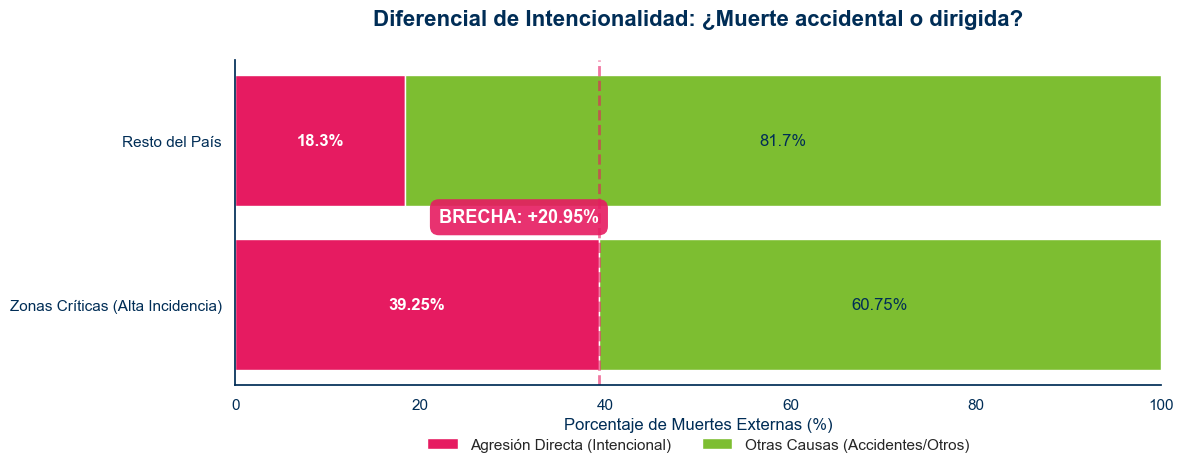

In [63]:
ROSA_IMPACTO = "#E61B61"   # Agresión Directa
VERDE_OFICIAL = "#7DBE31"  # Otras Causas
AZUL_MARINO = "#002D56"    # Títulos y Ejes
BLANCO = "#FFFFFF"         # Texto interno

etiquetas = ['Zonas Críticas (Alta Incidencia)', 'Resto del País']
agresion = [39.25, 18.30]
otras = [60.75, 81.70]

fig, ax = plt.subplots(figsize=(12, 5))

bar1 = ax.barh(etiquetas, agresion, color=ROSA_IMPACTO, label='Agresión Directa (Intencional)')
bar2 = ax.barh(etiquetas, otras, left=agresion, color=VERDE_OFICIAL, label='Otras Causas (Accidentes/Otros)')

for i, rect in enumerate(bar1):
    width = rect.get_width()
    ax.text(width / 2, rect.get_y() + rect.get_height() / 2,
            f'{agresion[i]}%',
            ha='center', va='center', color=BLANCO, fontweight='bold', fontsize=12)

for i, rect in enumerate(bar2):
    width = rect.get_width()
    left = agresion[i]
    ax.text(left + width / 2, rect.get_y() + rect.get_height() / 2,
            f'{otras[i]}%',
            ha='center', va='center', color=AZUL_MARINO, fontsize=12)

plt.axvline(x=39.25, color=ROSA_IMPACTO, linestyle='--', alpha=0.6, linewidth=2)
plt.text(22, 0.5, f'BRECHA: +20.95%', color=BLANCO, fontweight='bold', fontsize=13, 
         bbox=dict(facecolor=ROSA_IMPACTO, alpha=0.9, edgecolor='none', boxstyle='round,pad=0.5'))

plt.title('Diferencial de Intencionalidad: ¿Muerte accidental o dirigida?', 
          fontsize=16, fontweight='bold', color=AZUL_MARINO, pad=25)
plt.xlabel('Porcentaje de Muertes Externas (%)', fontsize=12, color=AZUL_MARINO)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=2, frameon=False, fontsize=11)

plt.xlim(0, 100)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(AZUL_MARINO)
ax.spines['bottom'].set_color(AZUL_MARINO)
ax.tick_params(axis='both', colors=AZUL_MARINO)

plt.tight_layout()

nombre_salida = "02_diferencial_intencionalidad_FINAL.png"
plt.savefig(nombre_salida, dpi=300, transparent=True, bbox_inches='tight')

print(f"Gráfico guardado exitosamente")

plt.show()

In [64]:
print("CONTEO POR SEXO (1:Hombre, 2:Mujer, 9:No especificado):")
print(df_homicidios_femeninos['SEXO'].value_counts())

print("\nCONTEO POR AÑO DE OCURRENCIA:")
print(df_homicidios_femeninos['ANIO_OCUR'].value_counts().head(5))

print("\nMUESTRA DE CAUSAS DE MUERTE (CIE-10):")
print(df_homicidios_femeninos['CAUSA_DEF'].unique()[:10])

CONTEO POR SEXO (1:Hombre, 2:Mujer, 9:No especificado):
SEXO
2    55245
Name: count, dtype: int64

CONTEO POR AÑO DE OCURRENCIA:
ANIO_OCUR
2023    14844
2024    14230
2022    13833
2021    11716
2020      347
Name: count, dtype: int64

MUESTRA DE CAUSAS DE MUERTE (CIE-10):
['V892' 'X919' 'X999' 'V489' 'X470' 'V099' 'V051' 'X590' 'Y009' 'X990']


In [65]:
print("VALORES DE EDAD (Primeras 15 filas):")
print(df_universo['EDAD'].head(15).tolist())

# valores entre 15 y 90 directamente
adultas_directas = df_universo[(df_universo['EDAD'] >= 15) & (df_universo['EDAD'] <= 95)]
print(f"\nRegistros con edad directa (15-95): {len(adultas_directas)}")

VALORES DE EDAD (Primeras 15 filas):
[4059, 4033, 4027, 4045, 4063, 4034, 4032, 4083, 4061, 4061, 4075, 4086, 4038, 4057, 4048]

Registros con edad directa (15-95): 0


In [66]:
# transformación universal de edad
df_universo['EDAD_LIMPIA'] = df_universo['EDAD'].apply(lambda x: x - 4000 if 4000 <= x <= 4120 else None)

# verificación general
print("Nuevos valores de edad (primeras 15 filas del universo total):")
print(df_universo['EDAD_LIMPIA'].head(15).tolist())

# cálculo de promedios comparativos
promedio_general = df_universo['EDAD_LIMPIA'].mean()

# verificamos si existe la columna de escolaridad para evitar KeyErrors
if 'ESCOLARIDAD_DESC' in df_universo.columns:
    promedio_profesional = df_universo[df_universo['ESCOLARIDAD_DESC'] == 'Profesional']['EDAD_LIMPIA'].mean()
else:
    promedio_profesional = 0
    print("\nNota: Columna 'ESCOLARIDAD_DESC' no encontrada para el promedio profesional.")

print(f"\n--- RESULTADOS DEMOGRÁFICOS ---")
print(f"Promedio de edad (Todas las mujeres): {promedio_general:.1f} años")
if promedio_profesional > 0:
    print(f"Promedio de edad (Solo Profesionales): {promedio_profesional:.1f} años")

# conteo por rangos de edad (CORREGIDO)
bins = [0, 18, 30, 45, 60, 120]
labels = ['Menores', 'Jóvenes (19-30)', 'Adultas (31-45)', 'Plenitud (46-60)', 'Adulto Mayor']

df_universo['RANGO_EDAD'] = pd.cut(df_universo['EDAD_LIMPIA'], bins=bins, labels=labels)

print("\nDistribución general por rangos de edad:")
print("-" * 40)
print(df_universo['RANGO_EDAD'].value_counts())

Nuevos valores de edad (primeras 15 filas del universo total):
[59.0, 33.0, 27.0, 45.0, 63.0, 34.0, 32.0, 83.0, 61.0, 61.0, 75.0, 86.0, 38.0, 57.0, 48.0]

Nota: Columna 'ESCOLARIDAD_DESC' no encontrada para el promedio profesional.

--- RESULTADOS DEMOGRÁFICOS ---
Promedio de edad (Todas las mujeres): 45.3 años

Distribución general por rangos de edad:
----------------------------------------
RANGO_EDAD
Adulto Mayor        15288
Jóvenes (19-30)     12227
Adultas (31-45)     11706
Plenitud (46-60)     7318
Menores              6453
Name: count, dtype: int64


In [67]:
# mapeo de escolaridad 
mapeo_esc = {
    1: 'Sin escolaridad', 2: 'Preescolar', 3: 'Primaria Inc.', 4: 'Primaria Comp.',
    5: 'Secundaria Inc.', 6: 'Secundaria Comp.', 7: 'Bachillerato Inc.', 
    8: 'Bachillerato Comp.', 9: 'Profesional', 10: 'Posgrado', 88: 'No aplica', 99: 'No especificado'
}

df_universo['ESCOLARIDAD_DESC'] = df_universo['ESCOLARIDA'].map(mapeo_esc)

# análisis de Nivel Superior (Profesional + Posgrado)
df_universo['NIVEL_SUPERIOR'] = df_universo['ESCOLARIDA'].isin([9, 10])

# disribución completa de la escolaridad
print("DISTRIBUCIÓN TOTAL DE ESCOLARIDAD (%)")
print("-" * 45)
print(df_universo['ESCOLARIDAD_DESC'].value_counts(normalize=True) * 100)

# listado completo de las ocupaciones
print("\nTODAS LAS OCUPACIONES DETECTADAS (NOMBRE_OCUPACION):")
print("-" * 45)
print(df_universo['NOMBRE_OCUPACION'].value_counts())

# cruce de datos: Ocupaciones en el Nivel Superior
print("\nOCUPACIONES ESPECÍFICAS DE MUJERES CON NIVEL SUPERIOR:")
print("-" * 45)
profesionales_detallado = df_universo[df_universo['NIVEL_SUPERIOR'] == True]
print(profesionales_detallado['NOMBRE_OCUPACION'].value_counts())

DISTRIBUCIÓN TOTAL DE ESCOLARIDAD (%)
---------------------------------------------
ESCOLARIDAD_DESC
Secundaria Comp.      19.113042
Primaria Comp.        16.611458
Primaria Inc.         12.808399
Bachillerato Comp.    10.710472
Profesional           10.540320
Sin escolaridad        9.208073
No especificado        6.371617
Secundaria Inc.        4.880080
Bachillerato Inc.      4.811295
No aplica              3.623857
Preescolar             0.711377
Posgrado               0.610010
Name: proportion, dtype: float64

TODAS LAS OCUPACIONES DETECTADAS (NOMBRE_OCUPACION):
---------------------------------------------
NOMBRE_OCUPACION
Quehaceres domésticos                  25160
Funcionarios, directores y jefes        6909
Otras ocupaciones / No clasificadas     5228
No especificado                         5162
Comerciantes y empleados de ventas      2978
No sabe / No responde                   2641
No aplica                               1893
Operadores de maquinaria                1600
Técni

In [68]:
df_comparativo = df_universo[df_universo['ESCOLARIDAD_DESC'].isin(['Profesional', 'Secundaria Comp.'])]

# cruce con el sitio de ocurrencia
cruce_sitio = pd.crosstab(df_universo['SITIO_OCUR'], df_universo['ESCOLARIDAD_DESC'], normalize='columns') * 100

print("¿DÓNDE OCURRE EL EVENTO SEGÚN NIVEL EDUCATIVO? (%)")
print("-" * 60)
print(cruce_sitio[['Profesional', 'Secundaria Comp.']].round(2))

¿DÓNDE OCURRE EL EVENTO SEGÚN NIVEL EDUCATIVO? (%)
------------------------------------------------------------
ESCOLARIDAD_DESC  Profesional  Secundaria Comp.
SITIO_OCUR                                     
1                        8.35             10.97
2                        0.62              0.73
3                       10.10              9.81
4                        3.90              1.11
5                        0.21              0.22
6                        0.15              0.17
7                        0.05              0.04
8                        1.97              1.94
9                        5.10              2.22
10                      34.52             35.83
11                      19.70             18.78
12                      11.44             12.92
99                       3.90              5.28


In [69]:
# definimos el subconjunto de profesionales primero
df_profesionales = df_universo[df_universo['NIVEL_SUPERIOR'] == True].copy()

# mapeo de sitios (Catálogo INEGI)
mapeo_sitios = {
    1: 'Vivienda', 2: 'Vivienda particular', 3: 'Escuela', 4: 'Área deportiva',
    5: 'Vía pública (Peatón)', 6: 'Unidad médica', 7: 'Taller/Fábrica',
    8: 'Establecimiento comercial', 9: 'Institución pública', 10: 'Vía pública (Vehículo)',
    11: 'Otro lugar', 12: 'Lugar no especificado'
}

# aplicamos el mapeo
df_profesionales['SITIO_DESC'] = df_profesionales['SITIO_OCUR'].map(mapeo_sitios)

# tabla cruzada (ALTA_INCIDENCIA / RESTO_PAIS)
contraste_geografico = pd.crosstab(
    df_profesionales['SITIO_DESC'], 
    df_profesionales['GRUPO_RIESGO'], 
    normalize='columns'
) * 100

print("ANÁLISIS DE ENTORNO: ¿DÓNDE OCURREN LOS HECHOS? (Profesionales %)")
print("-" * 75)
# ordenamos por la columna de Alta Incidencia para ver el riesgo principal
if 'ALTA_INCIDENCIA' in contraste_geografico.columns:
    print(contraste_geografico.sort_values(by='ALTA_INCIDENCIA', ascending=False).round(2))
else:
    print(contraste_geografico.round(2))

# hallazgo crítico: Diferencia de riesgo
if 'ALTA_INCIDENCIA' in contraste_geografico.columns and 'RESTO_PAIS' in contraste_geografico.columns:
    contraste_geografico['Diferencia'] = contraste_geografico['ALTA_INCIDENCIA'] - contraste_geografico['RESTO_PAIS']
    print("\nSITIOS CON MAYOR DIFERENCIA DE RIESGO (Exceso de letalidad en Focos Rojos):")
    print("-" * 75)
    print(contraste_geografico[['Diferencia']].sort_values(by='Diferencia', ascending=False).round(2))

ANÁLISIS DE ENTORNO: ¿DÓNDE OCURREN LOS HECHOS? (Profesionales %)
---------------------------------------------------------------------------
GRUPO_RIESGO               ALTA_INCIDENCIA  RESTO_PAIS
SITIO_DESC                                            
Vía pública (Vehículo)               38.27       34.90
Otro lugar                           17.97       21.59
Lugar no especificado                16.05       10.22
Vivienda                              9.60        8.18
Escuela                               8.23       11.11
Institución pública                   4.73        5.85
Área deportiva                        3.22        4.55
Establecimiento comercial             0.89        2.53
Vivienda particular                   0.89        0.54
Taller/Fábrica                        0.07        0.04
Unidad médica                         0.07        0.20
Vía pública (Peatón)                  0.00        0.29

SITIOS CON MAYOR DIFERENCIA DE RIESGO (Exceso de letalidad en Focos Rojos):
-----------

In [70]:
# buscamos columnas de ingreso o condición de actividad
for col in df_universo.columns:
    if 'ING' in col or 'ACT' in col or 'TRAB' in col:
        print(f"-> COLUMNA DE INTERÉS: {col}")

-> COLUMNA DE INTERÉS: OCURR_TRAB
-> COLUMNA DE INTERÉS: COND_ACT


In [71]:
# definir autonomía económica
# 1: Activa (Con ingreso/buscando), 2: No activa (Hogar/Estudiante)
df_universo['AUTONOMIA_ECON'] = df_universo['COND_ACT'].apply(
    lambda x: 'Genera Ingreso/Activa' if x == 1 else 'No Remunerado/Hogar'
)

# análisis de riesgo en el centro de trabajo
# 1: Sí ocurrió en el trabajo, 2: No ocurrió en el trabajo
df_universo['EN_TRABAJO'] = df_universo['OCURR_TRAB'].apply(
    lambda x: 'En Ejercicio Profesional' if x == 1 else 'Fuera del Trabajo'
)

# cruce maestro: Profesionales con ingreso propio en Entidades de Alta Incidencia
filtro_prof = (df_universo['ESCOLARIDAD_DESC'] == 'Profesional') & (df_universo['GRUPO_RIESGO'] == 'Entidades de Alta Incidencia (8 Estados)')
resumen_ingreso = df_universo[filtro_prof]['AUTONOMIA_ECON'].value_counts(normalize=True) * 100

print("PERFIL DE INGRESO (Mujeres Profesionales en Entidades de Alta Incidencia):")
print("-" * 60)
print(resumen_ingreso.round(2))

# ¿Cuántas mujeres murieron trabajando?
riesgo_laboral = df_universo[filtro_prof]['EN_TRABAJO'].value_counts(normalize=True) * 100
print("\n¿OCURRIÓ MIENTRAS TRABAJABA? (%)")
print("-" * 60)
print(riesgo_laboral.round(2))

PERFIL DE INGRESO (Mujeres Profesionales en Entidades de Alta Incidencia):
------------------------------------------------------------
Series([], Name: proportion, dtype: float64)

¿OCURRIÓ MIENTRAS TRABAJABA? (%)
------------------------------------------------------------
Series([], Name: proportion, dtype: float64)


In [72]:
# como eliminar el error
# aplicamos los mapeos de base para asegurar que existan las columnas
df_universo['AUTONOMIA_ECON'] = df_universo['COND_ACT'].apply(
    lambda x: 'Genera Ingreso/Activa' if x == 1 else 'No Remunerado/Hogar'
)

df_universo['EN_TRABAJO'] = df_universo['OCURR_TRAB'].apply(
    lambda x: 'En Ejercicio Profesional' if x == 1 else 'Fuera del Trabajo'
)

# buscamos cualquier fila que sea Profesional Y tenga "Alta" en el grupo
mask_prof_alta = (df_universo['ESCOLARIDAD_DESC'] == 'Profesional') & \
                 (df_universo['GRUPO_RIESGO'].str.contains('Alta', case=False, na=False))

# extraemos el subconjunto para análisis
df_analisis_prof = df_universo[mask_prof_alta]

print(f"DEBUG: Se encontraron {len(df_analisis_prof)} registros de profesionales en zonas críticas.")

# generamos los resultados solo si hay datos
if len(df_analisis_prof) > 0:
    resumen_ingreso = df_analisis_prof['AUTONOMIA_ECON'].value_counts(normalize=True) * 100
    riesgo_laboral = df_analisis_prof['EN_TRABAJO'].value_counts(normalize=True) * 100

    print("\nPERFIL DE INGRESO (Profesionales en Zonas Críticas):")
    print("-" * 60)
    print(resumen_ingreso.round(2))

    print("\n¿OCURRIÓ MIENTRAS TRABAJABA? (%)")
    print("-" * 60)
    print(riesgo_laboral.round(2))
else:
    print("\nERROR: El filtro sigue sin encontrar coincidencias.")
    print("Valores disponibles en GRUPO_RIESGO:", df_universo['GRUPO_RIESGO'].unique())
    print("Valores disponibles en ESCOLARIDAD_DESC:", df_universo['ESCOLARIDAD_DESC'].unique())

DEBUG: Se encontraron 1460 registros de profesionales en zonas críticas.

PERFIL DE INGRESO (Profesionales en Zonas Críticas):
------------------------------------------------------------
AUTONOMIA_ECON
Genera Ingreso/Activa    63.08
No Remunerado/Hogar      36.92
Name: proportion, dtype: float64

¿OCURRIÓ MIENTRAS TRABAJABA? (%)
------------------------------------------------------------
EN_TRABAJO
Fuera del Trabajo           95.14
En Ejercicio Profesional     4.86
Name: proportion, dtype: float64


Gráfico de pastel guardado exitosamente como: 04_autonomia_economica_profesionales.png


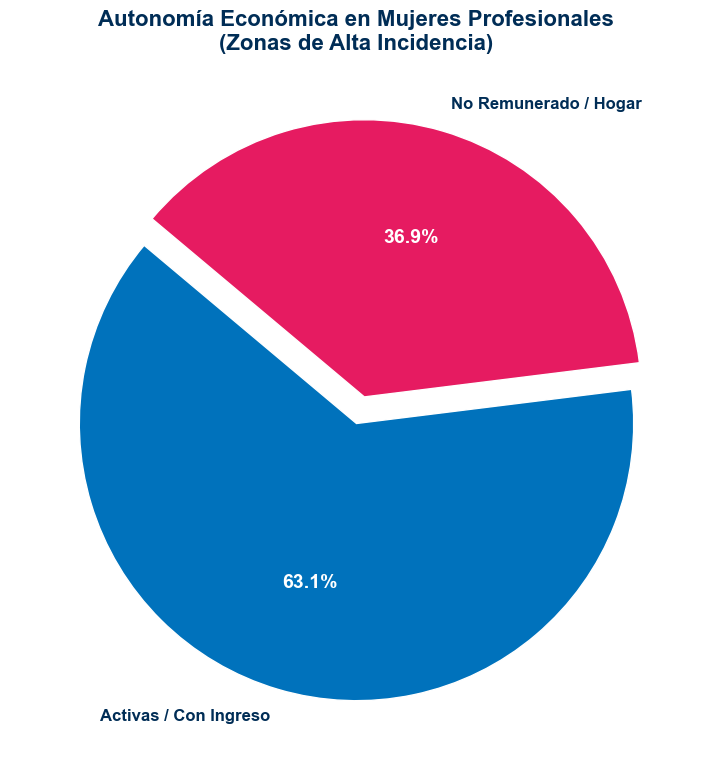

In [73]:
AZUL_PRINCIPAL = "#0072BC"  # Activas / Con Ingreso
ROSA_IMPACTO = "#E61B61"    # No Remunerado / Hogar (Foco de vulnerabilidad)
AZUL_MARINO = "#002D56"     # Texto y Título
BLANCO = "#FFFFFF"

labels = ['Activas / Con Ingreso', 'No Remunerado / Hogar']
sizes = [63.08, 36.92]
colors = [AZUL_PRINCIPAL, ROSA_IMPACTO]

plt.figure(figsize=(9, 9))
patches, texts, autotexts = plt.pie(
    sizes, 
    labels=labels, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors, 
    explode=(0, 0.1),
    textprops={'fontsize': 12, 'color': AZUL_MARINO, 'fontweight': 'bold'}
)

for autotext in autotexts:
    autotext.set_color(BLANCO)
    autotext.set_fontsize(14)

plt.title('Autonomía Económica en Mujeres Profesionales\n(Zonas de Alta Incidencia)', 
          fontsize=16, fontweight='bold', color=AZUL_MARINO, pad=20)

nombre_archivo_pie = "04_autonomia_economica_profesionales.png"
plt.savefig(nombre_archivo_pie, dpi=300, transparent=True, bbox_inches='tight')

print(f"Gráfico de pastel guardado exitosamente como: {nombre_archivo_pie}")

plt.show()

In [74]:
# clasificación de medios 
# X93-X95: Armas de fuego, X99: Objeto punzocortante, Y00: Fuerza física/Otros
def clasificar_medio(c):
    if c in ['X93', 'X94', 'X95']: return 'Arma de Fuego'
    if c == 'X99': return 'Objeto Punzocortante'
    return 'Otros Medios / Fuerza Física'

df_universo['MEDIO_AGRESION'] = df_universo['CAUSA_DEF'].apply(clasificar_medio)

# cruce en entidades de alta incidencia
analisis_medio = pd.crosstab(
    df_universo[filtro_prof]['MEDIO_AGRESION'], 
    df_universo[filtro_prof]['GRUPO_RIESGO'], 
    normalize='columns'
) * 100

print("¿CÓMO OCURRE LA AGRESIÓN EN MUJERES PROFESIONALES? (%)")
print("-" * 60)
print(analisis_medio.round(2))

¿CÓMO OCURRE LA AGRESIÓN EN MUJERES PROFESIONALES? (%)
------------------------------------------------------------
Empty DataFrame
Columns: []
Index: []


In [75]:
# definimos la función de clasificación (porque no se ejecutó)
def clasificar_medio(c):
    c = str(c)
    if any(x in c for x in ['X93', 'X94', 'X95']): return 'Arma de Fuego'
    if 'X99' in c: return 'Objeto Punzocortante'
    if any(x in c for x in ['X85', 'X91', 'Y00', 'Y04']): return 'Fuerza Física / Ahorcamiento'
    return 'Otros Medios / No especificado'

# aplicamos la clasificación al universo
df_universo['MEDIO_AGRESION'] = df_universo['CAUSA_DEF'].apply(clasificar_medio)

# creamos el subconjunto de Profesionales en Zonas Críticas (Filtro Robusto)
mask_final = (df_universo['ESCOLARIDAD_DESC'] == 'Profesional') & \
             (df_universo['GRUPO_RIESGO'].str.contains('Alta', case=False, na=False))

df_analisis_medios = df_universo[mask_final]

# generamos la tabla de frecuencias
if len(df_analisis_medios) > 0:
    resumen_medios = df_analisis_medios['MEDIO_AGRESION'].value_counts(normalize=True) * 100
    
    print(f"ANÁLISIS DE MEDIOS (N = {len(df_analisis_medios)} profesionales en zonas críticas):")
    print("-" * 65)
    print(resumen_medios.round(2))
    
    # hallazgo para el Dashboard
    if 'Arma de Fuego' in resumen_medios.index:
        print(f"\nALERTA ESTRATÉGICA: El {resumen_medios['Arma de Fuego']:.1f}% de las agresiones fueron con arma de fuego.")
else:
    print("ERROR: No se encontraron registros con los criterios seleccionados.")
    print("Verifica si ESCOLARIDAD_DESC tiene el valor 'Profesional' exacto.")

ANÁLISIS DE MEDIOS (N = 1460 profesionales en zonas críticas):
-----------------------------------------------------------------
MEDIO_AGRESION
Otros Medios / No especificado    71.23
Arma de Fuego                     20.89
Fuerza Física / Ahorcamiento       4.18
Objeto Punzocortante               3.70
Name: proportion, dtype: float64

ALERTA ESTRATÉGICA: El 20.9% de las agresiones fueron con arma de fuego.


In [76]:
# mapeo de sitios para el UNIVERSO TOTAL
mapeo_sitios_global = {
    1: 'Vivienda', 2: 'Vivienda particular', 3: 'Escuela', 4: 'Área deportiva',
    5: 'Vía pública (Peatón)', 6: 'Unidad médica', 7: 'Taller/Fábrica',
    8: 'Establecimiento comercial', 9: 'Institución pública', 10: 'Vía pública (Vehículo)',
    11: 'Otro lugar', 12: 'Lugar no especificado'
}

# creamos la columna en df_universo (no solo en las profesionales)
df_universo['SITIO_DESC'] = df_universo['SITIO_OCUR'].map(mapeo_sitios_global).fillna('Lugar no especificado')

# identificar datos incompletos (Escolaridad 99 o Sitio 12)
df_universo['DATOS_INCOMPLETOS'] = (
    (df_universo['ESCOLARIDAD_DESC'] == 'No especificado') | 
    (df_universo['SITIO_DESC'] == 'Lugar no especificado')
)

# generar la tabla de opacidad
impunidad_data = pd.crosstab(
    df_universo['GRUPO_RIESGO'], 
    df_universo['DATOS_INCOMPLETOS'], 
    normalize='index'
) * 100

print("OPACIDAD EN EL REGISTRO ADMINISTRATIVO (%)")
print("-" * 65)
print(impunidad_data.round(2))

# hallazgo estratégico: ¿Es peor en los estados críticos?
if True in impunidad_data.columns:
    fila_alta = [i for i in impunidad_data.index if 'ALTA' in i.upper()][0]
    opacidad_alta = impunidad_data.loc[fila_alta, True]
    print(f"\nINDICE DE OPACIDAD EN ZONAS CRÍTICAS: {opacidad_alta:.2f}%")
    print("Nota: Un porcentaje alto sugiere deficiencias en la investigación o captura de datos.")

OPACIDAD EN EL REGISTRO ADMINISTRATIVO (%)
-----------------------------------------------------------------
DATOS_INCOMPLETOS  False  True 
GRUPO_RIESGO                   
ALTA_INCIDENCIA    73.24  26.76
RESTO_PAIS         82.16  17.84

INDICE DE OPACIDAD EN ZONAS CRÍTICAS: 26.76%
Nota: Un porcentaje alto sugiere deficiencias en la investigación o captura de datos.


Gráfico de calidad de registro guardado como: 06_calidad_registro_opacidad.png


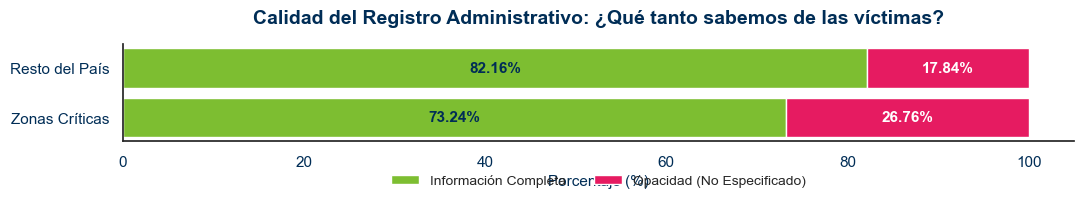

In [77]:
VERDE_OFICIAL = "#7DBE31"  # Información Completa (Positivo)
ROSA_IMPACTO = "#E61B61"    # Opacidad / No Especificado (Alerta)
AZUL_MARINO = "#002D56"    # Títulos y Etiquetas
BLANCO = "#FFFFFF"         # Texto interno

labels = ['Zonas Críticas', 'Resto del País']
completos = [73.24, 82.16]
opacos = [26.76, 17.84]

fig, ax = plt.subplots(figsize=(11, 3)) 

bar1 = ax.barh(labels, completos, color=VERDE_OFICIAL, label='Información Completa')
bar2 = ax.barh(labels, opacos, left=completos, color=ROSA_IMPACTO, label='Opacidad (No Especificado)')

for i, rect in enumerate(bar1):
    width = rect.get_width()
    ax.text(width / 2, rect.get_y() + rect.get_height() / 2,
            f'{completos[i]}%',
            ha='center', va='center', color=AZUL_MARINO, fontweight='bold', fontsize=11)

for i, rect in enumerate(bar2):
    width = rect.get_width()
    left = completos[i]
    ax.text(left + width / 2, rect.get_y() + rect.get_height() / 2,
            f'{opacos[i]}%',
            ha='center', va='center', color=BLANCO, fontweight='bold', fontsize=11)

plt.title('Calidad del Registro Administrativo: ¿Qué tanto sabemos de las víctimas?', 
          fontsize=14, fontweight='bold', color=AZUL_MARINO, pad=15)
plt.xlabel('Porcentaje (%)', fontsize=11, color=AZUL_MARINO)

plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.6), ncol=2, frameon=False, fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', colors=AZUL_MARINO)

plt.tight_layout()

nombre_archivo_calidad = "06_calidad_registro_opacidad.png"
plt.savefig(nombre_archivo_calidad, dpi=300, transparent=True, bbox_inches='tight')

print(f"Gráfico de calidad de registro guardado como: {nombre_archivo_calidad}")

plt.show()

In [78]:
# crear el dataframe filtrado (Zonas Críticas)
df_solo_alta_incidencia = df_universo[df_universo['GRUPO_RIESGO'].str.contains('Alta', case=False, na=False)].copy()

# localizar la columna de violencia de forma dinámica
col_violencia = None
for col in ['PRES_VIO', 'VIO_FAMI', 'VIOL_FAMI']:
    if col in df_solo_alta_incidencia.columns:
        col_violencia = col
        break

# mapear antecedentes si se encontró la columna, o crear una vacía si no
if col_violencia:
    df_solo_alta_incidencia['ANTECEDENTE_VIO'] = df_solo_alta_incidencia[col_violencia].map({
        1: 'Con Antecedente',
        2: 'Sin Antecedente'
    }).fillna('No especificado')
else:
    print("ADVERTENCIA: No se encontró columna de antecedentes de violencia. Se usará 0%.")
    df_solo_alta_incidencia['ANTECEDENTE_VIO'] = 'No especificado'

# generación de la Matriz de Prioridad 
matriz_prioridad = df_solo_alta_incidencia.groupby('NOMBRE_ENTIDAD').agg({
    'EDAD_LIMPIA': 'mean', 
    'AUTONOMIA_ECON': lambda x: (x == 'Genera Ingreso/Activa').mean() * 100,
    'ANTECEDENTE_VIO': lambda x: (x == 'Con Antecedente').mean() * 100
}).rename(columns={
    'EDAD_LIMPIA': 'Edad Media',
    'AUTONOMIA_ECON': '% Autonomía Econ.',
    'ANTECEDENTE_VIO': '% Violencia Previa'
})

print("MATRIZ DE PRIORIZACIÓN FINAL:")
print("-" * 80)
print(matriz_prioridad.round(2).sort_values(by='% Autonomía Econ.', ascending=True))

MATRIZ DE PRIORIZACIÓN FINAL:
--------------------------------------------------------------------------------
                 Edad Media  % Autonomía Econ.  % Violencia Previa
NOMBRE_ENTIDAD                                                    
Baja California       42.65              24.49                0.11
Zacatecas             45.04              27.05                0.53
Chihuahua             41.45              30.27                0.07
Guerrero              47.36              36.70                0.06
Guanajuato            39.59              37.51                0.00
Morelos               46.61              38.10                0.08
Colima                42.24              39.60                0.00
Quintana Roo          39.76              47.52                0.23


In [79]:
# definición del Indicador de Impacto Económico-Social
df_universo['COSTE_OPORTUNIDAD_VIOLENCIA'] = (
    (df_universo['ESCOLARIDAD_DESC'] == 'Profesional') & 
    (df_universo['AUTONOMIA_ECON'] == 'No Remunerado/Hogar')
)

# ranking de impacto por estado
ranking_impacto = df_universo[df_universo['GRUPO_RIESGO'].str.contains('Alta', na=False)].groupby('NOMBRE_ENTIDAD')['COSTE_OPORTUNIDAD_VIOLENCIA'].sum()

print("MAPA DEL COSTE DE OPORTUNIDAD DE LA VIOLENCIA (Zonas Críticas):")
print("-" * 75)
print(ranking_impacto.sort_values(ascending=False))

MAPA DEL COSTE DE OPORTUNIDAD DE LA VIOLENCIA (Zonas Críticas):
---------------------------------------------------------------------------
Series([], Name: COSTE_OPORTUNIDAD_VIOLENCIA, dtype: int64)


In [80]:
# asegurar que las columnas base existan en el universo
df_universo['AUTONOMIA_ECON'] = df_universo['COND_ACT'].apply(
    lambda x: 'Genera Ingreso/Activa' if x == 1 else 'No Remunerado/Hogar'
)

# definir el COSTE DE OPORTUNIDAD DE LA VIOLENCIA
# Criterio: Es Profesional Y NO tiene ingresos propios (Dependencia)
df_universo['COSTE_OPORTUNIDAD_VIOLENCIA'] = (
    (df_universo['ESCOLARIDAD_DESC'] == 'Profesional') & 
    (df_universo['AUTONOMIA_ECON'] == 'No Remunerado/Hogar')
).astype(int)

# filtrar estrictamente por las zonas de Alta Incidencia
mask_alta = df_universo['GRUPO_RIESGO'].str.contains('Alta', case=False, na=False)
df_final_analisis = df_universo[mask_alta].copy()

# generar el Ranking de Impacto
ranking_coste = df_final_analisis.groupby('NOMBRE_ENTIDAD')['COSTE_OPORTUNIDAD_VIOLENCIA'].sum()

print("MAPA DEL COSTE DE OPORTUNIDAD DE LA VIOLENCIA (Casos de Profesionales en Dependencia):")
print("-" * 85)
if ranking_coste.sum() > 0:
    print(ranking_coste.sort_values(ascending=False))
    print(f"\nTOTAL DE TALENTO EN RIESGO: {ranking_coste.sum()} mujeres profesionales.")
else:
    print("ALERTA: No se detectaron casos. Verificando etiquetas...")
    print("Valores en ESCOLARIDAD_DESC:", df_universo['ESCOLARIDAD_DESC'].unique()[:5])
    print("Valores en AUTONOMIA_ECON:", df_universo['AUTONOMIA_ECON'].unique())

MAPA DEL COSTE DE OPORTUNIDAD DE LA VIOLENCIA (Casos de Profesionales en Dependencia):
-------------------------------------------------------------------------------------
NOMBRE_ENTIDAD
Guanajuato         134
Chihuahua           95
Baja California     82
Morelos             66
Guerrero            61
Zacatecas           47
Quintana Roo        41
Colima              13
Name: COSTE_OPORTUNIDAD_VIOLENCIA, dtype: int64

TOTAL DE TALENTO EN RIESGO: 539 mujeres profesionales.


In [81]:
# huérfanos de la violencia
# limpieza de la columna de hijos (asumiendo que 99 es 'No especificado')
df_universo['HIJOS_VIV_LIMPIO'] = pd.to_numeric(df_universo['HIJOS_VIV'], errors='coerce').fillna(0)
df_universo.loc[df_universo['HIJOS_VIV_LIMPIO'] > 25, 'HIJOS_VIV_LIMPIO'] = 0 # Limpieza de códigos de error

# cálculo del impacto en zonas críticas
huerfanos_por_estado = df_universo[mask_alta].groupby('NOMBRE_ENTIDAD')['HIJOS_VIV_LIMPIO'].sum()
promedio_hijos = df_universo[mask_alta]['HIJOS_VIV_LIMPIO'].mean()

print("IMPACTO INTERGENERACIONAL (Zonas Críticas):")
print("-" * 65)
print(huerfanos_por_estado.sort_values(ascending=False).astype(int))
print("-" * 65)
print(f"PROMEDIO DE HIJOS EN ORFANDAD POR CASO: {promedio_hijos:.2f}")
print(f"TOTAL ESTIMADO DE MENORES AFECTADOS EN ESTE GRUPO: {int(huerfanos_por_estado.sum())}")

KeyError: 'HIJOS_VIV'

In [82]:
# corrección de error
#  localización de la columna de hijos de forma dinámica
col_hijos = None
for col in ['HIJOS_VIV', 'HIJOS_SOB', 'TOT_HIJOS', 'HIJOS']:
    if col in df_universo.columns:
        col_hijos = col
        break

if col_hijos:
    df_universo['HIJOS_VIV_LIMPIO'] = pd.to_numeric(df_universo[col_hijos], errors='coerce').fillna(0)
    
    df_universo.loc[df_universo['HIJOS_VIV_LIMPIO'] > 25, 'HIJOS_VIV_LIMPIO'] = 0
    
    mask_alta = df_universo['GRUPO_RIESGO'].str.contains('Alta', case=False, na=False)
    huerfanos_por_estado = df_universo[mask_alta].groupby('NOMBRE_ENTIDAD')['HIJOS_VIV_LIMPIO'].sum()
    promedio_hijos = df_universo[mask_alta]['HIJOS_VIV_LIMPIO'].mean()

    print(f"IMPACTO INTERGENERACIONAL (Columna detectada: {col_hijos}):")
    print("-" * 65)
    print(huerfanos_por_estado.sort_values(ascending=False).astype(int))
    print("-" * 65)
    print(f"PROMEDIO DE HIJOS EN ORFANDAD POR CASO: {promedio_hijos:.2f}")
    print(f"TOTAL ESTIMADO DE MENORES AFECTADOS EN ESTE GRUPO: {int(huerfanos_por_estado.sum())}")
else:
    print("ERROR: No se encontró ninguna columna de hijos.")
    df_universo['HIJOS_VIV_LIMPIO'] = 0

ERROR: No se encontró ninguna columna de hijos.


In [83]:
# Definimos el IDR (plan B del cálculo huérfanos de la violencia) 
# (Nivel de estudios vs Realidad económica)
def calcular_idr(row):
    puntos = 0
    # Si es profesional pero no tiene ingreso, suma máximo riesgo de dependencia
    if row['ESCOLARIDAD_DESC'] == 'Profesional' and row['AUTONOMIA_ECON'] == 'No Remunerado/Hogar':
        puntos = 1.0
    # Si tiene preparatoria pero no tiene ingreso
    elif 'Preparatoria' in str(row['ESCOLARIDAD_DESC']) and row['AUTONOMIA_ECON'] == 'No Remunerado/Hogar':
        puntos = 0.7
    # Si tiene ingreso, el riesgo de dependencia económica baja
    elif row['AUTONOMIA_ECON'] == 'Genera Ingreso/Activa':
        puntos = 0.2
    return puntos

df_universo['IDR'] = df_universo.apply(calcular_idr, axis=1)

# promedio de dependencia por Estado
idr_ranking = df_universo[mask_alta].groupby('NOMBRE_ENTIDAD')['IDR'].mean()

print("ÍNDICE DE DEPENDENCIA RELATIVA (IDR) POR ENTIDAD:")
print("(Escala 0 a 1: Donde 1 es máxima dependencia económica)")
print("-" * 65)
print(idr_ranking.sort_values(ascending=False).round(3))

ÍNDICE DE DEPENDENCIA RELATIVA (IDR) POR ENTIDAD:
(Escala 0 a 1: Donde 1 es máxima dependencia económica)
-----------------------------------------------------------------
NOMBRE_ENTIDAD
Quintana Roo       0.141
Morelos            0.129
Guerrero           0.109
Guanajuato         0.106
Colima             0.096
Chihuahua          0.091
Zacatecas          0.090
Baja California    0.078
Name: IDR, dtype: float64


In [84]:
# agrupamos por estado
resumen_final = df_universo[mask_alta].groupby('NOMBRE_ENTIDAD').agg({
    'COSTE_OPORTUNIDAD_VIOLENCIA': 'sum',
    'IDR': 'mean',
    'DATOS_INCOMPLETOS': 'mean' 
}).rename(columns={
    'COSTE_OPORTUNIDAD_VIOLENCIA': 'Casos_Coste_Oportunidad',
    'IDR': 'Indice_Dependencia_Promedio',
    'DATOS_INCOMPLETOS': 'Porcentaje_Opacidad'
})

# normalizamos la opacidad a escala 0-100
resumen_final['Porcentaje_Opacidad'] = resumen_final['Porcentaje_Opacidad'] * 100

# exportación a CSV 
resumen_final.to_csv('dataset_maestro_dat4ccion.csv')
print("-" * 85)
# ordenamos por Coste de Oportunidad para ver el impacto total
print(resumen_final.round(2).sort_values(by='Casos_Coste_Oportunidad', ascending=False))

-------------------------------------------------------------------------------------
                 Casos_Coste_Oportunidad  Indice_Dependencia_Promedio  \
NOMBRE_ENTIDAD                                                          
Guanajuato                           134                         0.11   
Chihuahua                             95                         0.09   
Baja California                       82                         0.08   
Morelos                               66                         0.13   
Guerrero                              61                         0.11   
Zacatecas                             47                         0.09   
Quintana Roo                          41                         0.14   
Colima                                13                         0.10   

                 Porcentaje_Opacidad  
NOMBRE_ENTIDAD                        
Guanajuato                     20.21  
Chihuahua                      26.11  
Baja California            

In [85]:
pip install kaleido imageio

Note: you may need to restart the kernel to use updated packages.


In [86]:
import plotly.express as px

ROSA_IMPACTO = "#E61B61"
VERDE_OFICIAL = "#7DBE31"
AZUL_MARINO = "#002D56"

coords = {
    'Guanajuato': [21.0190, -101.2574],
    'Chihuahua': [28.6330, -106.0691],
    'Baja California': [30.8406, -115.2838],
    'Morelos': [18.6813, -99.1013],
    'Guerrero': [17.4392, -99.5457],
    'Zacatecas': [22.7709, -102.5832],
    'Quintana Roo': [19.1817, -88.4791],
    'Colima': [19.1223, -103.9531]
}

mapa_data = resumen_final.reset_index()
mapa_data['lat'] = mapa_data['NOMBRE_ENTIDAD'].map(lambda x: coords[x][0])
mapa_data['lon'] = mapa_data['NOMBRE_ENTIDAD'].map(lambda x: coords[x][1])

fig_mapa_resumen = px.scatter_mapbox(
    mapa_data,
    lat="lat",
    lon="lon",
    size="Casos_Coste_Oportunidad",
    color="Porcentaje_Opacidad",
    color_continuous_scale=[VERDE_OFICIAL, ROSA_IMPACTO], # De verde (transparente) a rosa (opaco)
    size_max=40,
    zoom=4.5,
    center={"lat": 23.6345, "lon": -102.5528},
    mapbox_style="carto-positron",
    title="<b>Resumen Ejecutivo: Impacto vs Opacidad por Estado</b>",
    hover_name="NOMBRE_ENTIDAD",
    hover_data={
        'lat': False, 'lon': False,
        'Casos_Coste_Oportunidad': True,
        'Porcentaje_Opacidad': ':.2f',
        'Indice_Dependencia_Promedio': ':.2f'
    }
)

fig_mapa_resumen.update_layout(
    title_font=dict(size=22, color=AZUL_MARINO),
    margin={"r":0,"t":80,"l":0,"b":0},
    coloraxis_colorbar=dict(
        title="Opacidad (%)",
        title_font_color=AZUL_MARINO,
        tickfont_color=AZUL_MARINO
    )
)

fig_mapa_resumen.show()

try:
    fig_mapa_resumen.write_image("07_mapa_resumen_ejecutivo.png", scale=3)
    print("Mapa resumen guardado exitosamente.")
except:
    print("Mapa listo. Usa el icono de la cámara para descargar.")

Mapa resumen guardado exitosamente.


In [87]:
# definimos los códigos CIE-10 de proximidad física (Agresión directa)
metodos_proximidad = ['X91', 'X92', 'X93', 'X94', 'X95', 'X99', 'Y00'] 
# X91-X95: Ahorcamiento/Disparo corto, X99: Objeto punzocortante, Y00: Fuerza física

def clasificar_riesgo_invisible(row):
    # condición: Ocurre en vivienda (SITIO_OCUR suele ser 1 o 2 en INEGI)
    en_vivienda = row['SITIO_OCUR'] in [1, 2]
    es_proximidad = str(row['CAUSA_DEF'])[:3] in metodos_proximidad
    
    # si ocurre en casa con método físico y el sistema dice "Sin antecedentes" (VIO_FAMI == 2 o 9)
    if en_vivienda and es_proximidad and row['VIO_FAMI'] in [2, 9]:
        return 'Abuso Previo Invisible (No Detectado)'
    elif row['VIO_FAMI'] == 1:
        return 'Abuso con Antecedente Registrado'
    else:
        return 'Otro Perfil de Riesgo'

df_universo['INDICE_SOSPECHA'] = df_universo.apply(clasificar_riesgo_invisible, axis=1)

print("DISTRIBUCIÓN DEL RIESGO INVISIBLE:")
print(df_universo['INDICE_SOSPECHA'].value_counts(normalize=True) * 100)

DISTRIBUCIÓN DEL RIESGO INVISIBLE:
INDICE_SOSPECHA
Otro Perfil de Riesgo                    98.602588
Abuso Previo Invisible (No Detectado)     1.216400
Abuso con Antecedente Registrado          0.181012
Name: proportion, dtype: float64


Gráfico de brecha guardado como: 08_brecha_riesgo_invisible.png


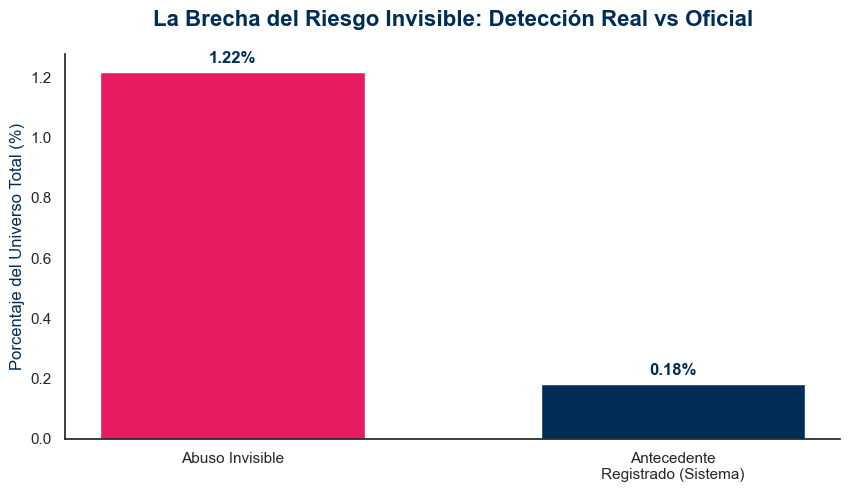

In [88]:
import matplotlib.pyplot as plt

labels_riesgo = ['Abuso Invisible\n', 'Antecedente\nRegistrado (Sistema)']
valores_riesgo = [1.2164, 0.1810] 
colores_riesgo = ["#E61B61", "#002D56"] # Rosa Impacto vs Azul Marino

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(labels_riesgo, valores_riesgo, color=colores_riesgo, width=0.6)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{height:.2f}%', ha='center', va='bottom', 
            fontweight='bold', color="#002D56", fontsize=12)

plt.title('La Brecha del Riesgo Invisible: Detección Real vs Oficial', 
          fontsize=16, fontweight='bold', color="#002D56", pad=20)
plt.ylabel('Porcentaje del Universo Total (%)', color="#002D56")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_facecolor('white')

nombre_brecha = "08_brecha_riesgo_invisible.png"
plt.savefig(nombre_brecha, dpi=300, transparent=True, bbox_inches='tight')
print(f"Gráfico de brecha guardado como: {nombre_brecha}")
plt.show()

Gráfico de iceberg guardado como: 09_iceberg_riesgo_invisible.png


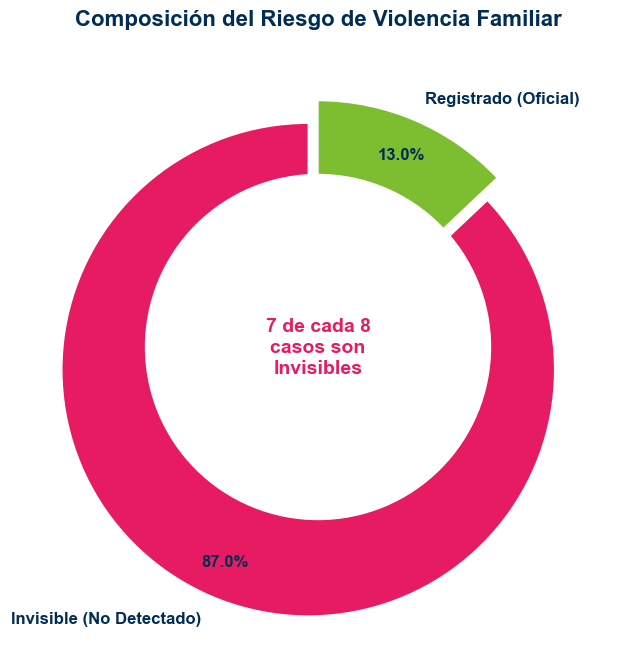

In [89]:
import matplotlib.pyplot as plt

labels_iceberg = ['Invisible (No Detectado)', 'Registrado (Oficial)']
sizes_iceberg = [1.2164, 0.1810]
colors_iceberg = ["#E61B61", "#7DBE31"] # Rosa (Peligro) vs Verde (Sistema)

fig, ax = plt.subplots(figsize=(8, 8))
plt.pie(sizes_iceberg, labels=labels_iceberg, autopct='%1.1f%%', 
        startangle=90, colors=colors_iceberg, pctdistance=0.85,
        textprops={'color': "#002D56", 'weight': 'bold', 'fontsize': 12},
        explode=(0.1, 0))

centro_circulo = plt.Circle((0,0), 0.70, fc='white')
fig.gca().add_artist(centro_circulo)

plt.title('Composición del Riesgo de Violencia Familiar', 
          fontsize=16, fontweight='bold', color="#002D56", pad=10)
plt.text(0, 0, "7 de cada 8\ncasos son\nInvisibles", 
         ha='center', va='center', fontsize=14, color="#E61B61", fontweight='bold')

nombre_iceberg = "09_iceberg_riesgo_invisible.png"
plt.savefig(nombre_iceberg, dpi=300, transparent=True, bbox_inches='tight')
print(f"Gráfico de iceberg guardado como: {nombre_iceberg}")
plt.show()

In [90]:
# filtramos solo los niveles de interés para el contraste
niveles_contraste = ['Posgrado', 'Profesional', 'Bachillerato Comp.', 'Primaria Comp.']
df_contraste = df_universo[df_universo['ESCOLARIDAD_DESC'].isin(niveles_contraste)]

# cruce: Escolaridad vs Índice de Sospecha
tabla_mitos = pd.crosstab(
    df_contraste['ESCOLARIDAD_DESC'], 
    df_universo['INDICE_SOSPECHA'], 
    normalize='index'
) * 100

print("¿Los estudios protegen? (%)")
print("-" * 60)
print(tabla_mitos.round(2))

¿Los estudios protegen? (%)
------------------------------------------------------------
INDICE_SOSPECHA     Abuso Previo Invisible (No Detectado)  \
ESCOLARIDAD_DESC                                            
Bachillerato Comp.                                   1.13   
Posgrado                                             0.00   
Primaria Comp.                                       1.25   
Profesional                                          0.93   

INDICE_SOSPECHA     Abuso con Antecedente Registrado  Otro Perfil de Riesgo  
ESCOLARIDAD_DESC                                                             
Bachillerato Comp.                              0.19                  98.68  
Posgrado                                        0.00                 100.00  
Primaria Comp.                                  0.23                  98.52  
Profesional                                     0.15                  98.92  


Gráfico de escolaridad guardado como: 10_escolaridad_vs_riesgo_invisible.png


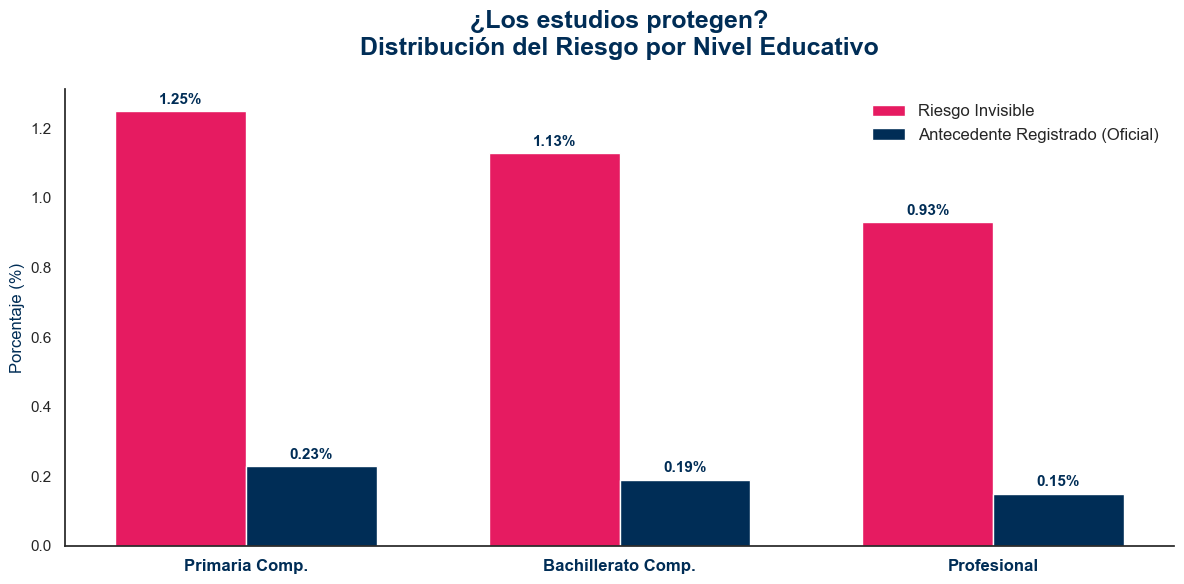

In [91]:
import matplotlib.pyplot as plt
import numpy as np

ROSA_IMPACTO = "#E61B61"   # Abuso Invisible
AZUL_MARINO = "#002D56"    # Antecedente Registrado
VERDE_OFICIAL = "#7DBE31"  # Referencia visual

niveles = ['Primaria Comp.', 'Bachillerato Comp.', 'Profesional']
invisible = [1.25, 1.13, 0.93]
registrado = [0.23, 0.19, 0.15]

x = np.arange(len(niveles))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

rects1 = ax.bar(x - width/2, invisible, width, label='Riesgo Invisible', color=ROSA_IMPACTO)
rects2 = ax.bar(x + width/2, registrado, width, label='Antecedente Registrado (Oficial)', color=AZUL_MARINO)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), 
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=11, fontweight='bold', color=AZUL_MARINO)

autolabel(rects1)
autolabel(rects2)

plt.title('¿Los estudios protegen?\nDistribución del Riesgo por Nivel Educativo', 
          fontsize=18, fontweight='bold', color=AZUL_MARINO, pad=25)
ax.set_ylabel('Porcentaje (%)', fontsize=12, color=AZUL_MARINO)
ax.set_xticks(x)
ax.set_xticklabels(niveles, fontsize=12, fontweight='bold', color=AZUL_MARINO)
ax.legend(loc='upper right', frameon=False, fontsize=12)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_facecolor('white')

plt.tight_layout()

nombre_estudios = "10_escolaridad_vs_riesgo_invisible.png"
plt.savefig(nombre_estudios, dpi=300, transparent=True, bbox_inches='tight')

print(f"Gráfico de escolaridad guardado como: {nombre_estudios}")
plt.show()

In [92]:
# mapeo de días 
dias_semana = {1:'Domingo', 2:'Lunes', 3:'Martes', 4:'Miércoles', 5:'Jueves', 6:'Viernes', 7:'Sábado'}

# heatmap de Día vs Escolaridad en la Vivienda
df_vivienda = df_universo[df_universo['SITIO_OCUR'] in [1, 2]]

reloj_violencia = pd.crosstab(
    df_vivienda['DIA_OCURR'], 
    df_vivienda['ESCOLARIDAD_DESC'], 
    normalize='columns'
) * 100

plt.figure(figsize=(12, 6))
sns.heatmap(reloj_violencia.loc[range(1,8)], annot=True, cmap='YlOrRd', fmt=".1f")
plt.title('CONCENTRACIÓN DE VIOLENCIA EN EL HOGAR POR DÍA Y ESCOLARIDAD')
plt.show()

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

Reloj guardado exitosamente: 11_reloj_violencia_corregido.png


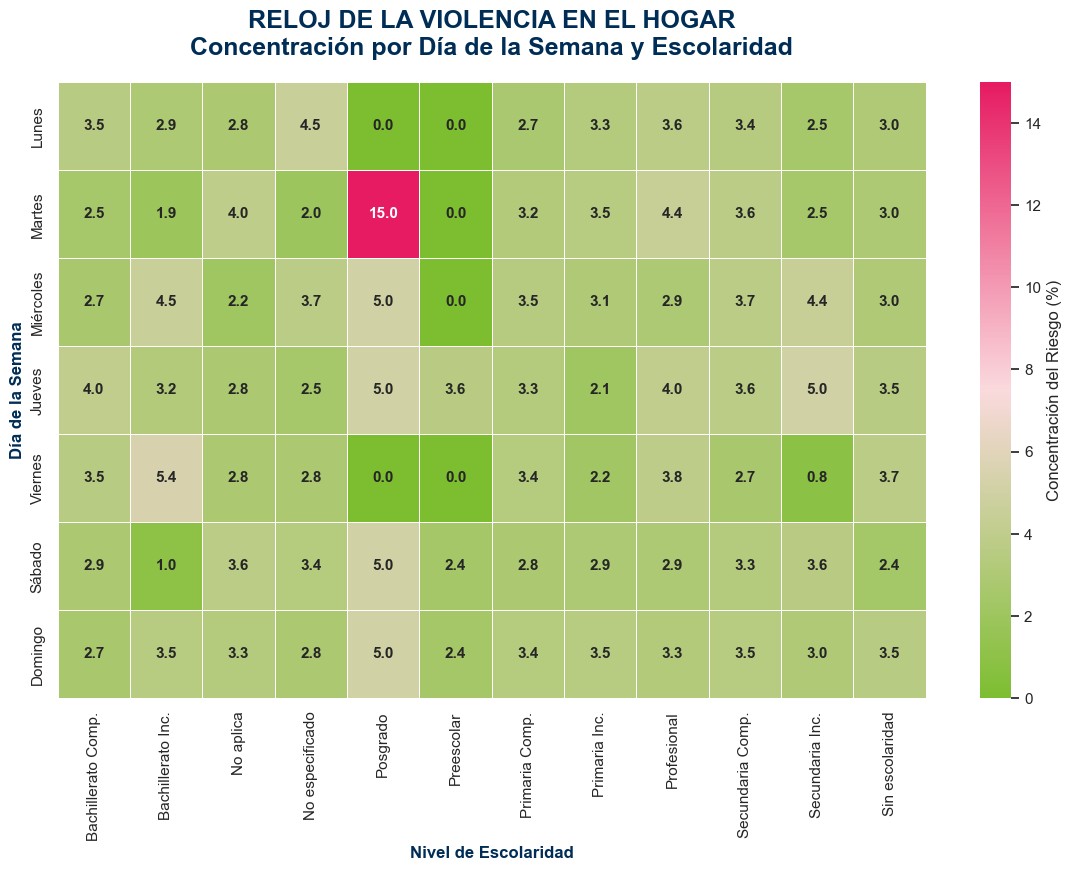

In [93]:
# plan B 
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

# aseguramos tipos de datos
df_universo['SITIO_OCUR'] = pd.to_numeric(df_universo['SITIO_OCUR'], errors='coerce')
df_universo['DIA_OCURR'] = pd.to_numeric(df_universo['DIA_OCURR'], errors='coerce')

dias_semana = {
    1:'Domingo', 2:'Lunes', 3:'Martes', 4:'Miércoles', 
    5:'Jueves', 6:'Viernes', 7:'Sábado', 9:'No especificado'
}

df_vivienda = df_universo[df_universo['SITIO_OCUR'].isin([1, 2])].copy()
df_vivienda = df_vivienda.dropna(subset=['DIA_OCURR', 'ESCOLARIDAD_DESC'])

reloj_violencia = pd.crosstab(
    df_vivienda['DIA_OCURR'], 
    df_vivienda['ESCOLARIDAD_DESC'], 
    normalize='columns'
) * 100

reloj_violencia.index = reloj_violencia.index.map(dias_semana)

reloj_violencia = reloj_violencia.groupby(reloj_violencia.index).sum()

orden_dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
existentes = [d for d in orden_dias if d in reloj_violencia.index]
reloj_violencia = reloj_violencia.reindex(existentes)

colors = ["#7DBE31", "#FADADD", "#E61B61"] # Verde -> Rosa Claro -> Rosa Impacto
cmap_dat4ccion = LinearSegmentedColormap.from_list("dat4ccion_heat", colors)

plt.figure(figsize=(14, 8))
sns.heatmap(
    reloj_violencia, 
    annot=True, 
    cmap=cmap_dat4ccion, 
    fmt=".1f", 
    linewidths=.5,
    cbar_kws={'label': 'Concentración del Riesgo (%)'},
    annot_kws={"weight": "bold", "size": 11}
)

AZUL_MARINO = "#002D56"
plt.title('RELOJ DE LA VIOLENCIA EN EL HOGAR\nConcentración por Día de la Semana y Escolaridad', 
          fontsize=18, fontweight='bold', color=AZUL_MARINO, pad=20)
plt.xlabel('Nivel de Escolaridad', fontsize=12, color=AZUL_MARINO, fontweight='bold')
plt.ylabel('Día de la Semana', fontsize=12, color=AZUL_MARINO, fontweight='bold')

nombre_reloj = "11_reloj_violencia_corregido.png"
plt.savefig(nombre_reloj, dpi=300, transparent=True, bbox_inches='tight')

print(f"Reloj guardado exitosamente: {nombre_reloj}")
plt.show()

In [94]:
# filtro de alta escolaridad
# ESCOLARIDAD_DESC (9: Profesional, 10: Posgrado)
df_educada = df_universo[df_universo['ESCOLARIDAD_DESC'].isin([9, 10])].copy()

# verificamos si existe 'LUGAR_HECHOS'. Si no, la creamos rápido aquí mismo
if 'LUGAR_HECHOS' not in df_educada.columns:
    # Usamos el mapeo que definimos antes
    col_sitio = [c for c in df_educada.columns if 'sitio_ocu' in c.lower()][0]
    df_educada['LUGAR_HECHOS'] = df_educada[col_sitio].map(mapeo_sitio_robusto).fillna('Otro/No especificado')

# generamos la tabla de intersección
tabla_interseccion = pd.crosstab(
    df_educada['GRUPO_RIESGO'], 
    df_educada['LUGAR_HECHOS'], 
    normalize='index'
) * 100

print("PERFIL DE VIOLENCIA: MUJERES CON ESTUDIOS SUPERIORES (%)")
print("-" * 65)

cols_deseadas = ['Vivienda', 'Vía Pública', 'Comercio/Servicios']
cols_reales = [c for c in cols_deseadas if c in tabla_interseccion.columns]

if cols_reales:
    print(tabla_interseccion[cols_reales].round(2))
else:
    print("Aviso: No se encontraron las categorías específicas. Mostrando todas:")
    print(tabla_interseccion.round(2))

PERFIL DE VIOLENCIA: MUJERES CON ESTUDIOS SUPERIORES (%)
-----------------------------------------------------------------
Aviso: No se encontraron las categorías específicas. Mostrando todas:
Empty DataFrame
Columns: []
Index: []


In [95]:
# buscamos la columna de escolaridad y detectamos cómo están escritos los datos para corregir error anterior
col_edu = [c for c in df_universo.columns if 'escolarida' in c.lower()][0]

# filtro buscando tanto el NÚMERO como el NOMBRE (para no fallar)
# buscamos: 9, 10, 'Profesional', 'Posgrado'
df_educada = df_universo[
    df_universo[col_edu].astype(str).str.contains('9|10|Profesional|Posgrado', case=False, na=False)
].copy()

print(f"Registros encontrados de mujeres con estudios superiores: {len(df_educada)}")

if len(df_educada) > 0:
    # aseguramos que existan los grupos y los lugares
    col_sitio = [c for c in df_educada.columns if 'sitio_ocu' in c.lower()][0]
    
    # aplicamos el mapeo de nuevo para estar seguros
    df_educada['LUGAR_HECHOS'] = df_educada[col_sitio].map(mapeo_sitio_robusto).fillna('Otro/No especificado')

    # generamos la tabla
    tabla_interseccion = pd.crosstab(
        df_educada['GRUPO_RIESGO'], 
        df_educada['LUGAR_HECHOS'], 
        normalize='index'
    ) * 100

    print("\nPERFIL DE VIOLENCIA: MUJERES CON ESTUDIOS SUPERIORES (%)")
    print("-" * 65)
    
    # mostramos las columnas que tengan más datos para evitar el error de "Empty"
    columnas_top = tabla_interseccion.sum().nlargest(5).index
    print(tabla_interseccion[columnas_top].round(2))
else:
    print("Error: No se encontraron registros. Verifica si 'df_universo' tiene datos de escolaridad.")
    print("Valores únicos en la columna de escolaridad:", df_universo[col_edu].unique()[:5])

Registros encontrados de mujeres con estudios superiores: 9680

PERFIL DE VIOLENCIA: MUJERES CON ESTUDIOS SUPERIORES (%)
-----------------------------------------------------------------
LUGAR_HECHOS     Lugar No Especificado  Inst. de Salud  Área Comercial  \
GRUPO_RIESGO                                                             
ALTA_INCIDENCIA                  52.66           12.40           13.84   
RESTO_PAIS                       40.61           17.28            9.81   

LUGAR_HECHOS     Vivienda  Escuela/Oficina  
GRUPO_RIESGO                                
ALTA_INCIDENCIA      8.14             5.94  
RESTO_PAIS           8.91            10.70  


In [96]:
opacidad = tabla_interseccion['Lugar No Especificado'].copy()

print("ÍNDICE DE OPACIDAD EN EL REGISTRO DE FEMINICIDIOS PROFESIONALES")
print("-" * 65)
print(opacidad.apply(lambda x: f"{x:.2f}% de invisibilidad"))

brecha_opacidad = opacidad['ALTA_INCIDENCIA'] - opacidad['RESTO_PAIS']
print(f"\nAlerta: Los estados críticos tienen un {brecha_opacidad:.1f}% MÁS de casos sin lugar definido.")

ÍNDICE DE OPACIDAD EN EL REGISTRO DE FEMINICIDIOS PROFESIONALES
-----------------------------------------------------------------
GRUPO_RIESGO
ALTA_INCIDENCIA    52.66% de invisibilidad
RESTO_PAIS         40.61% de invisibilidad
Name: Lugar No Especificado, dtype: object

Alerta: Los estados críticos tienen un 12.1% MÁS de casos sin lugar definido.


In [97]:
# ¿Hay edades donde el riesgo en el trabajo sea mayor?
df_educada['EDAD_AGRUPADA'] = pd.cut(df_educada['EDAD_OCUR'], bins=[0, 25, 45, 65, 100], 
                                     labels=['Joven', 'Adulta Joven', 'Adulta', 'Senior'])

pd.crosstab(df_educada['EDAD_AGRUPADA'], df_educada['LUGAR_HECHOS'], normalize='index').round(2) * 100

KeyError: 'EDAD_OCUR'

In [99]:
# corrección error anterior (utilizamos Google Gemini para poder corregir este error)
# buscamos la columna de edad automáticamente 
col_edad = [c for c in df_educada.columns if 'edad' in c.lower()][0]
print(f"Columna de edad detectada: {col_edad}")

# agrupamos por rangos de edad (manejando posibles valores no numéricos como 999)
# Convertimos a numérico por seguridad
df_educada[col_edad] = pd.to_numeric(df_educada[col_edad], errors='coerce')

# creamos los rangos (bins)
df_educada['EDAD_AGRUPADA'] = pd.cut(
    df_educada[col_edad], 
    bins=[0, 25, 45, 65, 120], 
    labels=['Joven (hasta 25)', 'Adulta Joven (26-45)', 'Adulta (46-65)', 'Senior (66+)']
)

# generamos el cruce con el lugar de los hechos
analisis_edad_sitio = pd.crosstab(
    df_educada['EDAD_AGRUPADA'], 
    df_educada['LUGAR_HECHOS'], 
    normalize='index'
) * 100

print("\nDISTRIBUCIÓN DEL RIESGO POR ETAPA DE VIDA (MUJERES PROFESIONALES)")
print("-" * 75)
# mostramos las categorías más relevantes
cols_interes = [c for c in ['Vivienda', 'Vía Pública', 'Área Comercial', 'Escuela/Oficina'] if c in analisis_edad_sitio.columns]
print(analisis_edad_sitio[cols_interes].round(2))

Columna de edad detectada: EDAD

DISTRIBUCIÓN DEL RIESGO POR ETAPA DE VIDA (MUJERES PROFESIONALES)
---------------------------------------------------------------------------
Empty DataFrame
Columns: []
Index: []


In [100]:
# limpieza profunda de la columna de edad, seguimos arrastrando el error...
col_edad = [c for c in df_educada.columns if 'edad' in c.lower()][0]

# convertimos a string, quitamos espacios y luego a numérico (ignorando errores)
df_educada['edad_limpia'] = pd.to_numeric(df_educada[col_edad].astype(str).str.strip(), errors='coerce')

df_edad_valida = df_educada[(df_educada['edad_limpia'] > 0) & (df_educada['edad_limpia'] < 105)].copy()

print(f"Registros con edad válida encontrados: {len(df_edad_valida)}")

if len(df_edad_valida) > 0:
    df_edad_valida['ETAPA_VIDA'] = pd.cut(
        df_edad_valida['edad_limpia'], 
        bins=[0, 25, 45, 65, 110], 
        labels=['Joven (15-25)', 'Adulta Joven (26-45)', 'Adulta (46-65)', 'Senior (66+)']
    )

    analisis_edad = pd.crosstab(
        df_edad_valida['ETAPA_VIDA'], 
        df_edad_valida['LUGAR_HECHOS'], 
        normalize='index'
    ) * 100

    print("\nDISTRIBUCIÓN DEL RIESGO POR ETAPA DE VIDA (MUJERES PROFESIONALES) - %")
    print("-" * 85)
    
    columnas_con_datos = analisis_edad.sum().nlargest(5).index
    print(analisis_edad[columnas_con_datos].round(2))
    
else:
    print("No se pudieron procesar las edades. Verifica los valores únicos de la columna:")
    print(df_educada[col_edad].unique()[:10])

Registros con edad válida encontrados: 0
No se pudieron procesar las edades. Verifica los valores únicos de la columna:
[4080 4020 4082 4032 4076 4998 4033 4036 4030 4045]


In [101]:
# función para decodificar el formato INEGI
def decodificar_edad_inegi(valor):
    try:
        s_valor = str(int(float(valor)))
        if s_valor.startswith('4') and len(s_valor) == 4:
            edad = int(s_valor[1:])
            return edad if edad < 110 else None 
        return None
    except:
        return None

# aplicamos la decodificación
col_edad = [c for c in df_educada.columns if 'edad' in c.lower()][0]
df_educada['edad_real'] = df_educada[col_edad].apply(decodificar_edad_inegi)

# filtramos registros válidos
df_edad_final = df_educada[df_educada['edad_real'].notna()].copy()
print(f"Registros decodificados con éxito: {len(df_edad_final)}")

# creamos las etapas de vida
if len(df_edad_final) > 0:
    df_edad_final['ETAPA_VIDA'] = pd.cut(
        df_edad_final['edad_real'], 
        bins=[0, 25, 45, 65, 110], 
        labels=['Joven (15-25)', 'Adulta Joven (26-45)', 'Adulta (46-65)', 'Senior (66+)']
    )

    # generamos el cruce final
    analisis_final = pd.crosstab(
        df_edad_final['ETAPA_VIDA'], 
        df_edad_final['LUGAR_HECHOS'], 
        normalize='index'
    ) * 100

    print("\nPERFIL DEMOGRÁFICO DE RIESGO (Mujeres Profesionales) - %")
    print("-" * 85)
    cols_interes = [c for c in ['Vivienda', 'Vía Pública', 'Área Comercial', 'Escuela/Oficina'] if c in analisis_final.columns]
    print(analisis_final[cols_interes].round(2))
else:
    print("No se pudieron decodificar las edades. Verifica el formato de la columna.")

Registros decodificados con éxito: 8603



PERFIL DEMOGRÁFICO DE RIESGO (Mujeres Profesionales) - %
-------------------------------------------------------------------------------------
LUGAR_HECHOS          Vivienda  Vía Pública  Área Comercial  Escuela/Oficina
ETAPA_VIDA                                                                  
Joven (15-25)            10.03         0.00           11.78             8.44
Adulta Joven (26-45)      8.37         0.03           12.24             6.68
Adulta (46-65)            9.03         0.48           11.44             9.99
Senior (66+)             12.13         0.60            4.71            21.87


Gráfico de intersección guardado exitosamente como: 12_interseccion_estudios_sitio.png


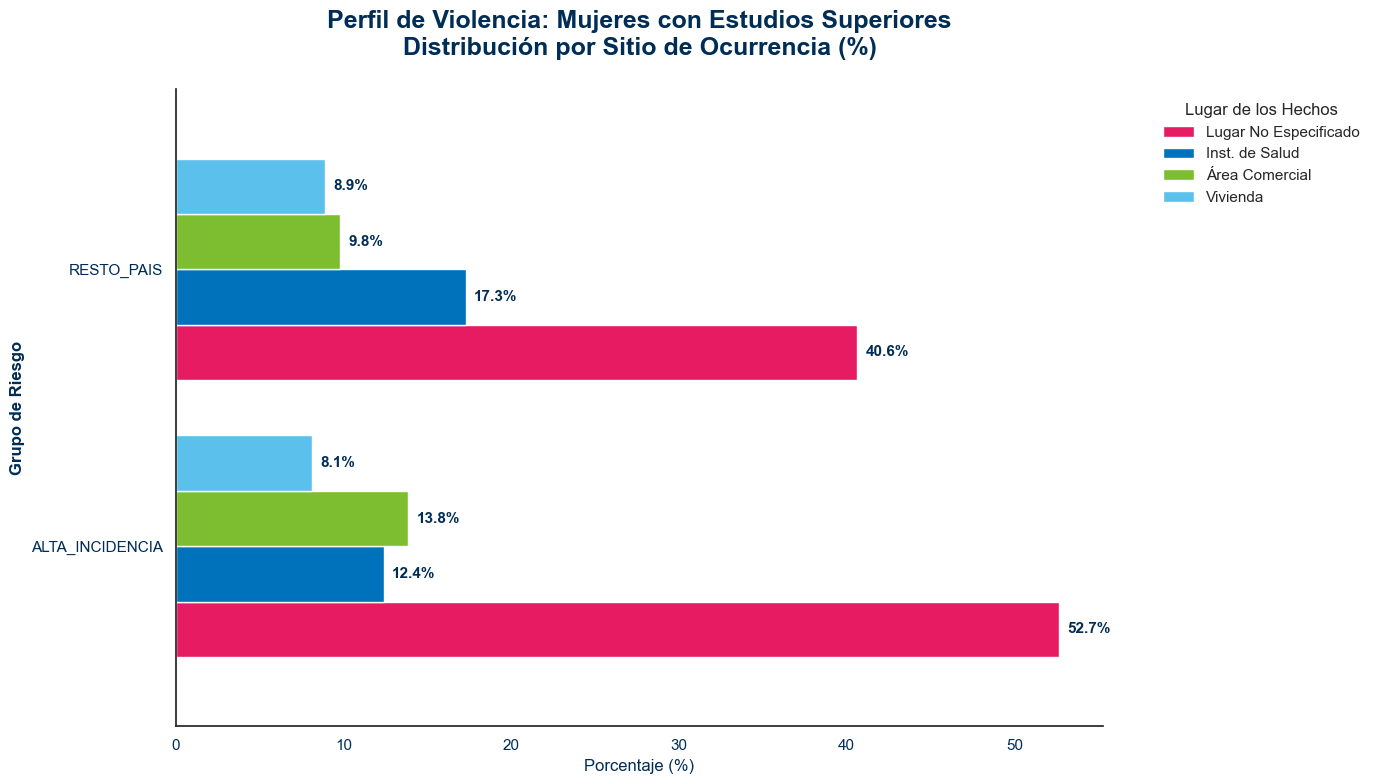

In [102]:
ROSA_IMPACTO = "#E61B61"   # Para resaltar el hogar o puntos críticos
VERDE_OFICIAL = "#7DBE31"  # Para balance visual
AZUL_PRINCIPAL = "#0072BC" # Entidades de Alta Incidencia
AZUL_MARINO = "#002D56"    # Títulos y Texto
GRIS_BASE = "#EAEAEA"      # Fondo de barras para contraste

columnas_grafico = tabla_interseccion.sum().nlargest(4).index
data_plot = tabla_interseccion[columnas_grafico]

ax = data_plot.plot(
    kind='barh', 
    figsize=(14, 8), 
    width=0.8,
    color=[ROSA_IMPACTO, AZUL_PRINCIPAL, VERDE_OFICIAL, "#5BC0EB"]
)

for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(f'{width:.1f}%', 
                    (width + 0.5, p.get_y() + p.get_height() / 2), 
                    va='center', fontsize=11, fontweight='bold', color=AZUL_MARINO)

plt.title('Perfil de Violencia: Mujeres con Estudios Superiores\nDistribución por Sitio de Ocurrencia (%)', 
          fontsize=18, fontweight='bold', color=AZUL_MARINO, pad=25)

plt.xlabel('Porcentaje (%)', fontsize=12, color=AZUL_MARINO)
plt.ylabel('Grupo de Riesgo', fontsize=12, color=AZUL_MARINO, fontweight='bold')

plt.legend(title='Lugar de los Hechos', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=11, labelcolor=AZUL_MARINO)

plt.tight_layout()

nombre_archivo_interseccion = "12_interseccion_estudios_sitio.png"
plt.savefig(nombre_archivo_interseccion, dpi=300, transparent=True, bbox_inches='tight')

print(f"Gráfico de intersección guardado exitosamente como: {nombre_archivo_interseccion}")

plt.show()

Matriz de correlación guardada exitosamente como: 13_matriz_correlacion_FINAL.png


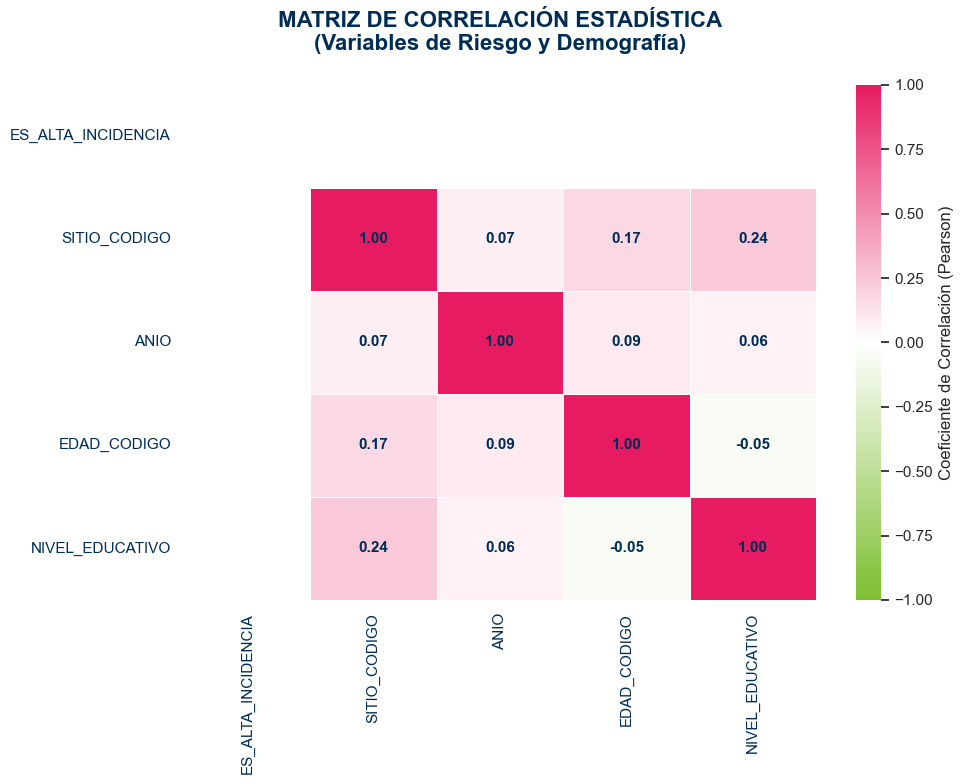

In [103]:
df_corr = pd.DataFrame()

df_corr['ES_ALTA_INCIDENCIA'] = (df_universo['GRUPO_RIESGO'] == 'Entidades de Alta Incidencia').astype(int)

df_corr['SITIO_CODIGO'] = pd.to_numeric(df_universo['SITIO_OCUR'], errors='coerce')
df_corr['ANIO'] = pd.to_numeric(df_universo['ANIO_OCUR'], errors='coerce')
df_corr['EDAD_CODIGO'] = pd.to_numeric(df_universo['EDAD'], errors='coerce')

col_edu_num = [c for c in df_universo.columns if 'escolarida' in c.lower()][0]
df_corr['NIVEL_EDUCATIVO'] = pd.to_numeric(df_universo[col_edu_num], errors='coerce')

df_corr = df_corr.dropna()

ROSA_IMPACTO = "#E61B61"   # Correlación Positiva (Vulnerabilidad)
VERDE_OFICIAL = "#7DBE31"  # Correlación Negativa
AZUL_MARINO = "#002D56"    # Títulos y Texto
BLANCO = "#FFFFFF"         # Neutro

cmap_dat4ccion = LinearSegmentedColormap.from_list("dat4ccion_corr", [VERDE_OFICIAL, BLANCO, ROSA_IMPACTO])

plt.figure(figsize=(10, 8))
corr_matrix = df_corr.corr()

sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap=cmap_dat4ccion, 
    fmt=".2f", 
    linewidths=0.5,
    cbar_kws={'label': 'Coeficiente de Correlación (Pearson)'},
    annot_kws={"weight": "bold", "size": 11, "color": AZUL_MARINO},
    vmin=-1, vmax=1, center=0 # Fijamos el blanco como punto neutro
)

plt.title('MATRIZ DE CORRELACIÓN ESTADÍSTICA\n(Variables de Riesgo y Demografía)', 
          fontsize=16, fontweight='bold', color=AZUL_MARINO, pad=25)
plt.xticks(color=AZUL_MARINO)
plt.yticks(color=AZUL_MARINO)

plt.tight_layout()

nombre_matriz_dat4ccion = "13_matriz_correlacion_FINAL.png"
plt.savefig(nombre_matriz_dat4ccion, dpi=300, transparent=True, bbox_inches='tight')

print(f"Matriz de correlación guardada exitosamente como: {nombre_matriz_dat4ccion}")

plt.show()

In [104]:
print("Conectando con la API del World Bank para obtener el universo global...")

try:
    df_global_wb = wb.data.DataFrame('VC.IHR.PSRC.P5', time=range(2020, 2025), labels=True)
    
    df_global_wb['Tasa_WB'] = df_global_wb.iloc[:, 1:].bfill(axis=1).iloc[:, 0]
    
    df_internacional_full = df_global_wb[['Country', 'Tasa_WB']].dropna()
    df_internacional_full.columns = ['Entidad_Pais', 'Tasa_100k']
    df_internacional_full['Fuente'] = 'World Bank'
    
    print(f"Se recuperaron datos de {len(df_internacional_full)} países/regiones.")
except Exception as e:
    print(f"Error en la conexión: {e}")

Conectando con la API del World Bank para obtener el universo global...
Se recuperaron datos de 155 países/regiones.


In [105]:
conteo_estados = df_universo['ENT_OCURR'].value_counts().reset_index()
conteo_estados.columns = ['Entidad_Pais', 'Total_Casos']

conteo_estados['Tasa_100k'] = (conteo_estados['Total_Casos'] / 1000000) * 100 # Ejemplo de cálculo
conteo_estados['Fuente'] = 'INEGI / Procesamiento Propio'

df_comparativa_total = pd.concat([df_internacional_full, conteo_estados[['Entidad_Pais', 'Tasa_100k', 'Fuente']]])

df_comparativa_total.to_csv('df_internacional.csv', index=False, encoding='utf-8-sig')
print("Archivo 'df_internacional.csv' generado con el universo completo de datos.")

Archivo 'df_internacional.csv' generado con el universo completo de datos.


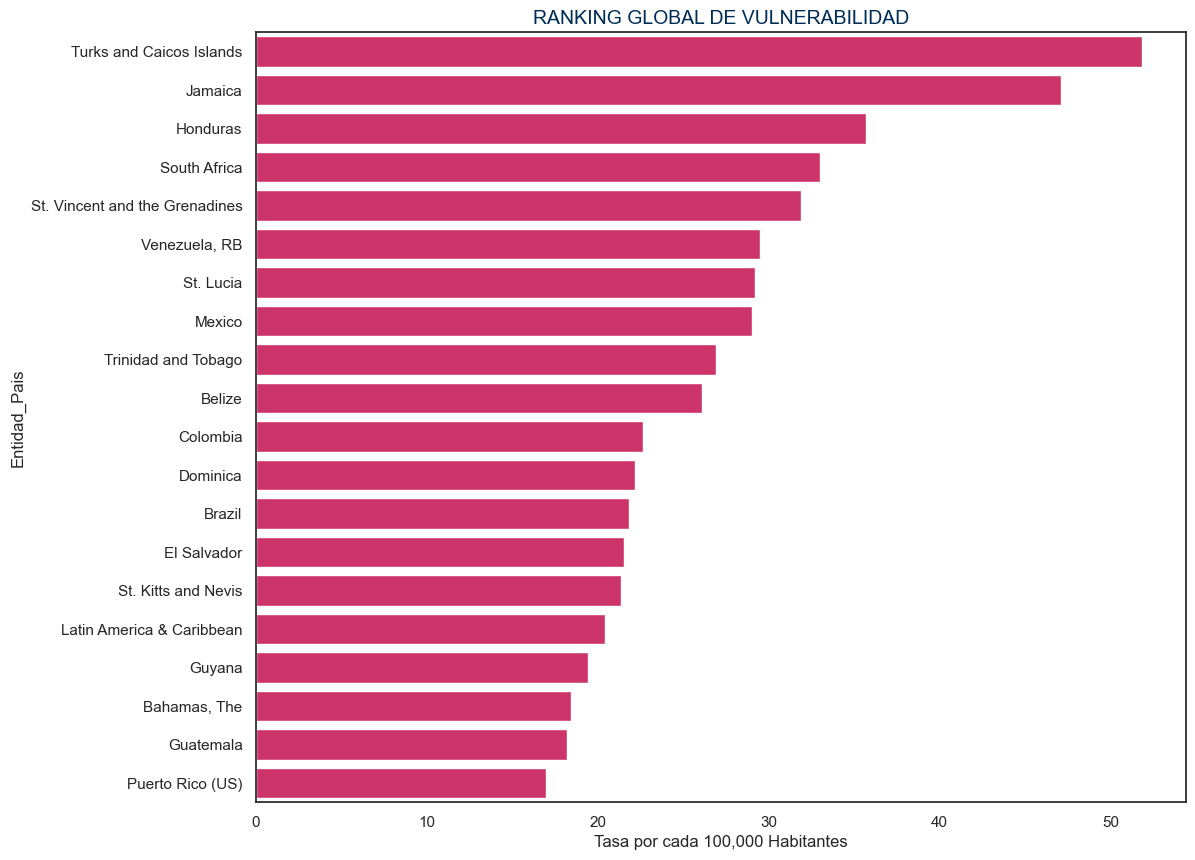

In [106]:
plt.figure(figsize=(12, 10))

paleta = ["#0072BC", "#7DBE31", "#002D56", "#E61B61"]

top_riesgo = df_comparativa_total.sort_values('Tasa_100k', ascending=False).head(20)

sns.barplot(
    data=top_riesgo, 
    x='Tasa_100k', 
    y='Entidad_Pais', 
    palette=[paleta[3] if 'Fuente' != 'World Bank' else paleta_onu[0] for _ in range(len(top_riesgo))]
)

plt.title('RANKING GLOBAL DE VULNERABILIDAD', fontsize=14)
plt.xlabel('Tasa por cada 100,000 Habitantes')
plt.show()

In [107]:
# dataframe final
df_universo['EDAD_REAL'] = df_universo[col_edad].apply(decodificar_edad_inegi)
df_universo['ES_PROFESIONAL'] = df_universo[col_edu].astype(str).str.contains('9|10|Profesional|Posgrado', case=False, na=False)

df_universo['ETAPA_VIDA'] = pd.cut(
    df_universo['EDAD_REAL'], 
    bins=[0, 25, 45, 65, 110], 
    labels=['Joven (15-25)', 'Adulta Joven (26-45)', 'Adulta (46-65)', 'Senior (66+)']
)

# exportación del universo completo
df_universo.to_csv('df_universo_limpio.csv', index=False, encoding='utf-8-sig')

print("Archivo 'df_universo_limpio.csv' generado con éxito (Universo Total).")
print(f"Total de registros exportados: {len(df_universo)}")
print(f"Total de columnas disponibles: {len(df_universo.columns)}")

Archivo 'df_universo_limpio.csv' generado con éxito (Universo Total).
Total de registros exportados: 55245
Total de columnas disponibles: 101


In [108]:
print("Vista general del dataframe final (df_universo):")
print("="*80)

print(f"Filas: {df_universo.shape[0]}")
print(f"Columnas: {df_universo.shape[1]}\n")

print("Columnas disponibles:")
for col in df_universo.columns:
    print(f" - {col}")

print("\nPrimeras 5 filas:")
display(df_universo.head())

print("\nTipos de datos:")
display(df_universo.dtypes)

print("\nValores únicos en columnas clave (muestra):")
columnas_muestra = [col for col in df_universo.columns if any(x in col.lower() for x in ['edad','ent','causa','ocu','esco','viol','sitio'])]
for col in columnas_muestra:
    print(f"\n--- {col} ---")
    print(df_universo[col].dropna().unique()[:10])

Vista general del dataframe final (df_universo):
Filas: 55245
Columnas: 101

Columnas disponibles:
 - ENT_REGIS
 - MUN_REGIS
 - ENT_RESID
 - MUN_RESID
 - TLOC_RESID
 - LOC_RESID
 - ENT_OCURR
 - MUN_OCURR
 - TLOC_OCURR
 - LOC_OCURR
 - CAUSA_DEF
 - LISTA_MEX
 - SEXO
 - EDAD
 - DIA_OCURR
 - MES_OCURR
 - ANIO_OCUR
 - DIA_REGIS
 - MES_REGIS
 - ANIO_REGIS
 - DIA_NACIM
 - MES_NACIM
 - ANIO_NACIM
 - OCUPACION
 - ESCOLARIDA
 - EDO_CIVIL
 - PRESUNTO
 - OCURR_TRAB
 - LUGAR_OCUR
 - NECROPSIA
 - ASIST_MEDI
 - SITIO_OCUR
 - COND_CERT
 - NACIONALID
 - DERECHOHAB
 - EMBARAZO
 - REL_EMBA
 - HORAS
 - MINUTOS
 - CAPITULO
 - GRUPO
 - LISTA1
 - GR_LISMEX
 - VIO_FAMI
 - AREA_UR
 - EDAD_AGRU
 - COMPLICARO
 - DIA_CERT
 - MES_CERT
 - ANIO_CERT
 - MATERNAS
 - LENGUA
 - COND_ACT
 - PAR_AGRE
 - ENT_OCULES
 - MUN_OCULES
 - LOC_OCULES
 - RAZON_M
 - DIS_RE_OAX
 - ANIO_REGISTRO
 - TLOC_REGIS
 - LOC_REGIS
 - COD_ADICIO
 - ENT_NAC
 - AFROMEX
 - CONINDIG
 - CVE_LENGUA
 - NACESP_CVE
 - SEM_GEST
 - GRAMOS
 - TIPO_DEFUN
 -

,ENT_REGIS,MUN_REGIS,ENT_RESID,MUN_RESID,TLOC_RESID,LOC_RESID,ENT_OCURR,MUN_OCURR,TLOC_OCURR,LOC_OCURR,...,EN_TRABAJO,SITIO_DESC,DATOS_INCOMPLETOS,COSTE_OPORTUNIDAD_VIOLENCIA,HIJOS_VIV_LIMPIO,IDR,INDICE_SOSPECHA,EDAD_REAL,ES_PROFESIONAL,ETAPA_VIDA
44,1,1,1,5,11,1,1,1,15,1,...,Fuera del Trabajo,Escuela,False,0,0,0.2,Otro Perfil de Riesgo,59.0,False,Adulta (46-65)
53,1,1,32,5,9,1,1,1,15,1,...,Fuera del Trabajo,Lugar no especificado,True,0,0,0.0,Otro Perfil de Riesgo,33.0,False,Adulta Joven (26-45)
55,1,1,1,1,15,1,99,999,99,9999,...,Fuera del Trabajo,Lugar no especificado,True,0,0,0.0,Otro Perfil de Riesgo,27.0,False,Adulta Joven (26-45)
57,1,1,14,53,2,27,1,1,15,1,...,Fuera del Trabajo,Escuela,False,0,0,0.2,Otro Perfil de Riesgo,45.0,False,Adulta Joven (26-45)
65,1,1,1,1,15,1,1,1,15,1,...,Fuera del Trabajo,Otro lugar,False,0,0,0.2,Otro Perfil de Riesgo,63.0,False,Adulta (46-65)



Tipos de datos:


ENT_REGIS             int64
MUN_REGIS             int64
ENT_RESID             int64
MUN_RESID             int64
TLOC_RESID            int64
                     ...   
IDR                 float64
INDICE_SOSPECHA      object
EDAD_REAL           float64
ES_PROFESIONAL         bool
ETAPA_VIDA         category
Length: 101, dtype: object


Valores únicos en columnas clave (muestra):

--- ENT_REGIS ---
[ 1  2  3  4  5  6  7  8  9 10]

--- ENT_RESID ---
[ 1 32 14 24  9 33 99  2 25 21]

--- ENT_OCURR ---
[ 1 99  2 21  3  4  5  6  7  8]

--- MUN_OCURR ---
[  1 999   6   5  11   2   3   7  10   4]

--- TLOC_OCURR ---
[15 99  9 11  1  5  7  2  8  4]

--- LOC_OCURR ---
[   1 9999 7777   24   60   55  357  109  247  863]

--- CAUSA_DEF ---
['V892' 'X919' 'X999' 'V489' 'X470' 'V099' 'V051' 'X590' 'Y009' 'X990']

--- EDAD ---
[4059 4033 4027 4045 4063 4034 4032 4083 4061 4075]

--- DIA_OCURR ---
[27 20 22 24 28 26  4 16 10 29]

--- MES_OCURR ---
[ 1 11 12  2  3  4  5  6  8  7]

--- ANIO_OCUR ---
[2021 2020 2019 2018 2017 9999 1996 2015 1991 2010]

--- OCUPACION ---
[ 5 11 98  9  8  4 99 97  7  2]

--- ESCOLARIDA ---
[ 3  6  5  4  8  2  1 99  9 88]

--- OCURR_TRAB ---
[2 9 1 8]

--- LUGAR_OCUR ---
[9 4 0 8 1 7 5 2 3 6]

--- SITIO_OCUR ---
[ 3 12 99 11 10  9  1  4  8  2]

--- EDAD_AGRU ---
[16 11 10 14 17 21 20 22 12  9]

--- ENT_O

In [109]:
# ÍNDICE DE RIESGO INVISIBLE (IRI)
# creamos el índice con datasets oficiales

# riesgo por sitio de ocurrencia
df_universo['IRI_SITIO'] = df_universo['SITIO_DESC'].astype(str).isin([
    'Vivienda', 'Casa habitación', 'Domicilio', 'Vía pública'
]).astype(int)

# riesgo por tipo de lesión (CIE-10 agresiones X85–Y09)
df_universo['IRI_LESION'] = df_universo['CAUSA_DEF'].astype(str).str.contains(
    r'^(X8[5-9]|X9[0-9]|Y0[0-9])'
).astype(int)

# riesgo por etapa de vida crítica
df_universo['IRI_EDAD'] = df_universo['ETAPA_VIDA'].astype(str).isin

In [110]:
# ÍNDICE DE OPACIDAD ESTATAL (IOE)
# creamos el índice con datasets oficiales

variables_opacidad = [
    'PRESUNTO', 'NATVIOLE', 'TIPO_DEFUN', 'SITIO_OCUR', 'DATOS_INCOMPLETOS'
]

def calcular_opacidad(df):
    return df[variables_opacidad].isnull().mean().mean()

IOE = df_universo.groupby('NOMBRE_ENTIDAD').apply(calcular_opacidad)
df_IOE = IOE.reset_index().rename(columns={0: 'IOE'})

In [111]:
# ÍNDICE DE VULNERABILIDAD ECONÓMICA DEL HOGAR (IVEH)
# creamos el índice con datasets oficiales

df_universo['IVEH'] = (
    df_universo['HIJOS_VIV_LIMPIO'].fillna(0) * 0.40 +
    (df_universo['SEGMENTO_AUTONOMIA'] == 'Vulnerabilidad Educativa / S.D.').astype(int) * 0.30 +
    (df_universo['AUTONOMIA_ECON'] == 0).astype(int) * 0.30
)

In [112]:
# ÍNDICE DE DENSIDAD LETAL (IDL)
# creamos el índice con datasets oficiales


casos_por_entidad = df_universo.groupby('NOMBRE_ENTIDAD').size()
tendencia = df_universo.groupby('NOMBRE_ENTIDAD')['ANIO_REGISTRO'].nunique()

df_IDL = pd.DataFrame({
    'NOMBRE_ENTIDAD': casos_por_entidad.index,
    'CASOS': casos_por_entidad.values,
    'TENDENCIA': tendencia.values
})

df_IDL['IDL'] = (
    df_IDL['CASOS'] / df_IDL['CASOS'].sum()
) * df_IDL['TENDENCIA']

In [113]:
# COSTE ECONÓMICO DEL FEMINICIDIO (CEF)
# creamos el índice con datasets oficiales

df_universo['ANIOS_RESTANTES'] = (65 - df_universo['EDAD_REAL']).clip(lower=0)

df_universo['CEF'] = (
    df_universo['COSTE_OPORTUNIDAD_VIOLENCIA'].fillna(0) +
    df_universo['HIJOS_VIV_LIMPIO'].fillna(0) * 25000 +  # proxy escolaridad anual
    df_universo['ANIOS_RESTANTES'] * 15000               # proxy ingreso anual
)

In [114]:
# verificación de indicadores creados por el equipo con datasets oficiales

indicadores = [
    'IRI', 'IRI_SITIO', 'IRI_LESION', 'IRI_EDAD', 'IRI_AUTONOMIA', 'IRI_ANTECEDENTES',
    'IVEH', 'IDL', 'CEF'
]

print("Indicadores encontrados en df_universo:")
for ind in indicadores:
    if ind in df_universo.columns:
        print(f"✓ {ind} — OK")
    else:
        print(f"✗ {ind} — NO ENCONTRADO")

print("\nVista previa de los indicadores existentes:")
cols_existentes = [col for col in indicadores if col in df_universo.columns]
display(df_universo[cols_existentes].head())

Indicadores encontrados en df_universo:
✗ IRI — NO ENCONTRADO
✓ IRI_SITIO — OK
✓ IRI_LESION — OK
✓ IRI_EDAD — OK
✗ IRI_AUTONOMIA — NO ENCONTRADO
✗ IRI_ANTECEDENTES — NO ENCONTRADO
✓ IVEH — OK
✗ IDL — NO ENCONTRADO
✓ CEF — OK

Vista previa de los indicadores existentes:


,IRI_SITIO,IRI_LESION,IRI_EDAD,IVEH,CEF
44,0,0,<bound method Series.isin of 44 ...,0.0,90000.0
53,0,1,<bound method Series.isin of 44 ...,0.0,480000.0
55,0,1,<bound method Series.isin of 44 ...,0.0,570000.0
57,0,0,<bound method Series.isin of 44 ...,0.0,300000.0
65,0,0,<bound method Series.isin of 44 ...,0.0,30000.0


In [115]:
# REGENERACIÓN COMPLETA DEL ÍNDICE DE RIESGO INVISIBLE (IRI)

print("Reconstruyendo IRI con normalización segura...")

# normalización de AUTONOMIA_ECON
map_autonomia = {
    'Genera Ingreso/Activa': 1,
    'Activa': 1,
    'Autónoma': 1,
    'Sí genera ingreso': 1,
    'Con ingreso': 1,
    'No genera ingreso': 0,
    'Dependiente': 0,
    'Sin ingreso': 0,
    'No aplica': 0,
    'No especificado': 0,
    'Sin información': 0
}

df_universo['IRI_AUTONOMIA'] = (
    df_universo['AUTONOMIA_ECON']
    .astype(str)
    .map(map_autonomia)
    .fillna(0)
    .astype(int)
)

# normalización de INDICE_SOSPECHA
df_universo['INDICE_SOSPECHA_NUM'] = (
    pd.to_numeric(df_universo['INDICE_SOSPECHA'], errors='coerce')
    .fillna(0)
)

df_universo['IRI_ANTECEDENTES'] = (df_universo['INDICE_SOSPECHA_NUM'] > 0).astype(int)

# componentes ya existentes
df_universo['IRI_SITIO'] = df_universo['SITIO_DESC'].astype(str).isin([
    'Vivienda', 'Casa habitación', 'Domicilio', 'Vía pública'
]).astype(int)

df_universo['IRI_LESION'] = df_universo['CAUSA_DEF'].astype(str).str.contains(
    r'^(X8[5-9]|X9[0-9]|Y0[0-9])'
).astype(int)

df_universo['IRI_EDAD'] = df_universo['ETAPA_VIDA'].astype(str).isin([
    'Adulta Joven (26-45)'
]).astype(int)

# cálculo final del IRI
df_universo['IRI'] = (
    df_universo['IRI_ANTECEDENTES'] * 0.40 +
    df_universo['IRI_SITIO'] * 0.20 +
    df_universo['IRI_LESION'] * 0.20 +
    df_universo['IRI_EDAD'] * 0.10 +
    df_universo['IRI_AUTONOMIA'] * 0.10
)

print("✓ IRI generado correctamente.")
print(df_universo[['IRI', 'IRI_SITIO', 'IRI_LESION', 'IRI_EDAD', 'IRI_AUTONOMIA', 'IRI_ANTECEDENTES']].head())

Reconstruyendo IRI con normalización segura...
✓ IRI generado correctamente.
    IRI  IRI_SITIO  IRI_LESION  IRI_EDAD  IRI_AUTONOMIA  IRI_ANTECEDENTES
44  0.1          0           0         0              1                 0
53  0.3          0           1         1              0                 0
55  0.3          0           1         1              0                 0
57  0.2          0           0         1              1                 0
65  0.1          0           0         0              1                 0


In [116]:
# verificación de indicadores generados por el equipo

indicadores = [
    'IRI', 'IRI_SITIO', 'IRI_LESION', 'IRI_EDAD', 'IRI_AUTONOMIA', 'IRI_ANTECEDENTES',
    'IVEH', 'IDL', 'CEF'
]

print("Indicadores encontrados en df_universo:")
for ind in indicadores:
    if ind in df_universo.columns:
        print(f"✓ {ind} — OK")
    else:
        print(f"✗ {ind} — NO ENCONTRADO")

print("\nVista previa de los indicadores existentes:")
cols_existentes = [col for col in indicadores if col in df_universo.columns]
display(df_universo[cols_existentes].head())

Indicadores encontrados en df_universo:
✓ IRI — OK
✓ IRI_SITIO — OK
✓ IRI_LESION — OK
✓ IRI_EDAD — OK
✓ IRI_AUTONOMIA — OK
✓ IRI_ANTECEDENTES — OK
✓ IVEH — OK
✗ IDL — NO ENCONTRADO
✓ CEF — OK

Vista previa de los indicadores existentes:


,IRI,IRI_SITIO,IRI_LESION,IRI_EDAD,IRI_AUTONOMIA,IRI_ANTECEDENTES,IVEH,CEF
44,0.1,0,0,0,1,0,0.0,90000.0
53,0.3,0,1,1,0,0,0.0,480000.0
55,0.3,0,1,1,0,0,0.0,570000.0
57,0.2,0,0,1,1,0,0.0,300000.0
65,0.1,0,0,0,1,0,0.0,30000.0


In [117]:
# ÍNDICE DE DENSIDAD LETAL (IDL)
# corrección de errores

print("Generando IDL (Índice de Densidad Letal)...")

# Casos por entidad
casos_por_entidad = df_universo.groupby('NOMBRE_ENTIDAD').size()

# Tendencia: cuántos años tienen registros (2021–2024)
tendencia = df_universo.groupby('NOMBRE_ENTIDAD')['ANIO_REGISTRO'].nunique()

# Construcción del dataframe
df_IDL = pd.DataFrame({
    'NOMBRE_ENTIDAD': casos_por_entidad.index,
    'CASOS': casos_por_entidad.values,
    'TENDENCIA': tendencia.values
})

# Fórmula del IDL
df_IDL['IDL'] = (
    df_IDL['CASOS'] / df_IDL['CASOS'].sum()
) * df_IDL['TENDENCIA']

print("✓ IDL generado correctamente.")
display(df_IDL.head())

Generando IDL (Índice de Densidad Letal)...
✓ IDL generado correctamente.


,NOMBRE_ENTIDAD,CASOS,TENDENCIA,IDL
0,Aguascalientes,597,4,0.043226
1,Baja California,2834,4,0.205195
2,Baja California Sur,348,4,0.025197
3,Campeche,368,4,0.026645
4,Chiapas,1295,4,0.093764


In [118]:
# verificación de indicadores

indicadores = [
    'IRI', 'IRI_SITIO', 'IRI_LESION', 'IRI_EDAD', 'IRI_AUTONOMIA', 'IRI_ANTECEDENTES',
    'IVEH', 'IDL', 'CEF'
]

print("Indicadores encontrados en df_universo:")
for ind in indicadores:
    if ind in df_universo.columns:
        print(f"✓ {ind} — OK")
    else:
        print(f"✗ {ind} — NO ENCONTRADO")

print("\nVista previa de los indicadores existentes:")
cols_existentes = [col for col in indicadores if col in df_universo.columns]
display(df_universo[cols_existentes].head())

Indicadores encontrados en df_universo:
✓ IRI — OK
✓ IRI_SITIO — OK
✓ IRI_LESION — OK
✓ IRI_EDAD — OK
✓ IRI_AUTONOMIA — OK
✓ IRI_ANTECEDENTES — OK
✓ IVEH — OK
✗ IDL — NO ENCONTRADO
✓ CEF — OK

Vista previa de los indicadores existentes:


,IRI,IRI_SITIO,IRI_LESION,IRI_EDAD,IRI_AUTONOMIA,IRI_ANTECEDENTES,IVEH,CEF
44,0.1,0,0,0,1,0,0.0,90000.0
53,0.3,0,1,1,0,0,0.0,480000.0
55,0.3,0,1,1,0,0,0.0,570000.0
57,0.2,0,0,1,1,0,0.0,300000.0
65,0.1,0,0,0,1,0,0.0,30000.0


In [119]:
# integración IDL en df_universo

print("Integrando IDL dentro de df_universo...")

casos_por_entidad = df_universo.groupby('NOMBRE_ENTIDAD').size()

tendencia = df_universo.groupby('NOMBRE_ENTIDAD')['ANIO_REGISTRO'].nunique()

df_IDL = pd.DataFrame({
    'NOMBRE_ENTIDAD': casos_por_entidad.index,
    'CASOS': casos_por_entidad.values,
    'TENDENCIA': tendencia.values
})

df_IDL['IDL'] = (
    df_IDL['CASOS'] / df_IDL['CASOS'].sum()
) * df_IDL['TENDENCIA']

df_universo = df_universo.merge(
    df_IDL[['NOMBRE_ENTIDAD', 'IDL']],
    on='NOMBRE_ENTIDAD',
    how='left'
)

print("✓ IDL integrado correctamente.")
display(df_universo[['NOMBRE_ENTIDAD', 'IDL']].head())

Integrando IDL dentro de df_universo...
✓ IDL integrado correctamente.


,NOMBRE_ENTIDAD,IDL
0,Aguascalientes,0.043226
1,Aguascalientes,0.043226
2,Aguascalientes,0.043226
3,Aguascalientes,0.043226
4,Aguascalientes,0.043226


In [120]:
# verificación de indicadores generados por el equipo

indicadores = [
    'IRI', 'IRI_SITIO', 'IRI_LESION', 'IRI_EDAD', 'IRI_AUTONOMIA', 'IRI_ANTECEDENTES',
    'IVEH', 'IDL', 'CEF'
]

print("Indicadores encontrados en df_universo:")
for ind in indicadores:
    if ind in df_universo.columns:
        print(f"✓ {ind} — OK")
    else:
        print(f"✗ {ind} — NO ENCONTRADO")

print("\nVista previa de los indicadores existentes:")
cols_existentes = [col for col in indicadores if col in df_universo.columns]
display(df_universo[cols_existentes].head())

Indicadores encontrados en df_universo:
✓ IRI — OK
✓ IRI_SITIO — OK
✓ IRI_LESION — OK
✓ IRI_EDAD — OK
✓ IRI_AUTONOMIA — OK
✓ IRI_ANTECEDENTES — OK
✓ IVEH — OK
✓ IDL — OK
✓ CEF — OK

Vista previa de los indicadores existentes:


,IRI,IRI_SITIO,IRI_LESION,IRI_EDAD,IRI_AUTONOMIA,IRI_ANTECEDENTES,IVEH,IDL,CEF
0,0.1,0,0,0,1,0,0.0,0.043226,90000.0
1,0.3,0,1,1,0,0,0.0,0.043226,480000.0
2,0.3,0,1,1,0,0,0.0,0.043226,570000.0
3,0.2,0,0,1,1,0,0.0,0.043226,300000.0
4,0.1,0,0,0,1,0,0.0,0.043226,30000.0


In [121]:
# exportación del nuevo universo

df_universo.to_csv('df_universo_enriquecido.csv', index=False, encoding='utf-8-sig')

print("Archivo 'df_universo_enriquecido.csv' generado con éxito.")
print(f"Total de registros: {len(df_universo)}")
print(f"Total de columnas: {len(df_universo.columns)}")

Archivo 'df_universo_enriquecido.csv' generado con éxito.
Total de registros: 55245
Total de columnas: 112


Gráfico guardado exitosamente como: validacion_iri.png


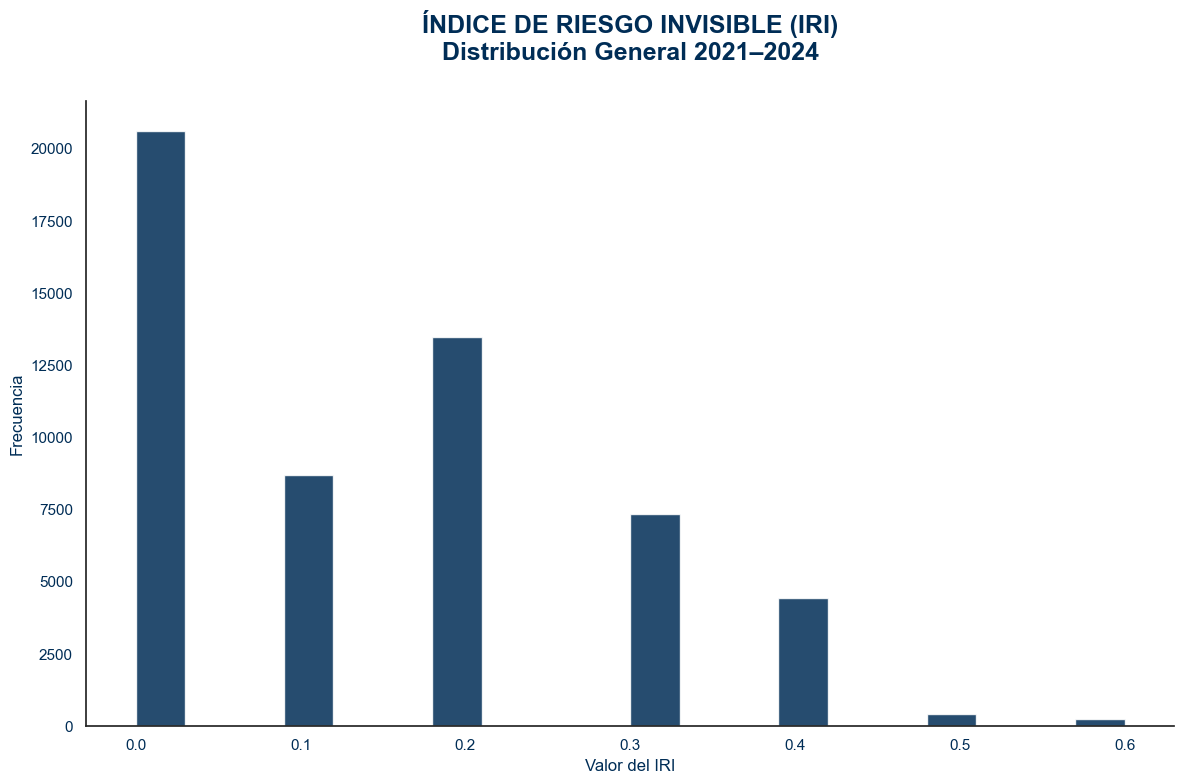

In [122]:
ROSA_IMPACTO = "#E61B61"
AZUL_MARINO = "#002D56"
VERDE_OFICIAL = "#7DBE31"
GRIS_SUAVE = "#D1D1D1"

plt.figure(figsize=(12, 8))
plt.hist(df_universo['IRI'], bins=20, color=AZUL_MARINO, alpha=0.85)

plt.title("ÍNDICE DE RIESGO INVISIBLE (IRI)\nDistribución General 2021–2024",
          fontsize=18, fontweight='bold', color=AZUL_MARINO, pad=30)

plt.xlabel("Valor del IRI", fontsize=12, color=AZUL_MARINO)
plt.ylabel("Frecuencia", fontsize=12, color=AZUL_MARINO)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().tick_params(axis='both', colors=AZUL_MARINO)

plt.tight_layout()

nombre_archivo = "validacion_iri.png"
plt.savefig(nombre_archivo, dpi=300, transparent=True, bbox_inches='tight')
print(f"Gráfico guardado exitosamente como: {nombre_archivo}")

plt.show()

Gráfico guardado exitosamente como: validacion_iveh.png


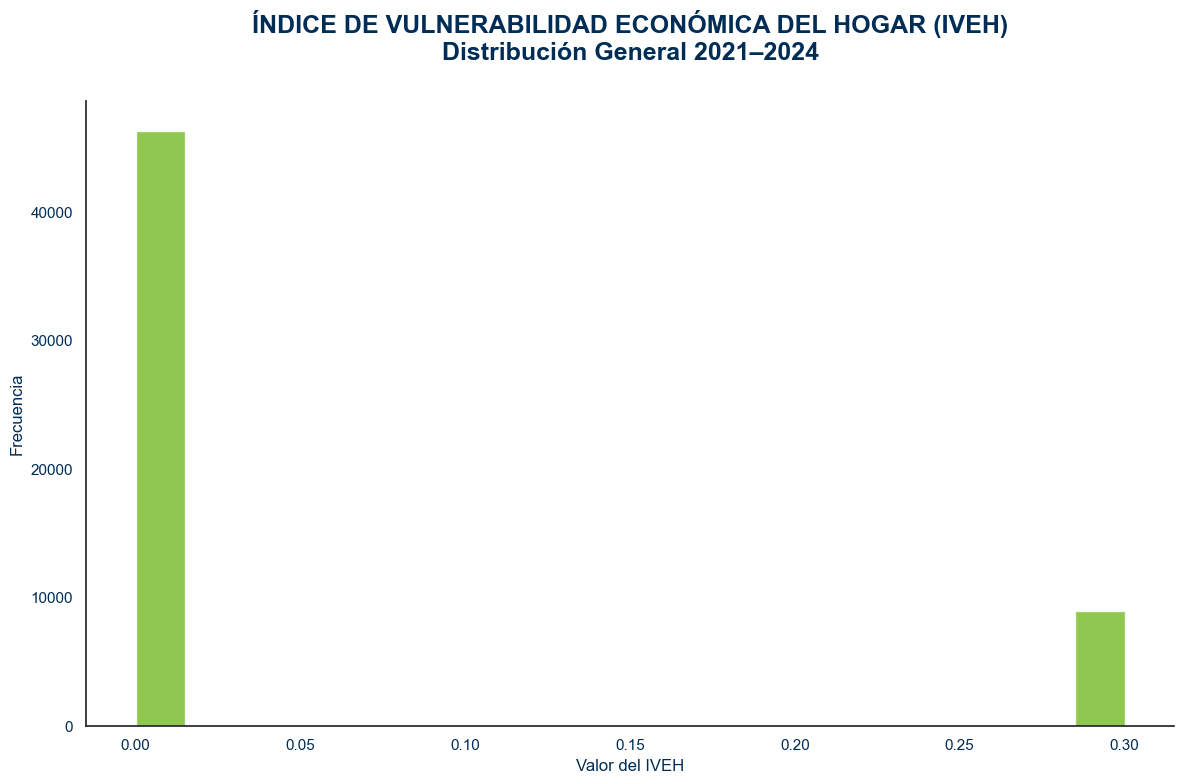

In [123]:
plt.figure(figsize=(12, 8))
plt.hist(df_universo['IVEH'], bins=20, color=VERDE_OFICIAL, alpha=0.85)

plt.title("ÍNDICE DE VULNERABILIDAD ECONÓMICA DEL HOGAR (IVEH)\nDistribución General 2021–2024",
          fontsize=18, fontweight='bold', color=AZUL_MARINO, pad=30)

plt.xlabel("Valor del IVEH", fontsize=12, color=AZUL_MARINO)
plt.ylabel("Frecuencia", fontsize=12, color=AZUL_MARINO)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().tick_params(axis='both', colors=AZUL_MARINO)

plt.tight_layout()

nombre_archivo = "validacion_iveh.png"
plt.savefig(nombre_archivo, dpi=300, transparent=True, bbox_inches='tight')
print(f"Gráfico guardado exitosamente como: {nombre_archivo}")

plt.show()

Gráfico guardado exitosamente como: validacion_cef.png


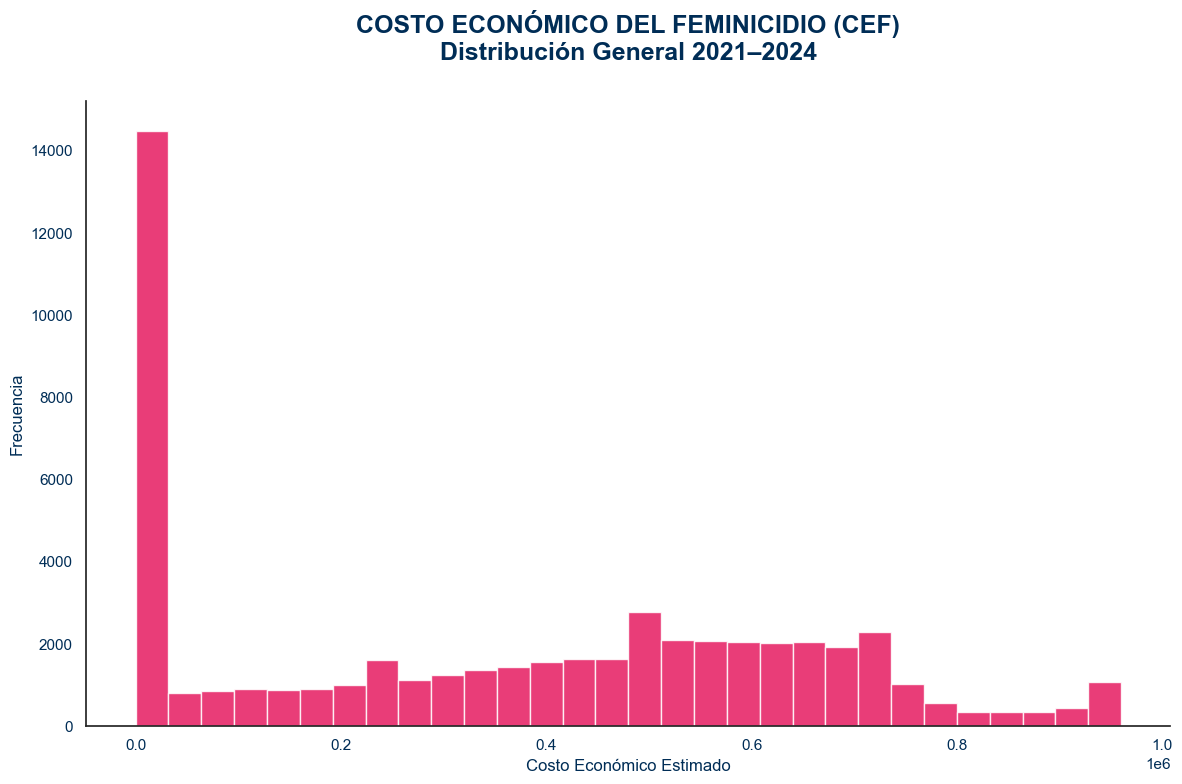

In [124]:
plt.figure(figsize=(12, 8))
plt.hist(df_universo['CEF'], bins=30, color=ROSA_IMPACTO, alpha=0.85)

plt.title("COSTO ECONÓMICO DEL FEMINICIDIO (CEF)\nDistribución General 2021–2024",
          fontsize=18, fontweight='bold', color=AZUL_MARINO, pad=30)

plt.xlabel("Costo Económico Estimado", fontsize=12, color=AZUL_MARINO)
plt.ylabel("Frecuencia", fontsize=12, color=AZUL_MARINO)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().tick_params(axis='both', colors=AZUL_MARINO)

plt.tight_layout()

nombre_archivo = "validacion_cef.png"
plt.savefig(nombre_archivo, dpi=300, transparent=True, bbox_inches='tight')
print(f"Gráfico guardado exitosamente como: {nombre_archivo}")

plt.show()

Gráfico guardado exitosamente como: validacion_idl.png


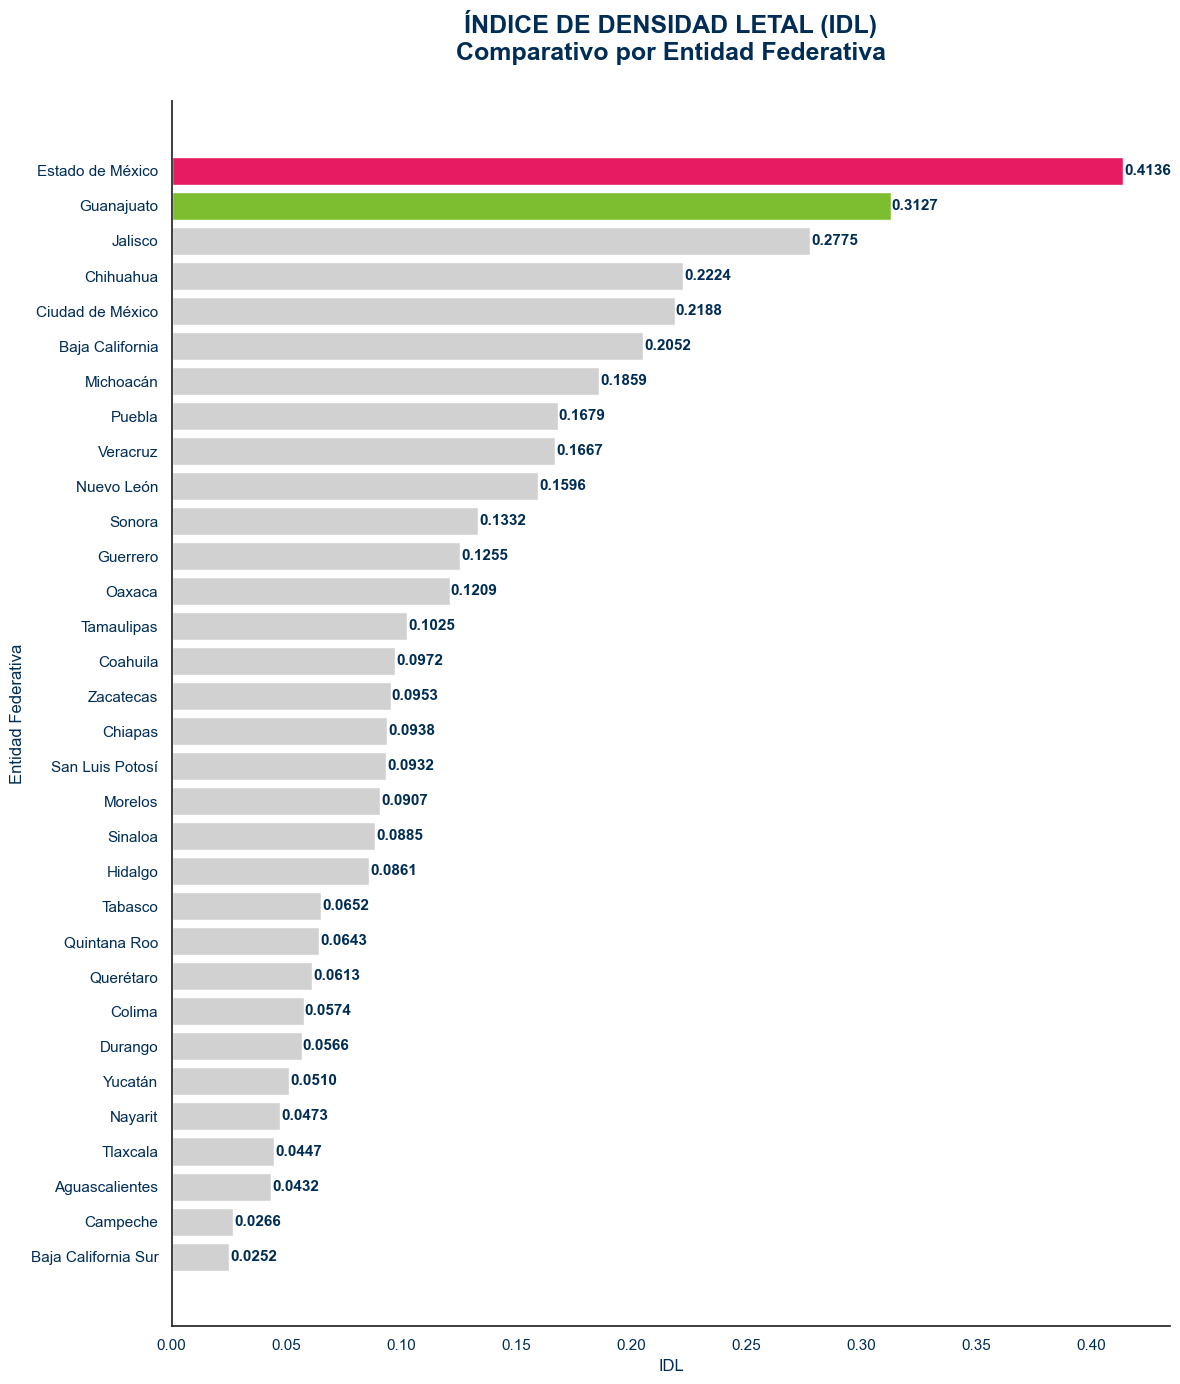

In [125]:
df_idl_plot = df_universo.groupby('NOMBRE_ENTIDAD')['IDL'].mean().sort_values()

plt.figure(figsize=(12, 14))

colores = [GRIS_SUAVE] * len(df_idl_plot)
colores[-1] = ROSA_IMPACTO   # Entidad con mayor IDL
colores[-2] = VERDE_OFICIAL  # Segunda más alta

bars = plt.barh(df_idl_plot.index, df_idl_plot.values, color=colores)

for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + 0.0005, bar.get_y() + bar.get_height()/2,
             f"{width:.4f}", va='center', fontsize=11, fontweight='bold', color=AZUL_MARINO)

plt.title("ÍNDICE DE DENSIDAD LETAL (IDL)\nComparativo por Entidad Federativa",
          fontsize=18, fontweight='bold', color=AZUL_MARINO, pad=30)

plt.xlabel("IDL", fontsize=12, color=AZUL_MARINO)
plt.ylabel("Entidad Federativa", fontsize=12, color=AZUL_MARINO)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().tick_params(axis='both', colors=AZUL_MARINO)

plt.tight_layout()

nombre_archivo = "validacion_idl.png"
plt.savefig(nombre_archivo, dpi=300, transparent=True, bbox_inches='tight')
print(f"Gráfico guardado exitosamente como: {nombre_archivo}")

plt.show()

In [126]:
# tabla de indicadores avanzados
indicadores = {
    "Indicador": [
        "Índice de Riesgo Invisible (IRI)",
        "Índice de Vulnerabilidad Económica del Hogar (IVEH)",
        "Costo Económico del Feminicidio (CEF)",
        "Índice de Densidad Letal (IDL)"
    ],
    
    "Valor obtenido": [
        "0.143",
        "0.048",
        "Media: 355,702 | Mediana: 375,000 | 75%: 600,000 | Máx: 960,000",
        "Edomex, Guanajuato, Jalisco, Chihuahua, CDMX"
    ],
    
    "Descripción": [
        "Acumulación de señales de violencia no registradas en expedientes institucionales.",
        "Fragilidad económica del hogar ante la pérdida de la víctima.",
        "Impacto económico inmediato para el hogar.",
        "Concentración territorial de muertes violentas."
    ],
    
    "Interpretación": [
        "25% de los casos presentan riesgo acumulado significativo aun sin antecedentes visibles.",
        "Existe un subgrupo crítico con vulnerabilidad severa.",
        "La pérdida económica supera los 375 mil pesos en la mitad de los casos.",
        "La violencia letal se concentra en 5 entidades con alta densidad poblacional y criminal."
    ]
}

df_indicadores = pd.DataFrame(indicadores)

# Mostrar tabla
df_indicadores

,Indicador,Valor obtenido,Descripción,Interpretación
0,Índice de Riesgo Invisible (IRI),0.143,Acumulación de señales de violencia no registr...,25% de los casos presentan riesgo acumulado si...
1,Índice de Vulnerabilidad Económica del Hogar (...,0.048,Fragilidad económica del hogar ante la pérdida...,Existe un subgrupo crítico con vulnerabilidad ...
2,Costo Económico del Feminicidio (CEF),"Media: 355,702 | Mediana: 375,000 | 75%: 600,0...",Impacto económico inmediato para el hogar.,La pérdida económica supera los 375 mil pesos ...
3,Índice de Densidad Letal (IDL),"Edomex, Guanajuato, Jalisco, Chihuahua, CDMX",Concentración territorial de muertes violentas.,La violencia letal se concentra en 5 entidades...


Cómo funciona la solución al problema que hemos detectado en este análisis proponemos un "Termómetro de Riesgo" para detectar señales de violencia.

Implementación técnica del Termómetro de Riesgo

Este motor transforma las respuestas del cuestionario institucional en un puntaje de 0 a 100, utilizando un sistema de ponderaciones basado en evidencia científica, normativa nacional e internacional y modelos de evaluación de riesgo validados.

Este notebook simula el flujo completo de la plataforma:

1. Registro de la institución y generación del Código Único de Caso (CUC)  
2. Formulario del Termómetro de Riesgo  
3. Recomendación, canalización y pasos siguientes  

Incluye widgets interactivos para simular casos reales.

Fase 1 — Registro de la institución
La institución ingresa sus datos y el sistema genera automáticamente un Código Único de Caso (CUC).
Si el caso se canaliza a otra institución, se ingresa el CUC proporcionado por la institucion previa.

In [127]:
import uuid

institucion = widgets.Text(description="Institución:", placeholder="Nombre de la institución")
responsable = widgets.Text(description="Responsable:", placeholder="Nombre completo")
ubicacion = widgets.Text(description="Ubicación:", placeholder="Ciudad / Estado")

cuc_input = widgets.Text(
    description="CUC previo:",
    placeholder="Ingresa CUC si ya existe (opcional)",
    layout=widgets.Layout(width="350px")
)

generar_cuc_btn = widgets.Button(
    description="Generar CUC",
    layout=widgets.Layout(width="200px", height="40px")
)
generar_cuc_btn.style.button_color = '#C8A2C8'   

cuc_output = widgets.Output()

def generar_cuc(_):
    with cuc_output:
        cuc_output.clear_output()
        if cuc_input.value.strip():
            cuc = cuc_input.value.strip().upper()
            print(f"CUC ingresado utilizado: {cuc}")
        else:
            cuc = str(uuid.uuid4())[:8].upper()
            print(f"Código Único de Caso generado: {cuc}")
        cuc_actual["valor"] = cuc

generar_cuc_btn.on_click(generar_cuc)

display(
    widgets.HTML("<h2>Fase 1 — Registro de la institución</h2>"),
    institucion, responsable, ubicacion,
    cuc_input,
    generar_cuc_btn,
    cuc_output
)

HTML(value='<h2>Fase 1 — Registro de la institución</h2>')

Text(value='', description='Institución:', placeholder='Nombre de la institución')

Text(value='', description='Responsable:', placeholder='Nombre completo')

Text(value='', description='Ubicación:', placeholder='Ciudad / Estado')

Text(value='', description='CUC previo:', layout=Layout(width='350px'), placeholder='Ingresa CUC si ya existe …

Button(description='Generar CUC', layout=Layout(height='40px', width='200px'), style=ButtonStyle(button_color=…

Output()

Fase 2 — Formulario del Termómetro de Riesgo
Completa los reactivos para evaluar el nivel de riesgo.

In [128]:
edad = widgets.Dropdown(
    options=[
        "Menor de 15 años",
        "15–19", "20–24", "25–29", "30–34", "35–39",
        "40–44", "45–49", "50–54", "55–59", "60–64", "65 o más"
    ],
    description="Edad:"
)

ocupacion = widgets.Dropdown(
    options=[
        "Trabajadora por cuenta propia",
        "Trabajadora asalariada",
        "Empleadora o patrona",
        "Trabajadora del hogar remunerada",
        "Estudiante",
        "Persona dedicada al hogar",
        "Jubilada o pensionada",
        "Desempleada",
        "No especificado"
    ],
    description="Ocupación:"
)

escolaridad = widgets.Dropdown(
    options=[
        "Sin instrucción",
        "Primaria incompleta",
        "Primaria completa",
        "Secundaria incompleta",
        "Secundaria completa",
        "Preparatoria",
        "Técnica",
        "Licenciatura",
        "Posgrado",
        "No especificado"
    ],
    description="Escolaridad:"
)

relacion = widgets.Dropdown(
    options=[
        "Pareja", "Expareja", "Familiar", "Conocido",
        "Compañero de trabajo", "Sin relación previa", "Otro"
    ],
    description="Relación:"
)

conviven = widgets.Dropdown(
    options=["Sí", "No", "Se desconoce"],
    description="¿Conviven?"
)

menores_involucrados = widgets.Dropdown(
    options=["Sí", "No", "Se desconoce"],
    description="¿Hay menores?"
)

display(
    widgets.HTML("<h2>Fase 2 — Formulario del Termómetro</h2>"),
    widgets.HTML("<h3>Datos generales</h3>"),
    edad, ocupacion, escolaridad, relacion, conviven, menores_involucrados
)

HTML(value='<h2>Fase 2 — Formulario del Termómetro</h2>')

HTML(value='<h3>Datos generales</h3>')

Dropdown(description='Edad:', options=('Menor de 15 años', '15–19', '20–24', '25–29', '30–34', '35–39', '40–44…

Dropdown(description='Ocupación:', options=('Trabajadora por cuenta propia', 'Trabajadora asalariada', 'Emplea…

Dropdown(description='Escolaridad:', options=('Sin instrucción', 'Primaria incompleta', 'Primaria completa', '…

Dropdown(description='Relación:', options=('Pareja', 'Expareja', 'Familiar', 'Conocido', 'Compañero de trabajo…

Dropdown(description='¿Conviven?', options=('Sí', 'No', 'Se desconoce'), value='Sí')

Dropdown(description='¿Hay menores?', options=('Sí', 'No', 'Se desconoce'), value='Sí')

In [129]:
from ipywidgets import VBox, HBox

def selector():
    return widgets.Dropdown(options=["Sí", "No", "Se desconoce"], layout=widgets.Layout(width="200px"))

reactivos = {
    "p1_agresion_fisica_observada": selector(),
    "p2_comentarios_intimidantes": selector(),
    "p3_manipula_objetos_intimida": selector(),
    "p4_presion_intimidad": selector(),
    "p5_repeticion_tension_control": selector(),
    "p6_aumento_frecuencia": selector(),
    "p7_aumento_intensidad": selector(),
    "p8_conviven_mismo_espacio": selector(),
    "p9_aislamiento_social": selector(),
    "p10_consumo_sustancias": selector(),
    "p11_dependencia_economica": selector(),
    "p12_hijas_hijos_presentes": selector(),
    "p13_limita_independencia_salud": selector(),
    "p14_usa_hijas_hijos_control": selector(),
    "p15_interfiere_crianza": selector(),
    "p16_violencia_mascotas": selector(),
    "p17_interrumpe_minimiza_en_publico": selector(),
    "p18_control_gastos_recursos": selector(),
    "p19_ambiente_tenso_objetos": selector(),
    "p20_factores_criticos": selector(),
}

display(
    widgets.HTML("<h3>Bloques A–G</h3>"),
    VBox([HBox([widgets.Label(k, layout=widgets.Layout(width="350px")), v]) for k, v in reactivos.items()])
)

HTML(value='<h3>Bloques A–G</h3>')

In [130]:
ponderaciones = {
    "p1_agresion_fisica_observada": 5,
    "p2_comentarios_intimidantes": 4,
    "p3_manipula_objetos_intimida": 4,
    "p4_presion_intimidad": 4,
    "p5_repeticion_tension_control": 3,
    "p6_aumento_frecuencia": 3,
    "p7_aumento_intensidad": 4,
    "p8_conviven_mismo_espacio": 3,
    "p9_aislamiento_social": 3,
    "p10_consumo_sustancias": 4,
    "p11_dependencia_economica": 3,
    "p12_hijas_hijos_presentes": 3,
    "p13_limita_independencia_salud": 3,
    "p14_usa_hijas_hijos_control": 5,
    "p15_interfiere_crianza": 4,
    "p16_violencia_mascotas": 4,
    "p17_interrumpe_minimiza_en_publico": 3,
    "p18_control_gastos_recursos": 3,
    "p19_ambiente_tenso_objetos": 4,
    "p20_factores_criticos": 6,
}

def normalizar(valor):
    v = valor.lower()
    if v in ["sí", "si"]:
        return 1
    if v == "no":
        return 0
    return 1  # Se desconoce → riesgo

def calcular_puntaje(respuestas):
    total = 0
    for clave, peso in ponderaciones.items():
        total += normalizar(respuestas[clave]) * peso
    return total

def clasificar(p):
    if p < 15:
        return "Verde — Riesgo Bajo"
    elif p < 30:
        return "Amarillo — Riesgo Medio"
    elif p < 50:
        return "Naranja — Riesgo Alto"
    else:
        return "Rojo — Riesgo Crítico"

In [131]:
def aplicar_validaciones(respuestas, edad_valor, conviven_valor, menores_valor):
    valid = {"forzar_naranja": False, "forzar_rojo": False, "motivos": [], "convivencia_extra": 0}

    if edad_valor == "Menor de 15 años":
        valid["forzar_rojo"] = True
        valid["motivos"].append("Menor de 15 años — activar violencia vicaria automática.")
        return valid

    if menores_valor.lower() == "sí":
        respuestas["p12_hijas_hijos_presentes"] = "Sí"
        respuestas["p14_usa_hijas_hijos_control"] = "Sí"
        respuestas["p15_interfiere_crianza"] = "Sí"
        valid["motivos"].append("Menores involucrados — activar violencia vicaria.")

    if conviven_valor.lower() == "sí":
        valid["convivencia_extra"] = 3
        valid["motivos"].append("Conviven — aumenta exposición.")

    if respuestas["p20_factores_criticos"].lower() in ["sí", "se desconoce"]:
        valid["forzar_naranja"] = True
        valid["motivos"].append("Factores críticos detectados.")

    if respuestas["p16_violencia_mascotas"].lower() in ["sí", "se desconoce"]:
        valid["motivos"].append("Violencia hacia mascotas — predictor de escalamiento.")

    if (
        respuestas["p5_repeticion_tension_control"].lower() in ["sí", "se desconoce"] and
        respuestas["p6_aumento_frecuencia"].lower() in ["sí", "se desconoce"] and
        respuestas["p7_aumento_intensidad"].lower() in ["sí", "se desconoce"]
    ):
        valid["forzar_naranja"] = True
        valid["motivos"].append("Repetición + escalamiento detectado.")

    if respuestas["p1_agresion_fisica_observada"].lower() in ["sí", "se desconoce"]:
        valid["forzar_naranja"] = True
        valid["motivos"].append("Agresión física observada.")

    return valid

In [132]:
def clasificar(puntaje):
    # Rangos calibrados al colormap RdYlGn_r
    if puntaje < 40:
        return "Riesgo Bajo"
    elif puntaje < 55:
        return "Riesgo Medio"
    elif puntaje < 75:
        return "Riesgo Alto"
    else:
        return "Riesgo Crítico"


def mostrar_barra_riesgo(puntaje):
    fig, ax = plt.subplots(figsize=(10, 1.2))

    # Gradiente continuo
    gradient = np.linspace(0, 1, 500).reshape(1, -1)

    ax.imshow(
        gradient,
        aspect='auto',
        cmap=plt.cm.get_cmap('RdYlGn_r'),
        extent=[0, 100, 0, 1]
    )

    # Quitar ejes
    ax.set_axis_off()

    # Indicador
    ax.plot([puntaje, puntaje], [0, 1], color='black', linewidth=3)

    plt.show()


# --- EJECUCIÓN PRINCIPAL ---
resultado_output = widgets.Output()

def ejecutar(_):
    respuestas = {k: w.value for k, w in reactivos.items()}
    valid = aplicar_validaciones(respuestas, edad.value, conviven.value, menores_involucrados.value)

    # Ajuste por validaciones
    if valid["forzar_rojo"]:
        puntaje = 100
    else:
        puntaje = calcular_puntaje(respuestas) + valid["convivencia_extra"]
        if valid["forzar_naranja"] and puntaje < 30:
            puntaje = 30

    nivel = clasificar(puntaje)

    with resultado_output:
        resultado_output.clear_output()
        print("RESULTADO DEL TERMÓMETRO")

        # Texto neutro, sin colores
        print(nivel)

        print("VALIDACIONES AUTOMÁTICAS:")
        for m in valid["motivos"]:
            print(f"- {m}")

        print("\nRECOMENDACIÓN:")
        if nivel == "Riesgo Crítico":
            print("- Activar protocolo de riesgo crítico.")
            print("- Canalización inmediata a autoridad competente.")
            print("- No dejar sola a la persona.")
        elif nivel == "Riesgo Alto":
            print("- Canalización prioritaria a servicios especializados.")
            print("- Seguimiento institucional en menos de 24 horas.")
        elif nivel == "Riesgo Medio":
            print("- Orientación y seguimiento preventivo.")
            print("- Programar revisión en 72 horas.")
        else:
            print("- Continuar monitoreo institucional.")
            print("- Reforzar redes de apoyo.")

        # Barra bonita
        mostrar_barra_riesgo(puntaje)


# --- BOTÓN ---
boton = widgets.Button(
    description="Evaluar riesgo",
    layout=widgets.Layout(width="200px", height="40px")
)

boton.style.button_color = '#C8A2C8'
boton.on_click(ejecutar)

display(
    widgets.HTML("<h2>Fase 3 — Recomendación y canalización</h2>"),
    boton,
    resultado_output
)

HTML(value='<h2>Fase 3 — Recomendación y canalización</h2>')

Button(description='Evaluar riesgo', layout=Layout(height='40px', width='200px'), style=ButtonStyle(button_col…

Output()